# Speaker Optimization: Control Center

This notebook serves as both the **optimization entry point** and the **analysis dashboard** for a **CAVE** (Cave Automatic Virtual Environment) speaker placement system -- an immersive room with projection walls and a surround-sound speaker array.

**Coordinate convention:** This project uses a non-standard axis mapping: **-Y = front** (toward the entrance), **+X = right**, **+Z = up**. All azimuth angles follow this convention (0 deg = front/-Y, 90 deg = right/+X).

**Two modes:**
- **Run mode**: Configure parameters and run optimization directly here
- **Load mode**: Load results from a previous CLI run (`python -m run`) for analysis

### Sections
1. Setup & Configuration
2. Room Geometry & Listener Grid
3. Initial Layout & VBAP Triangulation
4. Coverage Heatmap
5. Run / Load Optimization (supports **multistart**, **DE**, and **CMA-ES**)
6. Convergence Plots
7. Before vs After Layout
8. Optimized Triangulation & Coverage
9. Sound Field Rendering
  - 9a. Frequency-Dependent Perception Analysis
10. Metrics Summary
  - 10a. Worst-Case Coverage Gap Investigation
  - 10b. Left-Right Asymmetry Analysis
  - 10c. Reference Layout Comparison (ITU 7.1.4 / Dolby Atmos)
  - 10d. Per-Elevation Metric Breakdown
  - 10e. Hypothetical Floor Speaker Analysis
11. Multi-Speaker-Count Sweep (with non-monotonic cost diagnosis)

---
## 1. Setup & Configuration
Adjust parameters here before running optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.cm as cm
import json, os, glob
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

from src.config import config
from src.geometry.define_spaces import define_spaces
from src.optimization.objective import generate_test_directions, score_layout
from src.spatial_audio.vbap import VBAPRenderer, evaluate_vbap_quality
from src.optimization.speaker_placement import (
    initial_layout, repair_to_feasible, point_in_valid_region
)
from src.optimization.search import (
    optimize_layout_de, optimize_layout_multistart, optimize_layout_cmaes
)

os.makedirs('figures', exist_ok=True)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [2]:
# =====================================================================
# CONFIGURATION
# Note: When running interactively, widget sliders (at bottom of this cell)
# override the hardcoded defaults below. -- Edit these before running
# =====================================================================

# Number of speakers to optimize
N_SPEAKERS = 24

# Number of test directions on unit sphere (higher = more accurate but slower)
N_TEST_DIRS = 5096

# Minimum elevation for test directions (degrees)
# -90 = full sphere (default), 0 = upper hemisphere only,
# -20 = skip steep below-horizon (recommended: no floor speakers)
MIN_ELEVATION_DEG = -20.0

# ---- Listener Setup ----
# Mode: 'single'  = one listener at LISTENER_CENTER
#        'grid'    = rectangular grid (set count & bounds below)
#        'custom'  = explicit list of (x, y, z) positions
LISTENER_MODE = 'single'

# Single listener position (used when mode='single', also sets grid center)
LISTENER_CENTER = [0.0, 0.0, 1.2]   # (x, y, z) in meters

# Grid settings (used when mode='grid')
LISTENER_GRID_NX = 3       # points along X (left-right)
LISTENER_GRID_NY = 3       # points along Y (front-back)
LISTENER_GRID_NZ = 2       # points along Z (height); set to 1 for a flat grid
LISTENER_X_RANGE = (-1.6, 1.6)    # meters from center  (room is ~4m wide)
LISTENER_Y_RANGE = (-1.5, 1.5)    # meters from center  (room is ~3.7m deep)
LISTENER_Z_RANGE = (0.9, 1.5)     # height range: seated (0.9) to standing (1.5)

# Custom positions (used when mode='custom')
# Each row is [x, y, z] in meters. Add/remove rows as needed.
LISTENER_CUSTOM = [
    [0.0,  0.0, 1.2],    # center, standing
    [0.0,  0.0, 0.9],    # center, seated
    [1.0,  0.0, 1.2],    # right offset
    [-1.0, 0.0, 1.2],    # left offset
]

# Optimizer: 'multistart' (recommended), 'de' (differential evolution), or 'cmaes'
OPTIMIZER = 'multistart'

# Multistart settings (for OPTIMIZER='multistart')
NUM_RANDOM_STARTS = 500   # random layouts to evaluate
NUM_REFINE = 10           # top N to refine with L-BFGS-B

# DE settings (for OPTIMIZER='de')
DE_PARAMS = {
    'strategy': 'randtobest1bin',
    'maxiter': 500,
    'popsize': 20,
    'tol': 0,
    'mutation': (0.5, 1.5),
    'recombination': 0.9,
    'polish': True,
    'disp': True,
    'workers': 1,
    'stagnation_limit': 30,
}
NUM_RESTARTS = 5

# CMA-ES settings (for OPTIMIZER='cmaes')
CMAES_PARAMS = {
    'sigma0': 0.3,          # initial step size
    'popsize': None,        # None = auto (4 + 3*ln(N))
    'maxiter': 1000,
    'tolx': 1e-6,
    'tolfun': 1e-8,
}

# Cost function weights
COST_WEIGHTS = {
    'coverage': 0,          # full-sphere coverage (including below horizon)
    'upper_coverage': 0,   # upper hemisphere coverage (elevation >= 0) -- achievable target
    'loc_error': 1,         # rV angular error (always ~0 with correct VBAP, kept for partial coverage)
    'energy_error': 1,      # rE angular error -- primary localization quality metric
    'energy_var': 1,
    'rV_mag': 1,            # rV magnitude deviation (localization sharpness)
    'rE_mag': 1,            # rE magnitude deviation
    'conditioning': 0,      # triangle condition numbers (affects rE quality)
    'uniformity': 0,        # variance of triangle sizes (evenness)
    'max_gap': 0,           # worst angular gap (uses upper_max_gap in cost fn)
    'distance_penalty': 0,  # prefer closer speakers
    'spread_penalty': 0,    # angular spread uniformity (Tammes-like)
    'symmetry_weight': 0,  # penalize left/right speaker count imbalance
    'coverage_floor': 0,   # minimum acceptable worst-case upper-hemisphere coverage
    'coverage_floor_weight': 0,   # penalty for floor violation
    'aggregation': 'weighted_worst',
    'worst_weight': 0.3,
    'adaptive': True,         # scale weights by gap-from-ideal at start
}

SEED = 27
SWEEP_COUNTS = [16, 18, 20, 22, 24]

# =====================================================================
# Interactive Configuration Widgets
# Adjust sliders/dropdowns below, then re-run this cell to apply.
# =====================================================================
_w_n_speakers = widgets.IntSlider(value=N_SPEAKERS, min=8, max=32, step=2,
                                   description='Speakers:')
_w_n_test_dirs = widgets.IntSlider(value=N_TEST_DIRS, min=128, max=2048, step=128,
                                    description='Test dirs:')
_w_optimizer = widgets.Dropdown(value=OPTIMIZER,
                                 options=['multistart', 'de', 'cmaes'],
                                 description='Optimizer:')
_w_listener_mode = widgets.Dropdown(value=LISTENER_MODE,
                                     options=['single', 'grid', 'custom'],
                                     description='Listener:')
_w_seed = widgets.IntText(value=SEED, description='Seed:')
_w_grid_nx = widgets.IntSlider(value=LISTENER_GRID_NX, min=1, max=7, step=1,
                                description='Grid NX:')
_w_grid_ny = widgets.IntSlider(value=LISTENER_GRID_NY, min=1, max=7, step=1,
                                description='Grid NY:')
_w_grid_nz = widgets.IntSlider(value=LISTENER_GRID_NZ, min=1, max=5, step=1,
                                description='Grid NZ:')

display(widgets.VBox([_w_n_speakers, _w_n_test_dirs, _w_optimizer,
                      _w_listener_mode,
                      widgets.HBox([_w_grid_nx, _w_grid_ny, _w_grid_nz]),
                      _w_seed]))

# Read widget values (re-run this cell after adjusting sliders)
N_SPEAKERS = _w_n_speakers.value
N_TEST_DIRS = _w_n_test_dirs.value
OPTIMIZER = _w_optimizer.value
LISTENER_MODE = _w_listener_mode.value
LISTENER_GRID_NX = _w_grid_nx.value
LISTENER_GRID_NY = _w_grid_ny.value
LISTENER_GRID_NZ = _w_grid_nz.value
SEED = _w_seed.value

print(f'Config: {N_SPEAKERS} speakers, {N_TEST_DIRS} test dirs, '
      f'listener={LISTENER_MODE}, optimizer={OPTIMIZER}, '
      f'adaptive={COST_WEIGHTS.get("adaptive", False)}')


Config: 24 speakers, 2048 test dirs, listener=single, optimizer=multistart, adaptive=True


In [3]:
# Build room geometry and test directions
allowed_boxes, forbidden_boxes = define_spaces()
test_directions = generate_test_directions(N_TEST_DIRS, min_elevation_deg=MIN_ELEVATION_DEG)

# --- Build listener positions from config ---
if LISTENER_MODE == 'custom':
    listener_positions = np.array(LISTENER_CUSTOM, dtype=float)
elif LISTENER_MODE == 'grid':
    xs = np.linspace(*LISTENER_X_RANGE, LISTENER_GRID_NX)
    ys = np.linspace(*LISTENER_Y_RANGE, LISTENER_GRID_NY)
    if LISTENER_GRID_NZ > 1:
        zs = np.linspace(*LISTENER_Z_RANGE, LISTENER_GRID_NZ)
    else:
        zs = np.array([LISTENER_CENTER[2]])
    listener_positions = np.array(np.meshgrid(xs, ys, zs)).T.reshape(-1, 3)
else:  # 'single'
    listener_positions = np.array([LISTENER_CENTER], dtype=float)

listener_center = np.mean(listener_positions, axis=0)
rng = np.random.default_rng(SEED)

# Room dimensions for plot limits
W = config.SPACE_DEFINITION['cave_dims']['width'] / 2
H = config.SPACE_DEFINITION['cave_dims']['height']
D = config.SPACE_DEFINITION['cave_dims']['depth'] / 2

print(f'Room: {2*W:.2f}m x {2*D:.2f}m x {H:.2f}m')
print(f'Allowed regions: {len(allowed_boxes)}, Forbidden: {len(forbidden_boxes)}')
print(f'Listeners: {len(listener_positions)} positions (mode={LISTENER_MODE})')
if len(listener_positions) > 1:
    for axis, name in enumerate(['X', 'Y', 'Z']):
        lo, hi = listener_positions[:, axis].min(), listener_positions[:, axis].max()
        if lo != hi:
            print(f'  {name} range: {lo:.2f}m to {hi:.2f}m')
if MIN_ELEVATION_DEG > -89:
    print(f'Test directions: {len(test_directions)} (filtered from ~{N_TEST_DIRS}, min elev={MIN_ELEVATION_DEG} deg)')
else:
    print(f'Test directions: {len(test_directions)}')

Room: 4.04m x 3.73m x 2.40m
Allowed regions: 5, Forbidden: 5
Listeners: 1 positions (mode=single)
Test directions: 2048 (filtered from ~2048, min elev=-20.0 deg)


In [4]:
# =====================================================================
# Plotting helpers & shared utilities (used throughout)
# =====================================================================

def plot_box_3d(ax, box, color='green', alpha=0.15):
    """Draw a 3D box as transparent faces."""
    mn, mx = box.min_pt, box.max_pt
    x = [mn[0], mx[0]]; y = [mn[1], mx[1]]; z = [mn[2], mx[2]]
    faces = [
        [[x[0],y[0],z[0]], [x[1],y[0],z[0]], [x[1],y[1],z[0]], [x[0],y[1],z[0]]],
        [[x[0],y[0],z[1]], [x[1],y[0],z[1]], [x[1],y[1],z[1]], [x[0],y[1],z[1]]],
        [[x[0],y[0],z[0]], [x[1],y[0],z[0]], [x[1],y[0],z[1]], [x[0],y[0],z[1]]],
        [[x[0],y[1],z[0]], [x[1],y[1],z[0]], [x[1],y[1],z[1]], [x[0],y[1],z[1]]],
        [[x[0],y[0],z[0]], [x[0],y[1],z[0]], [x[0],y[1],z[1]], [x[0],y[0],z[1]]],
        [[x[1],y[0],z[0]], [x[1],y[1],z[0]], [x[1],y[1],z[1]], [x[1],y[0],z[1]]],
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=alpha, facecolor=color,
                                         edgecolor=color, linewidth=0.5))

def draw_room(ax, speakers=None, listeners=None, title=''):
    """Draw room with optional speakers and listeners."""
    for box in allowed_boxes:
        plot_box_3d(ax, box, color='green', alpha=0.08)
    for box in forbidden_boxes:
        plot_box_3d(ax, box, color='red', alpha=0.15)
    if speakers is not None:
        ax.scatter(speakers[:, 0], speakers[:, 1], speakers[:, 2],
                   c='blue', marker='o', s=80, edgecolors='black', linewidth=0.5,
                   label='Speakers', zorder=5)
    if listeners is not None:
        ax.scatter(listeners[:, 0], listeners[:, 1], listeners[:, 2],
                   c='gold', marker='*', s=300, edgecolors='black', linewidth=1,
                   label='Listeners', zorder=10)
    ax.set_xlim(-W-0.5, W+0.5); ax.set_ylim(-D-0.5, D+0.5); ax.set_zlim(0, H+0.8)
    ax.set_xlabel('X (width)'); ax.set_ylabel('Y (depth)'); ax.set_zlabel('Z (height)')
    if title: ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)

def classify_speaker(pos, boxes):
    """Return the label of the feasible box containing this speaker."""
    for box in boxes:
        if box.contains_point(pos, tol=0.05):
            return box.label
    return '???'


def compute_all_direction_metrics(renderer, directions):
    """
    Compute per-direction VBAP quality metrics for all test directions.

    Returns dict of numpy arrays (all shape (K,) unless noted):
        covered, rv_error_deg, re_error_deg, rv_magnitude, re_magnitude,
        rv_unit_dir (K,3), re_unit_dir (K,3), dirs_norm (K,3), elevations_deg.
    """
    dirs_norm = directions / (np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12)
    K = len(dirs_norm)

    covered = np.zeros(K, dtype=bool)
    rv_error_deg = np.full(K, np.nan)
    re_error_deg = np.full(K, np.nan)
    rv_magnitude = np.full(K, np.nan)
    re_magnitude = np.full(K, np.nan)
    rv_unit_dir = np.full((K, 3), np.nan)
    re_unit_dir = np.full((K, 3), np.nan)

    for i, d in enumerate(dirs_norm):
        gains = renderer.compute_gains(d, normalize='energy')
        if np.sum(np.abs(gains)) < 1e-12:
            continue
        covered[i] = True
        rV, rE = renderer.compute_rv_re(gains)

        rV_n = np.linalg.norm(rV)
        rv_magnitude[i] = rV_n
        if rV_n > 1e-12:
            rv_hat = rV / rV_n
            rv_unit_dir[i] = rv_hat
            rv_error_deg[i] = np.degrees(np.arccos(np.clip(np.dot(d, rv_hat), -1, 1)))
        else:
            rv_error_deg[i] = 180.0

        rE_n = np.linalg.norm(rE)
        re_magnitude[i] = rE_n
        if rE_n > 1e-12:
            re_hat = rE / rE_n
            re_unit_dir[i] = re_hat
            re_error_deg[i] = np.degrees(np.arccos(np.clip(np.dot(d, re_hat), -1, 1)))
        else:
            re_error_deg[i] = 180.0

    return {
        'covered': covered,
        'rv_error_deg': rv_error_deg, 're_error_deg': re_error_deg,
        'rv_magnitude': rv_magnitude, 're_magnitude': re_magnitude,
        'rv_unit_dir': rv_unit_dir, 're_unit_dir': re_unit_dir,
        'dirs_norm': dirs_norm,
        'elevations_deg': np.degrees(np.arcsin(np.clip(dirs_norm[:, 2], -1, 1))),
    }

# Unit sphere wireframe (precomputed for reuse)
_u = np.linspace(0, 2*np.pi, 30)
_v = np.linspace(0, np.pi, 20)
SPHERE_X = np.outer(np.cos(_u), np.sin(_v))
SPHERE_Y = np.outer(np.sin(_u), np.sin(_v))
SPHERE_Z = np.outer(np.ones_like(_u), np.cos(_v))

# Shared elevation bands (used in Sections 9a and 10d)
ELEVATION_BANDS = [(-90, -60), (-60, -30), (-30, 0), (0, 30), (30, 60), (60, 90)]

# =====================================================================
# Reference layout builders (used in optimization seeding + Section 10c)
# =====================================================================

def angles_to_room_position(azimuth_deg, elevation_deg, listener, radius=2.5):
    """Convert spherical angles to Cartesian position.
    Azimuth: 0=front(-Y), 90=right(+X), 180=back(+Y), -90=left(-X).
    Elevation: 0=ear level, 90=above."""
    az = np.radians(azimuth_deg)
    el = np.radians(elevation_deg)
    x = listener[0] + radius * np.cos(el) * np.sin(az)
    y = listener[1] - radius * np.cos(el) * np.cos(az)  # -Y = front
    z = listener[2] + radius * np.sin(el)
    return np.array([x, y, z])

def make_reference_layout(azimuths, elevations, listener, feasible_boxes, forbidden_boxes):
    """Create a reference layout from angle specifications, repaired to feasible positions."""
    positions = []
    for az, el in zip(azimuths, elevations):
        pos = angles_to_room_position(az, el, listener)
        if not point_in_valid_region(pos, feasible_boxes, forbidden_boxes):
            pos = repair_to_feasible(pos, feasible_boxes, forbidden_boxes)
        positions.append(pos)
    return np.array(positions)

def make_equidistant_layout(n_speakers, listener, feasible_boxes, forbidden_boxes, radius=2.5):
    """
    Fibonacci sphere: maximally equidistant points, repaired to room.
    This is the 'pure geometry' baseline ignoring room constraints.
    """
    phi = np.pi * (3.0 - np.sqrt(5.0))
    positions = []
    for i in range(n_speakers):
        y_unit = 1 - (i / float(n_speakers - 1)) * 2
        r_ring = np.sqrt(max(0.0, 1 - y_unit * y_unit))
        theta = phi * i
        pos = np.array([radius * r_ring * np.cos(theta),
                         radius * r_ring * np.sin(theta),
                         listener[2] + radius * y_unit])
        if not point_in_valid_region(pos, feasible_boxes, forbidden_boxes):
            pos = repair_to_feasible(pos, feasible_boxes, forbidden_boxes)
        positions.append(pos)
    return np.array(positions)

def evaluate_full(layout, name, listener_center, listener_positions,
                  test_directions, cost_weights):
    """Evaluate a layout across all listeners and return summary dict."""
    single = evaluate_vbap_quality(layout, listener_center, test_directions)
    multi = score_layout(layout, listener_positions, test_directions, cost_weights)
    return {
        'name': name,
        'n_speakers': len(layout),
        'coverage': single['coverage'],
        'upper_coverage': single['upper_coverage'],
        'loc_error': single['mean_loc_error'],
        'energy_err': single['mean_energy_err'],
        'max_gap': single['max_gap'],
        'upper_max_gap': single.get('upper_max_gap', single['max_gap']),
        'uniformity': single['angular_uniformity'],
        'mean_coverage': multi['mean_coverage'],
        'worst_coverage': multi['worst_coverage'],
        'mean_upper_coverage': multi['mean_upper_coverage'],
        'worst_upper_coverage': multi['worst_upper_coverage'],
        'total_cost': multi['total_cost'],
    }

# Atmos 9.1.6 extended reference angles (24 speakers)
REF24_AZ = [
    0, 30, -30, 60, -60, 90, -90, 135, -135,           # ear-level (9)
    0, 45, -45, 90, -90, 135, -135, 180, 22.5,          # mid-height (9)
    0, 60, -60, 120, -120, 180,                          # overhead (6)
]
REF24_EL = [
    0, 0, 0, 0, 0, 0, 0, 0, 0,
    30, 30, 30, 30, 30, 30, 30, 30, 30,
    60, 60, 60, 60, 60, 60,
]

# ITU 7.1.4 reference angles (11 speakers)
ITU714_AZ = [0, 30, -30, 90, -90, 135, -135, 45, -45, 135, -135]
ITU714_EL = [0, 0, 0, 0, 0, 0, 0, 45, 45, 45, 45]


# =====================================================================
# Plotly 3D helpers (interactive views)
# =====================================================================

def plotly_room_traces(speakers=None, listeners=None):
    """Create Plotly traces for room geometry (boxes, speakers, listeners)."""
    traces = []

    def box_mesh(box, color, opacity, name):
        mn, mx = box.min_pt, box.max_pt
        x = [mn[0], mx[0], mx[0], mn[0], mn[0], mx[0], mx[0], mn[0]]
        y = [mn[1], mn[1], mx[1], mx[1], mn[1], mn[1], mx[1], mx[1]]
        z = [mn[2], mn[2], mn[2], mn[2], mx[2], mx[2], mx[2], mx[2]]
        i = [0, 0, 4, 4, 0, 0, 2, 2, 0, 0, 1, 1]
        j = [1, 2, 5, 6, 1, 4, 3, 7, 3, 4, 2, 5]
        k = [2, 3, 6, 7, 4, 5, 7, 6, 4, 7, 6, 5]
        traces.append(go.Mesh3d(x=x, y=y, z=z, i=i, j=j, k=k,
                                color=color, opacity=opacity, name=name,
                                showlegend=True))

    for box in allowed_boxes:
        box_mesh(box, 'green', 0.08, f'Allowed: {box.label}')
    for box in forbidden_boxes:
        box_mesh(box, 'red', 0.15, f'Forbidden: {box.label}')

    if speakers is not None:
        traces.append(go.Scatter3d(
            x=speakers[:, 0], y=speakers[:, 1], z=speakers[:, 2],
            mode='markers',
            marker=dict(size=5, color='blue', line=dict(width=1, color='black')),
            name='Speakers'))

    if listeners is not None:
        traces.append(go.Scatter3d(
            x=listeners[:, 0], y=listeners[:, 1], z=listeners[:, 2],
            mode='markers',
            marker=dict(size=8, color='gold', symbol='diamond',
                        line=dict(width=1, color='black')),
            name='Listeners'))

    return traces

def plotly_sphere_traces(points, colors, colorscale='RdYlGn_r', size=3,
                          name='Directions', cmin=None, cmax=None, colorbar_title=None):
    """Create a Scatter3d trace for points on the unit sphere."""
    return go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode='markers',
        marker=dict(size=size, color=colors, colorscale=colorscale,
                    cmin=cmin, cmax=cmax, showscale=True,
                    colorbar=dict(title=colorbar_title or name)),
        name=name)

def plotly_3d_layout(title='', xrange=None, yrange=None, zrange=None):
    """Return a standard go.Layout for 3D room/sphere scenes."""
    scene = dict(
        xaxis_title='X (width)', yaxis_title='Y (depth)', zaxis_title='Z (height)',
        aspectmode='data')
    if xrange: scene['xaxis'] = dict(range=xrange, title='X (width)')
    if yrange: scene['yaxis'] = dict(range=yrange, title='Y (depth)')
    if zrange: scene['zaxis'] = dict(range=zrange, title='Z (height)')
    return go.Layout(title=title, scene=scene, width=900, height=700)

print('Helpers ready')


Helpers ready


---
## 2. Room Geometry & Listener Grid
Visualize the CAVE room boundaries (allowed/forbidden regions) and the listener evaluation grid.

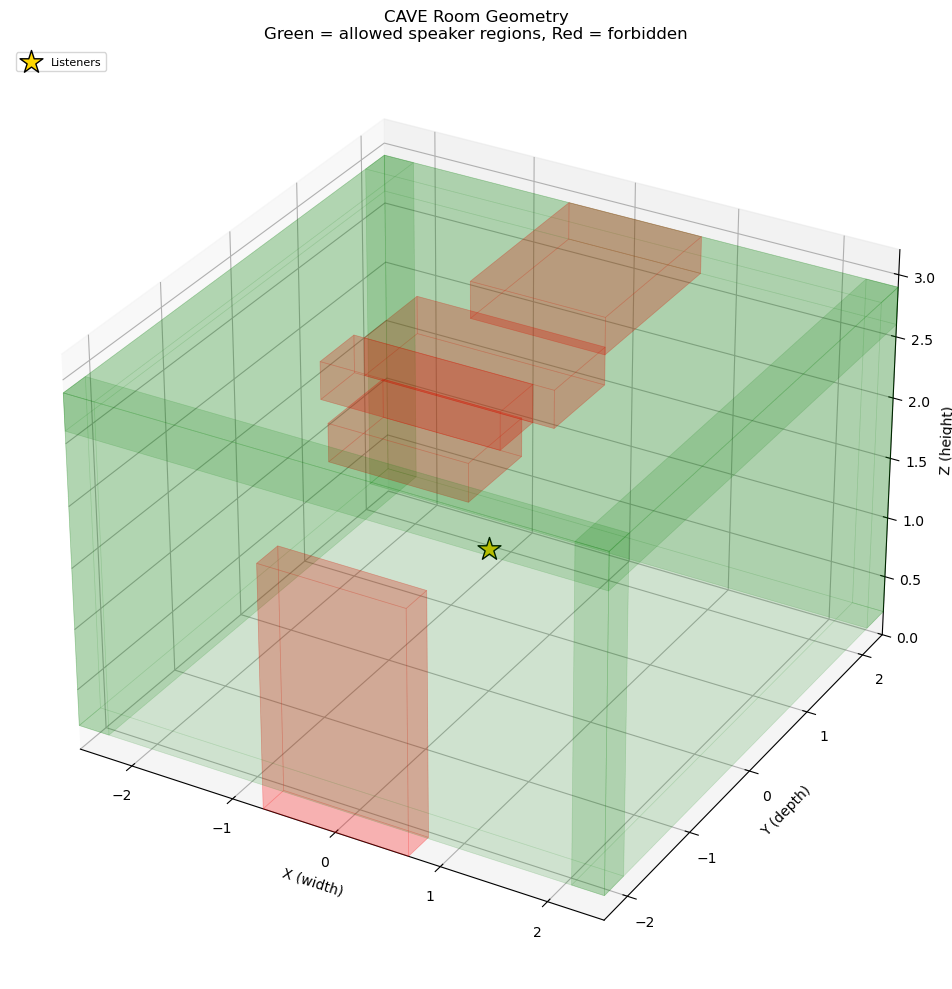

In [5]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
draw_room(ax, listeners=listener_positions,
          title='CAVE Room Geometry\nGreen = allowed speaker regions, Red = forbidden')
plt.tight_layout()
fig.savefig('figures/room_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

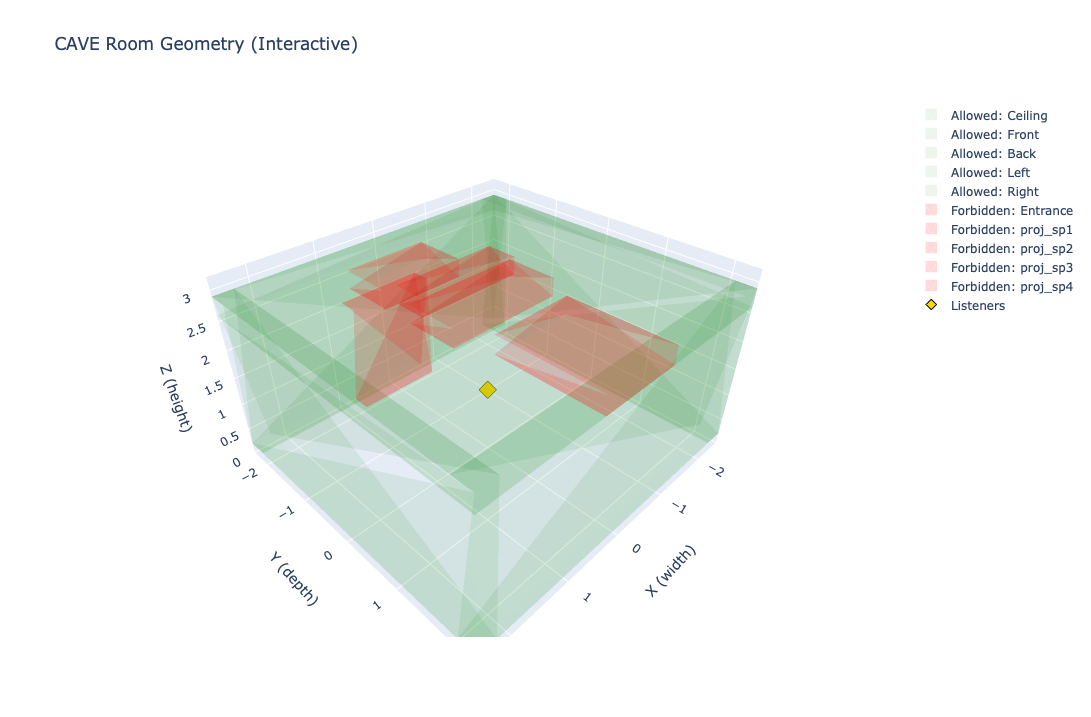

In [6]:
# =====================================================================
# Room Geometry -- Interactive 3D (Plotly)
# =====================================================================

fig_room_3d = go.Figure(
    data=plotly_room_traces(listeners=listener_positions),
    layout=plotly_3d_layout(
        title='CAVE Room Geometry (Interactive)',
        xrange=[-W-0.5, W+0.5], yrange=[-D-0.5, D+0.5], zrange=[0, H+0.8]))
fig_room_3d.show()

---
## 3. Random Initial Layout & VBAP Triangulation
Generate a random feasible speaker placement and compute its VBAP triangulation (convex hull of speaker directions).

Initial layout: 24 speakers, 44 triangles


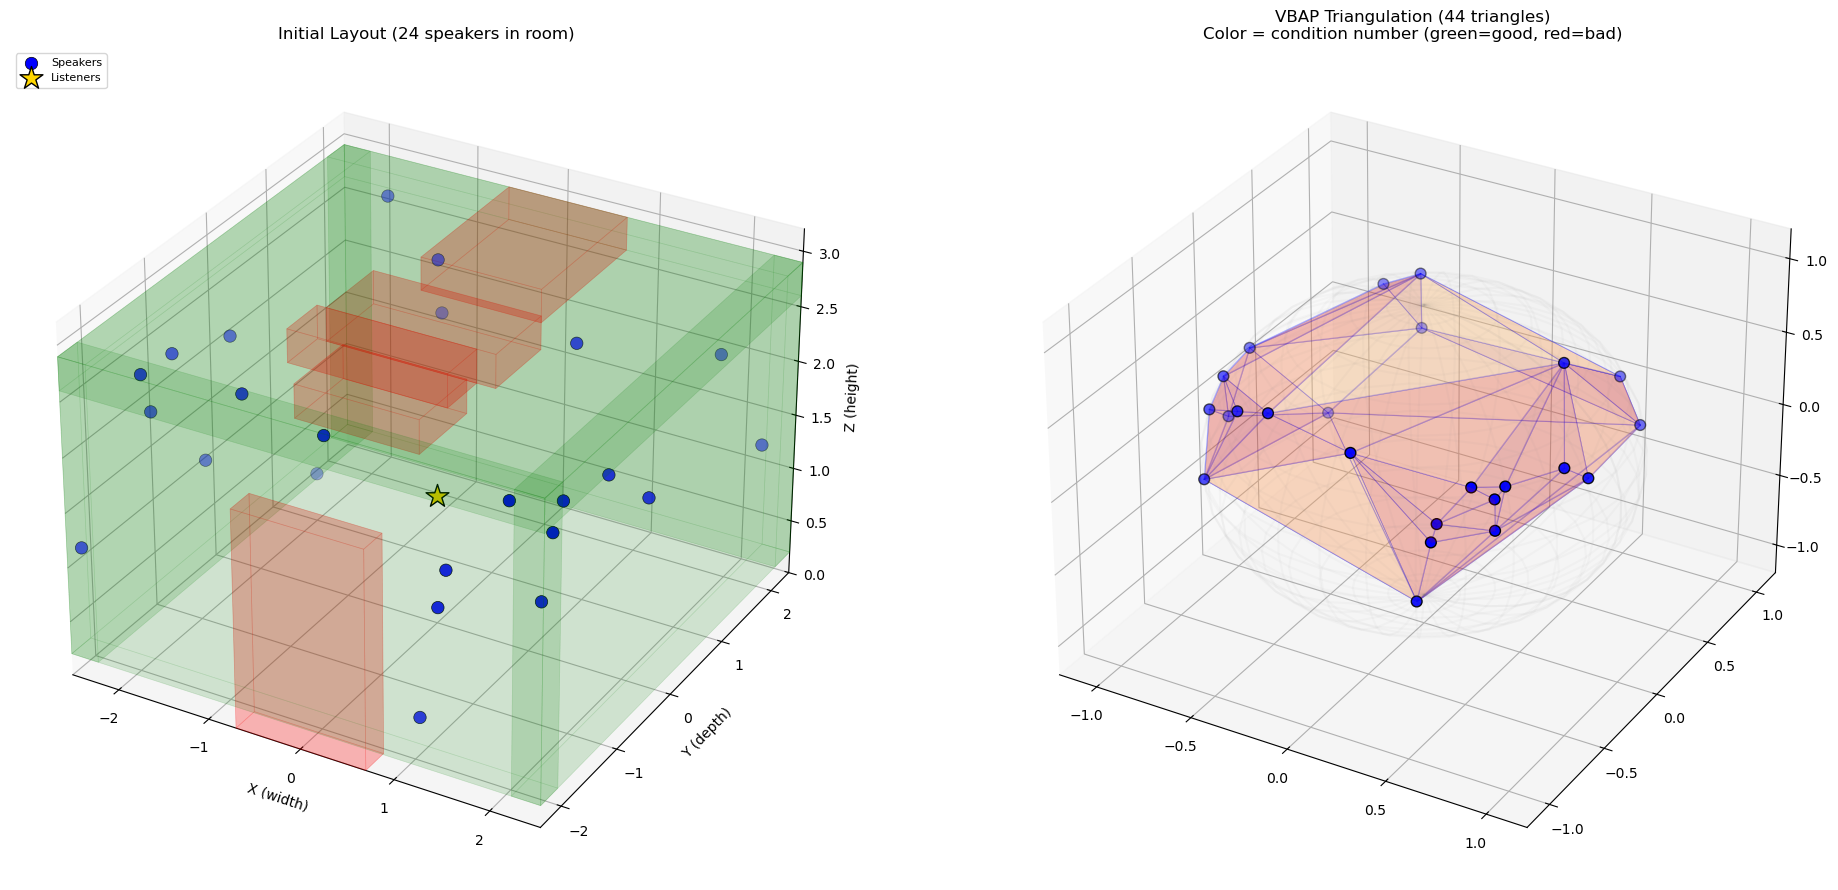

In [7]:
initial_spk = initial_layout(allowed_boxes, N_SPEAKERS, config.MIN_SPEAKER_DISTANCE,
                              rng, forbidden_boxes)
renderer_init = VBAPRenderer(initial_spk, listener_center)

print(f'Initial layout: {N_SPEAKERS} speakers, {len(renderer_init.triangles)} triangles')

fig, axes = plt.subplots(1, 2, figsize=(20, 9), subplot_kw={'projection': '3d'})

# Room view
draw_room(axes[0], speakers=initial_spk, listeners=listener_positions,
          title=f'Initial Layout ({N_SPEAKERS} speakers in room)')

# Sphere triangulation view
ax = axes[1]
ax.plot_wireframe(SPHERE_X, SPHERE_Y, SPHERE_Z, alpha=0.04, color='gray')
dirs = renderer_init.speaker_dirs
ax.scatter(dirs[:, 0], dirs[:, 1], dirs[:, 2], c='blue', s=60, edgecolors='black', zorder=5)

# Triangulation edges and faces
edges = set()
for tri in renderer_init.triangles:
    for i in range(3):
        edges.add(tuple(sorted((tri[i], tri[(i+1)%3]))))
for i, j in edges:
    ax.plot(*np.array([dirs[i], dirs[j]]).T, 'b-', alpha=0.3, linewidth=0.8)

conds = renderer_init.condition_numbers
cond_norm = conds / (1 + conds)
cmap = plt.colormaps['RdYlGn_r']
for t_idx, tri in enumerate(renderer_init.triangles):
    verts = [dirs[tri[0]], dirs[tri[1]], dirs[tri[2]]]
    poly = Poly3DCollection([verts], alpha=0.2)
    poly.set_facecolor(cmap(cond_norm[t_idx]))
    poly.set_edgecolor('blue'); poly.set_linewidth(0.3)
    ax.add_collection3d(poly)

ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_zlim(-1.2, 1.2)
ax.set_title(f'VBAP Triangulation ({len(renderer_init.triangles)} triangles)\n'
             f'Color = condition number (green=good, red=bad)')
plt.tight_layout()
plt.show()

# Cache initial layout quality metrics (reused in Cell 31)
init_quality_metrics = evaluate_vbap_quality(initial_spk, listener_center, test_directions)

---
## 4. Initial Coverage Heatmap
Show per-direction VBAP coverage quality before optimization -- identifies which spatial regions have poor panning.

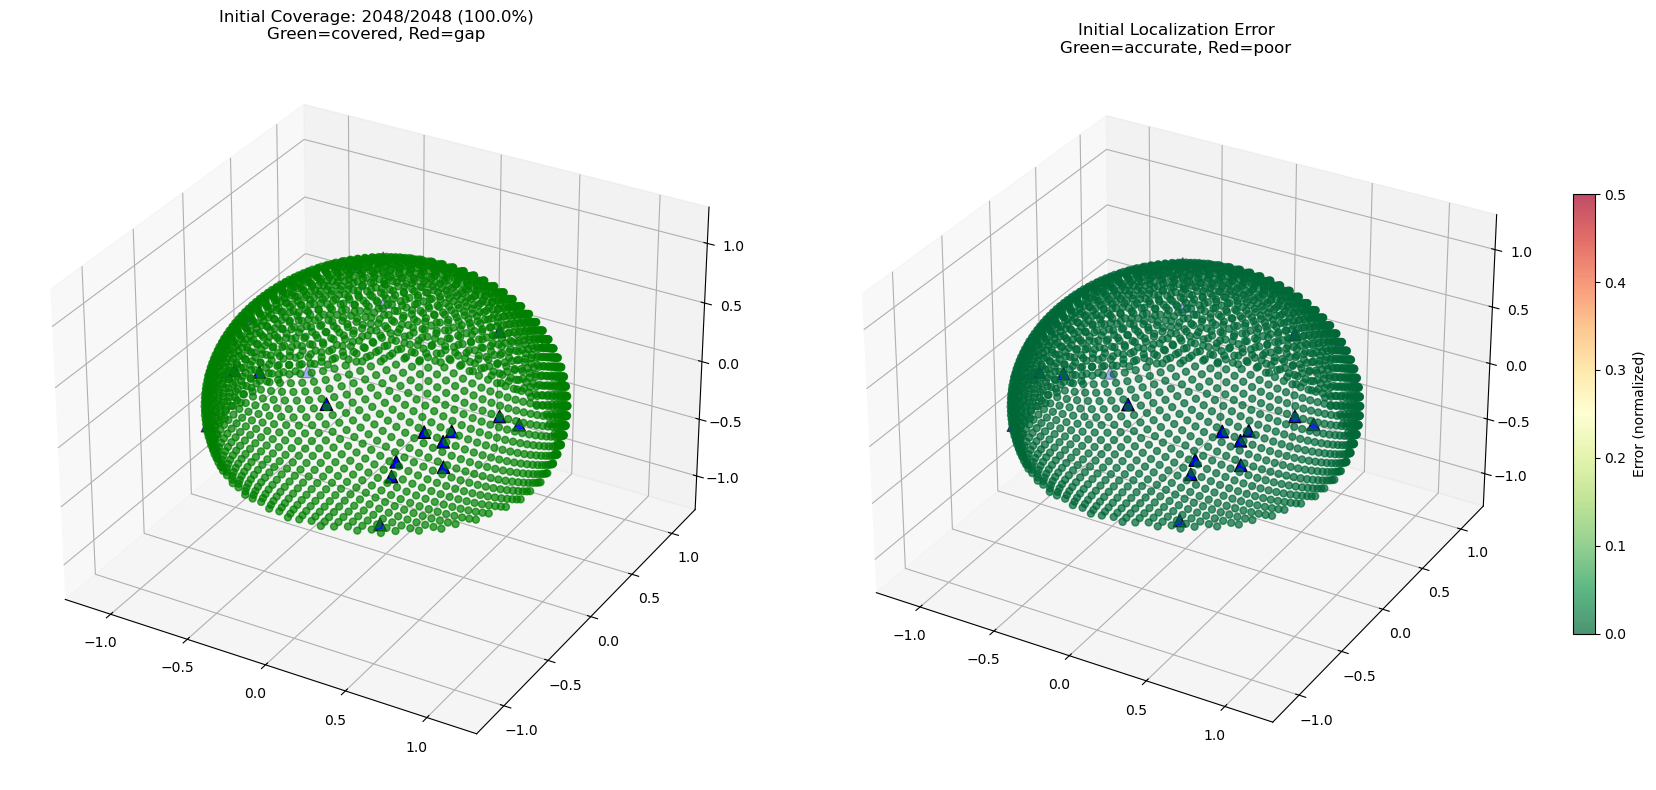

Initial VBAP metrics:
  coverage: 1.0000
  upper_coverage: 1.0000
  mean_loc_error: 0.0000
  mean_energy_err: 0.0405
  mean_rV_mag_error: 0.0412
  mean_rE_mag_error: 0.0227
  energy_var: 0.0046
  mean_cond: 0.8373
  angular_uniformity: 0.0447
  max_gap: 0.7468
  upper_max_gap: 0.5880


In [8]:
def compute_coverage_data(renderer, test_dirs):
    """Compute per-direction coverage and localization error (thin wrapper)."""
    m = compute_all_direction_metrics(renderer, test_dirs)
    covered_flags = m['covered'].tolist()
    loc_errors = np.where(m['covered'],
                          np.nan_to_num(np.radians(m['rv_error_deg']), nan=np.pi) / np.pi,
                          1.0).tolist()
    return covered_flags, loc_errors

def plot_coverage_sphere(ax, test_dirs, covered_flags, loc_errors, spk_dirs, title_prefix=''):
    """Plot coverage and localization on unit sphere."""
    colors = ['green' if c else 'red' for c in covered_flags]
    n_cov = sum(covered_flags)
    ax.scatter(test_dirs[:, 0], test_dirs[:, 1], test_dirs[:, 2],
               c=colors, s=25, alpha=0.7)
    ax.scatter(spk_dirs[:, 0], spk_dirs[:, 1], spk_dirs[:, 2],
               c='blue', s=80, marker='^', edgecolors='black', zorder=10)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_zlim(-1.3, 1.3)
    ax.set_title(f'{title_prefix}Coverage: {n_cov}/{len(test_dirs)} '
                 f'({100*n_cov/len(test_dirs):.1f}%)\nGreen=covered, Red=gap')

init_covered, init_loc_err = compute_coverage_data(renderer_init, test_directions)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': '3d'})
plot_coverage_sphere(axes[0], test_directions, init_covered, init_loc_err,
                     renderer_init.speaker_dirs, 'Initial ')

ax = axes[1]
sc = ax.scatter(test_directions[:, 0], test_directions[:, 1], test_directions[:, 2],
                c=init_loc_err, cmap='RdYlGn_r', s=25, alpha=0.7, vmin=0, vmax=0.5)
ax.scatter(renderer_init.speaker_dirs[:, 0], renderer_init.speaker_dirs[:, 1],
           renderer_init.speaker_dirs[:, 2], c='blue', s=80, marker='^',
           edgecolors='black', zorder=10)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_zlim(-1.3, 1.3)
ax.set_title('Initial Localization Error\nGreen=accurate, Red=poor')
fig.colorbar(sc, ax=ax, shrink=0.6, label='Error (normalized)')

plt.tight_layout()
plt.show()

init_metrics = evaluate_vbap_quality(initial_spk, listener_center, test_directions)
print('Initial VBAP metrics:')
for k, v in init_metrics.items():
    print(f'  {k}: {v:.4f}')

---
## 5. Optimization

**Choose your mode:**
- **Run mode** (cell 5a): Run optimization directly (uses `OPTIMIZER` setting from Section 1)
- **Load mode** (cell 5b): Load results from a previous CLI run

Run **one** of the two cells below.

In [9]:
# =====================================================================
# 5a. RUN MODE -- Run optimization directly
# =====================================================================

convergence_log = []

print(f'Optimizer: {OPTIMIZER}')
print(f'Adaptive weighting: {COST_WEIGHTS.get("adaptive", False)}')
print(f'Speakers: {N_SPEAKERS} ({N_SPEAKERS*3}D search space)')
print(f'Listeners: {len(listener_positions)} positions')
print()

# --- Build seed layouts: known-good starting points for the optimizer ---
# These compete on equal footing with random initializations.
# (Helper functions defined in Cell 5: angles_to_room_position,
#  make_reference_layout, make_equidistant_layout, REF24_AZ/EL)

seed_layouts = []

# Seed 1: Atmos 9.1.6 extended (only for 24 speakers)
if N_SPEAKERS == 24:
    ref_layout = make_reference_layout(REF24_AZ, REF24_EL, listener_center,
                                        allowed_boxes, forbidden_boxes)
    seed_layouts.append(ref_layout)
    print(f'Seed 1: Atmos 9.1.6 reference layout')

# Seed 2: Equidistant (Fibonacci sphere) -- works for any N
equidist_layout = make_equidistant_layout(N_SPEAKERS, listener_center,
                                           allowed_boxes, forbidden_boxes)
seed_layouts.append(equidist_layout)
print(f'Seed 2: Equidistant (Fibonacci sphere) layout')

import time
t0 = time.time()

if OPTIMIZER == 'multistart':
    print(f'Multistart L-BFGS-B: {NUM_RANDOM_STARTS} random starts, '
          f'refining top {NUM_REFINE}')
    best_layout, best_cost, opt_result = optimize_layout_multistart(
        feasible_boxes=allowed_boxes,
        forbidden_boxes=forbidden_boxes,
        n_speakers=N_SPEAKERS,
        listener_positions=listener_positions,
        test_directions=test_directions,
        cost_weights=COST_WEIGHTS,
        min_speaker_distance=config.MIN_SPEAKER_DISTANCE,
        num_starts=NUM_RANDOM_STARTS,
        num_refine=NUM_REFINE,
        seed=SEED,
        convergence_log=convergence_log,
        seed_layouts=seed_layouts or None,
    )
elif OPTIMIZER == 'cmaes':
    print(f'CMA-ES: sigma0={CMAES_PARAMS["sigma0"]}, '
          f'maxiter={CMAES_PARAMS["maxiter"]}')
    best_layout, best_cost, opt_result = optimize_layout_cmaes(
        feasible_boxes=allowed_boxes,
        forbidden_boxes=forbidden_boxes,
        n_speakers=N_SPEAKERS,
        listener_positions=listener_positions,
        test_directions=test_directions,
        cost_weights=COST_WEIGHTS,
        min_speaker_distance=config.MIN_SPEAKER_DISTANCE,
        cmaes_params=CMAES_PARAMS,
        num_starts=NUM_RANDOM_STARTS,
        seed=SEED,
        convergence_log=convergence_log,
        seed_layouts=seed_layouts or None,
    )
else:
    print(f'DE: popsize={DE_PARAMS["popsize"]}, maxiter={DE_PARAMS["maxiter"]}, '
          f'{NUM_RESTARTS} restarts')
    best_layout, best_cost, opt_result = optimize_layout_de(
        feasible_boxes=allowed_boxes,
        forbidden_boxes=forbidden_boxes,
        n_speakers=N_SPEAKERS,
        listener_positions=listener_positions,
        test_directions=test_directions,
        cost_weights=COST_WEIGHTS,
        de_params=DE_PARAMS,
        min_speaker_distance=config.MIN_SPEAKER_DISTANCE,
        seed=SEED,
        convergence_log=convergence_log,
        num_restarts=NUM_RESTARTS,
        seed_layouts=seed_layouts or None,
    )

elapsed = time.time() - t0
print(f'\nDone! ({elapsed:.1f}s)')
print(f'Best cost: {best_cost:.6f}')

if hasattr(opt_result, 'nfev'):
    print(f'Function evaluations: {opt_result.nfev}')
elif hasattr(opt_result, 'evaluations'):
    print(f'Function evaluations: {opt_result.evaluations}')

if hasattr(opt_result, 'success'):
    if opt_result.success:
        print(f'Optimizer converged: {opt_result.message}')
    elif OPTIMIZER == 'multistart':
        print(f'L-BFGS-B finished (hit iteration limit -- normal for multistart)')
    else:
        print(f'Optimizer status: {opt_result.message}')
elif OPTIMIZER == 'cmaes':
    print(f'CMA-ES completed ({opt_result.iterations} iterations)')

MODE = 'run'

Optimizer: multistart
Adaptive weighting: True
Speakers: 24 (72D search space)
Listeners: 1 positions

Seed 1: Atmos 9.1.6 reference layout
Seed 2: Equidistant (Fibonacci sphere) layout
Multistart L-BFGS-B: 500 random starts, refining top 10
  Adaptive weights (base -> adapted):
    coverage: 0.00 -> 0.00
    upper_coverage: 0.00 -> 0.00
    loc_error: 1.00 -> 0.30
    energy_error: 1.00 -> 0.30
    energy_var: 1.00 -> 1.00
    rV_mag: 1.00 -> 0.30
    rE_mag: 1.00 -> 0.30
    conditioning: 0.00 -> 0.00
    uniformity: 0.00 -> 0.00
    max_gap: 0.00 -> 0.00
    distance_penalty: 0.00 -> 0.00
    spread_penalty: 0.00 -> 0.00
    symmetry_weight: 0.00 -> 0.00
    coverage_floor: 0.00 -> 0.00
    coverage_floor_weight: 0.00 -> 0.00
    worst_weight: 0.30 -> 0.30
    adaptive: 1.00 -> 0.00
  Phase 1: Evaluating 500 random layouts...
  Seed layout 1: cost=2.424486
  Seed layout 2: cost=0.040991
  Best candidate: 0.021305, Worst: 2.424486
  Phase 2: Refining top 10 layouts with L-BFGS-B...
 

In [10]:
# =====================================================================
# 5b. LOAD MODE -- Load results from a previous CLI run
# =====================================================================

# Skip if we already ran optimization in cell 5a
if 'MODE' in dir() and MODE == 'run':
    print('Already ran optimization in cell 5a -- skipping load.')
else:
    results_dir = config.OUTPUT_DIR
    result_files = sorted(glob.glob(os.path.join(results_dir, 'optimization_results_*.json')))

    if not result_files:
        print(f'No saved results in {results_dir}/.')
        print('Run optimization in cell 5a first, or run `python -m run` from the CLI.')
    else:
        latest = result_files[-1]
        print(f'Loading: {latest}')

        with open(latest) as f:
            all_saved_results = json.load(f)

        print(f'Found {len(all_saved_results)} optimization result(s):')
        for r in all_saved_results:
            print(f'  N={r["n_speakers"]}: cost={r["best_cost"]:.6f}, '
                  f'feval={r["de_nfev"]}, success={r["de_success"]}')

        # Pick the result matching N_SPEAKERS, or the last one
        loaded = None
        for r in all_saved_results:
            if r['n_speakers'] == N_SPEAKERS:
                loaded = r
                break
        if loaded is None:
            loaded = all_saved_results[-1]
            print(f'\nNo result for N={N_SPEAKERS}, using N={loaded["n_speakers"]} instead')

        best_layout = np.array(loaded['best_layout'])
        best_cost = loaded['best_cost']
        convergence_log = []  # not available from saved results

        print(f'\nLoaded layout: {best_layout.shape[0]} speakers, cost={best_cost:.6f}')
        MODE = 'load'

Already ran optimization in cell 5a -- skipping load.


---
## 6. Optimization Convergence
*(Only available in Run mode)*

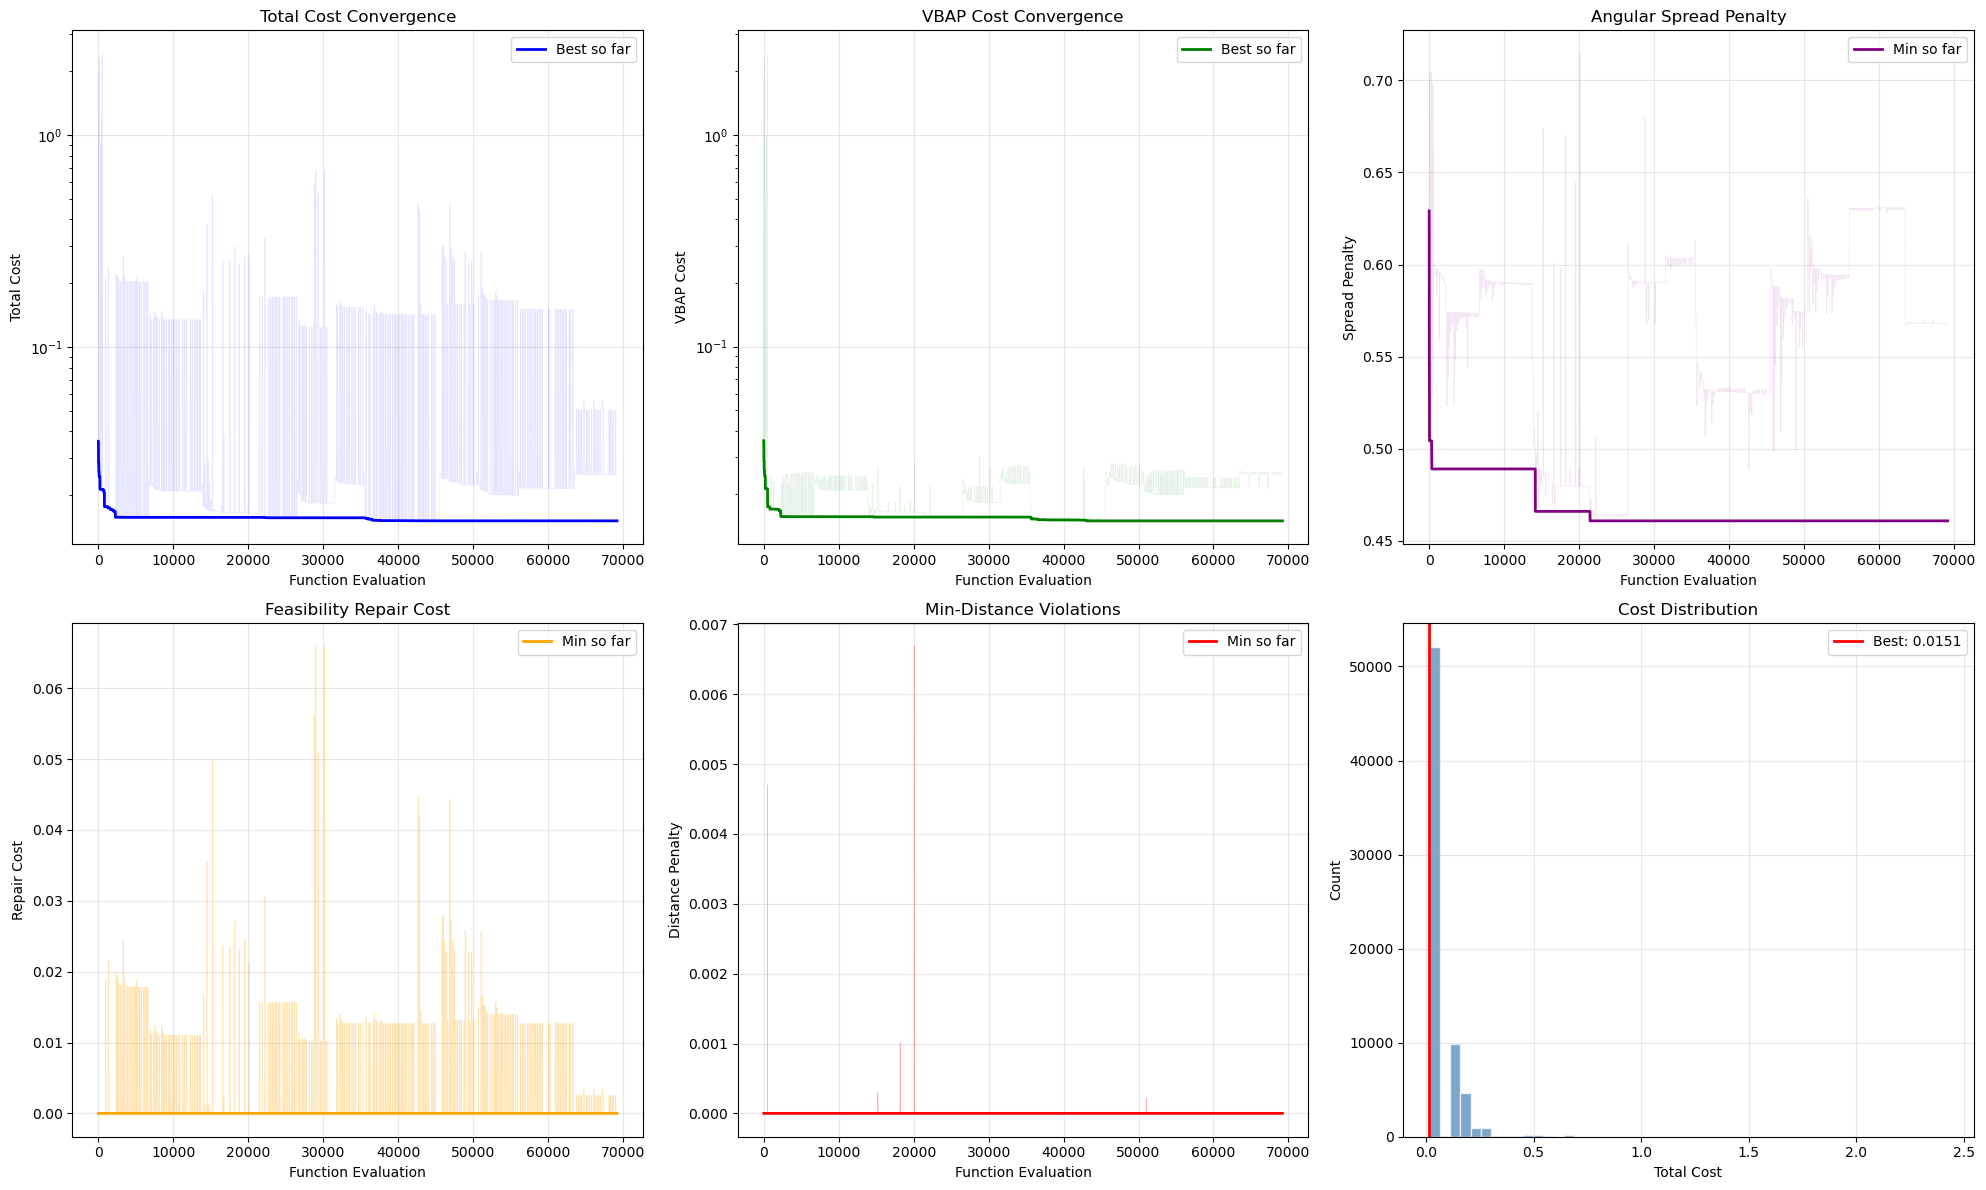

Total evaluations: 69195
Final best total cost: 0.015120
Final best VBAP cost: 0.015007


In [11]:
if not convergence_log:
    print('No convergence data (loaded from file or optimization did not log).')
    print('Run optimization in cell 5a to see convergence plots.')
else:
    totals = [e['total'] for e in convergence_log]
    vbap_costs = [e['vbap_cost'] for e in convergence_log]
    repair_costs = [e['repair_cost'] for e in convergence_log]
    dist_violations = [e['dist_violation'] for e in convergence_log]
    spread_pens = [e.get('spread_penalty', 0) for e in convergence_log]

    best_so_far = np.minimum.accumulate(totals)
    best_vbap = np.minimum.accumulate(vbap_costs)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # Total cost
    ax = axes[0, 0]
    ax.semilogy(totals, alpha=0.1, color='blue', linewidth=0.5)
    ax.semilogy(best_so_far, color='blue', linewidth=2, label='Best so far')
    ax.set_xlabel('Function Evaluation'); ax.set_ylabel('Total Cost')
    ax.set_title('Total Cost Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

    # VBAP cost
    ax = axes[0, 1]
    ax.semilogy(vbap_costs, alpha=0.1, color='green', linewidth=0.5)
    ax.semilogy(best_vbap, color='green', linewidth=2, label='Best so far')
    ax.set_xlabel('Function Evaluation'); ax.set_ylabel('VBAP Cost')
    ax.set_title('VBAP Cost Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

    # Spread penalty
    ax = axes[0, 2]
    ax.plot(spread_pens, alpha=0.1, color='purple', linewidth=0.5)
    ax.plot(np.minimum.accumulate(spread_pens), color='purple', linewidth=2, label='Min so far')
    ax.set_xlabel('Function Evaluation'); ax.set_ylabel('Spread Penalty')
    ax.set_title('Angular Spread Penalty'); ax.legend(); ax.grid(True, alpha=0.3)

    # Repair cost (feasibility)
    ax = axes[1, 0]
    ax.plot(repair_costs, alpha=0.3, color='orange', linewidth=0.5)
    ax.plot(np.minimum.accumulate(repair_costs), color='orange', linewidth=2, label='Min so far')
    ax.set_xlabel('Function Evaluation'); ax.set_ylabel('Repair Cost')
    ax.set_title('Feasibility Repair Cost'); ax.legend(); ax.grid(True, alpha=0.3)

    # Distance violations
    ax = axes[1, 1]
    ax.plot(dist_violations, alpha=0.3, color='red', linewidth=0.5)
    ax.plot(np.minimum.accumulate(dist_violations), color='red', linewidth=2, label='Min so far')
    ax.set_xlabel('Function Evaluation'); ax.set_ylabel('Distance Penalty')
    ax.set_title('Min-Distance Violations'); ax.legend(); ax.grid(True, alpha=0.3)

    # Cost histogram
    ax = axes[1, 2]
    ax.hist(totals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(best_so_far[-1], color='red', linewidth=2, label=f'Best: {best_so_far[-1]:.4f}')
    ax.set_xlabel('Total Cost'); ax.set_ylabel('Count')
    ax.set_title('Cost Distribution'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig('figures/convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Total evaluations: {len(totals)}')
    print(f'Final best total cost: {best_so_far[-1]:.6f}')
    print(f'Final best VBAP cost: {best_vbap[-1]:.6f}')

---
## 7. Before vs After: Speaker Layout
Side-by-side comparison of the random initial placement and the optimized placement in the room.

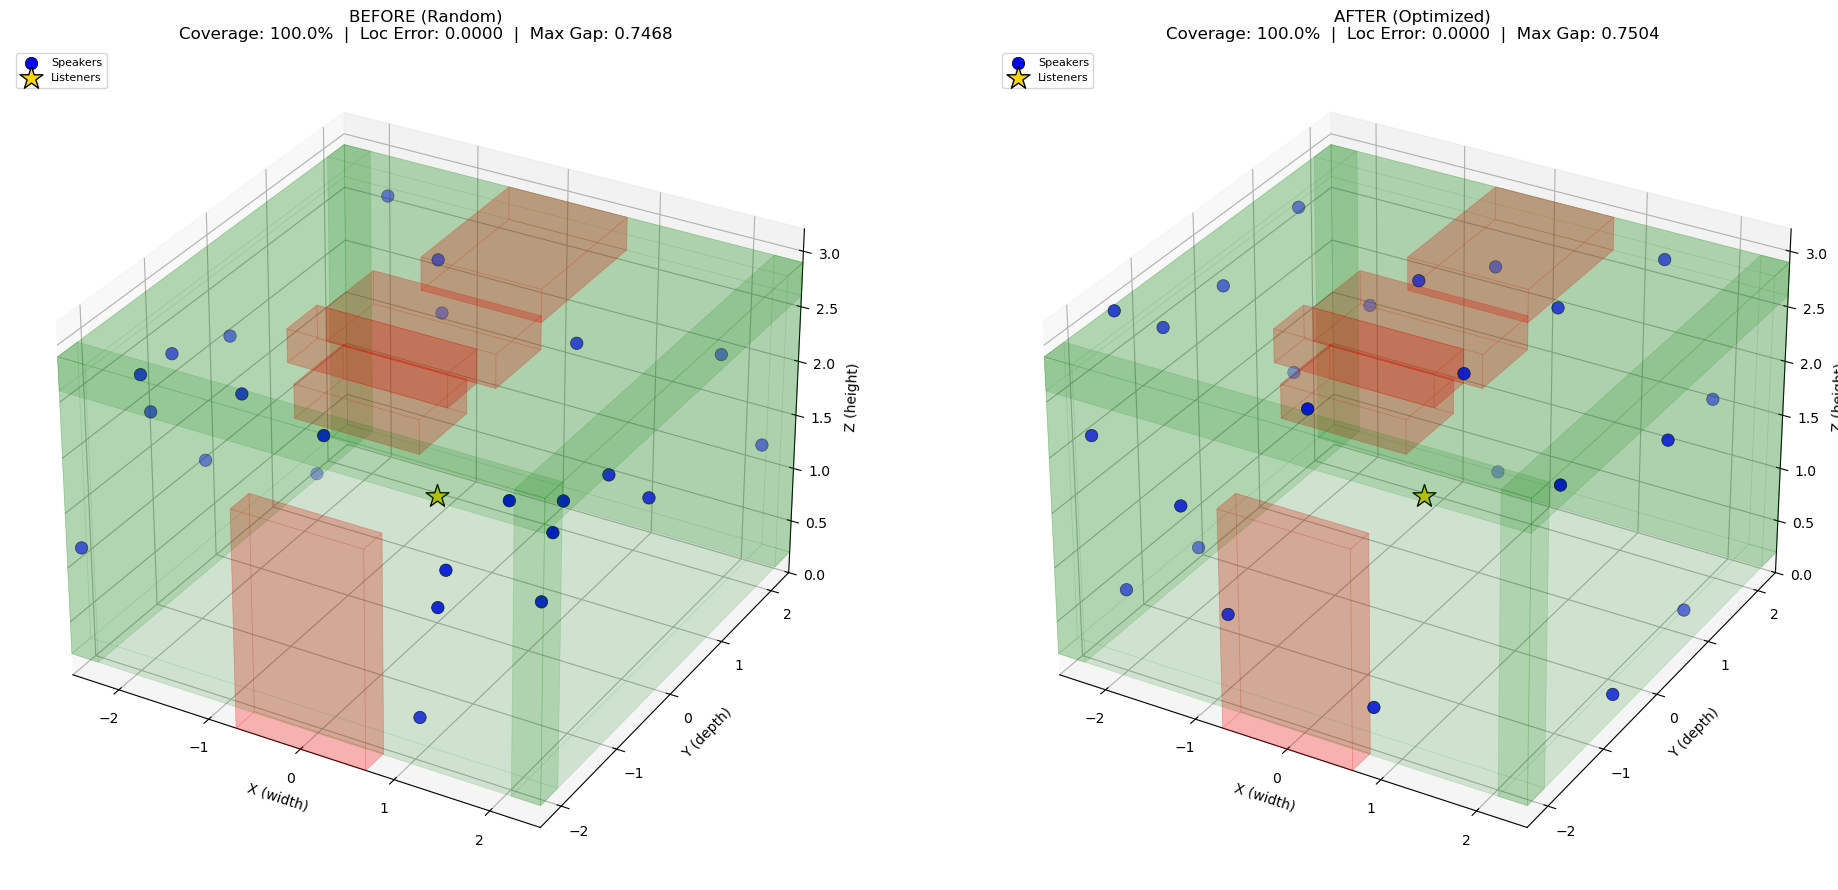

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), subplot_kw={'projection': '3d'})

for ax, layout, title in [
    (axes[0], initial_spk, 'BEFORE (Random)'),
    (axes[1], best_layout, 'AFTER (Optimized)'),
]:
    m = evaluate_vbap_quality(layout, listener_center, test_directions)
    draw_room(ax, speakers=layout, listeners=listener_positions,
              title=f'{title}\nCoverage: {m["coverage"]:.1%}  |  '
                    f'Loc Error: {m["mean_loc_error"]:.4f}  |  '
                    f'Max Gap: {m["max_gap"]:.4f}')

plt.tight_layout()
fig.savefig('figures/before_after_layout.png', dpi=150, bbox_inches='tight')
plt.show()

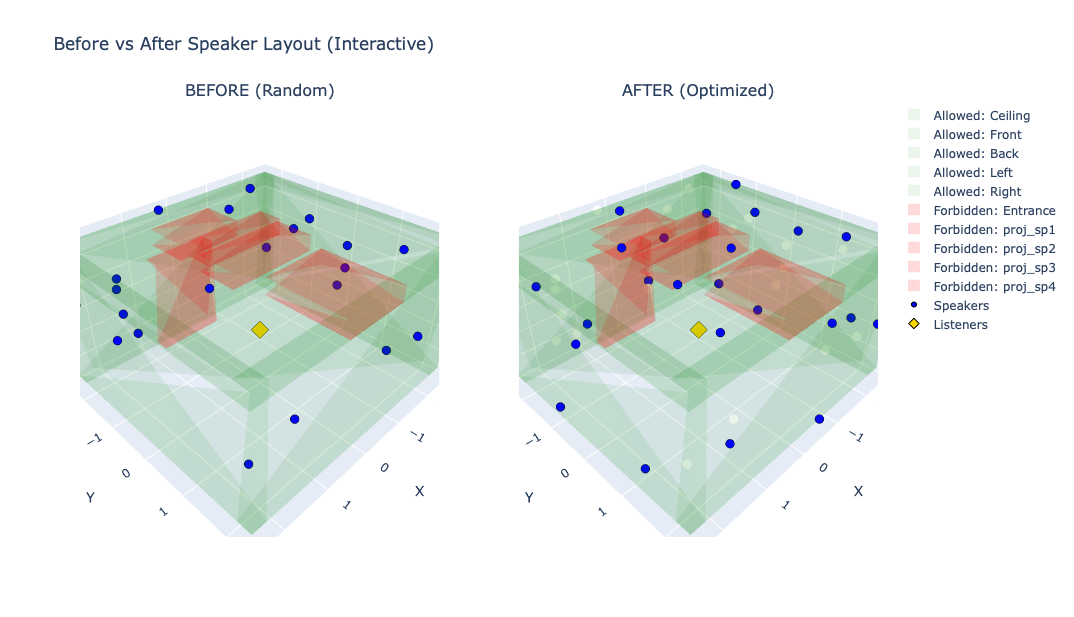

In [14]:
# =====================================================================
# Before vs After -- Interactive 3D (Plotly)
# =====================================================================

fig_ba = make_subplots(rows=1, cols=2,
                        specs=[[{'type': 'scene'}, {'type': 'scene'}]],
                        subplot_titles=['BEFORE (Random)', 'AFTER (Optimized)'])

for col, (layout, label) in enumerate([(initial_spk, 'Before'), (best_layout, 'After')], 1):
    m = evaluate_vbap_quality(layout, listener_center, test_directions)
    traces = plotly_room_traces(speakers=layout, listeners=listener_positions)
    for tr in traces:
        tr.showlegend = (col == 1)
        fig_ba.add_trace(tr, row=1, col=col)

scene_kw = dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data')
fig_ba.update_layout(width=1400, height=600,
                      title='Before vs After Speaker Layout (Interactive)',
                      scene=scene_kw, scene2=scene_kw)
fig_ba.show()

---
## 8. Optimized Triangulation & Coverage
Visualize the optimized VBAP triangulation on the unit sphere and the resulting per-direction coverage quality.

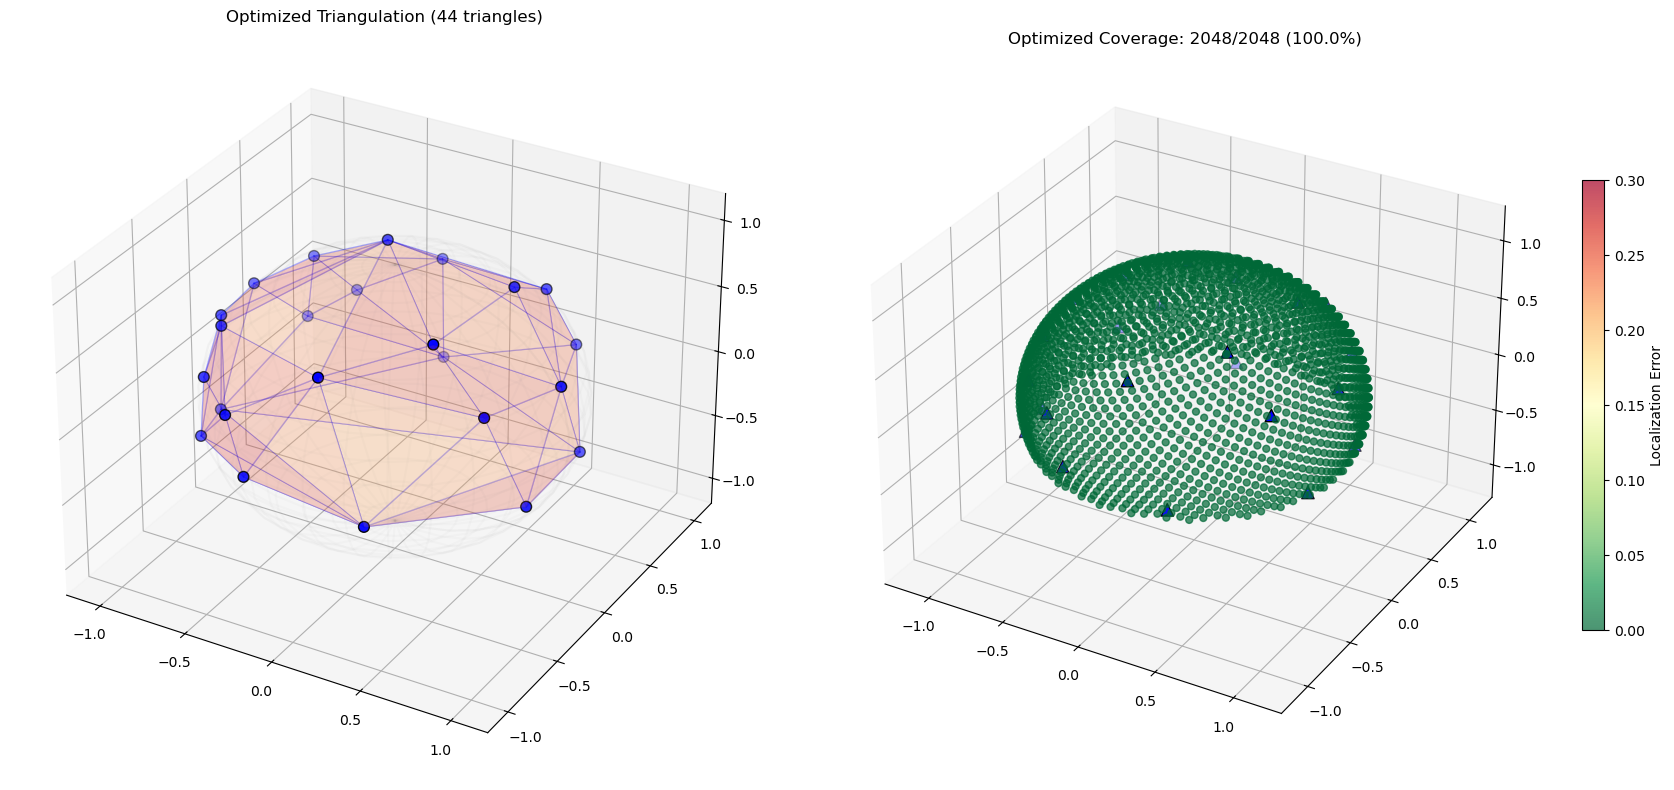

In [15]:
renderer_opt = VBAPRenderer(best_layout, listener_center)
opt_dirs = renderer_opt.speaker_dirs
opt_covered, opt_loc_err = compute_coverage_data(renderer_opt, test_directions)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': '3d'})

# Triangulation
ax = axes[0]
ax.plot_wireframe(SPHERE_X*0.98, SPHERE_Y*0.98, SPHERE_Z*0.98, alpha=0.03, color='gray')
ax.scatter(opt_dirs[:, 0], opt_dirs[:, 1], opt_dirs[:, 2],
           c='blue', s=60, edgecolors='black', zorder=5)

opt_edges = set()
for tri in renderer_opt.triangles:
    for i in range(3):
        opt_edges.add(tuple(sorted((tri[i], tri[(i+1)%3]))))
for i, j in opt_edges:
    ax.plot(*np.array([opt_dirs[i], opt_dirs[j]]).T, 'b-', alpha=0.3, linewidth=0.8)

conds = renderer_opt.condition_numbers
cond_n = conds / (1 + conds)
for t_idx, tri in enumerate(renderer_opt.triangles):
    verts = [opt_dirs[tri[0]], opt_dirs[tri[1]], opt_dirs[tri[2]]]
    poly = Poly3DCollection([verts], alpha=0.15)
    poly.set_facecolor(plt.colormaps['RdYlGn_r'](cond_n[t_idx]))
    poly.set_edgecolor('blue'); poly.set_linewidth(0.3)
    ax.add_collection3d(poly)

ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_zlim(-1.2, 1.2)
ax.set_title(f'Optimized Triangulation ({len(renderer_opt.triangles)} triangles)')

# Coverage
ax = axes[1]
sc = ax.scatter(test_directions[:, 0], test_directions[:, 1], test_directions[:, 2],
                c=opt_loc_err, cmap='RdYlGn_r', s=25, alpha=0.7, vmin=0, vmax=0.3)
ax.scatter(opt_dirs[:, 0], opt_dirs[:, 1], opt_dirs[:, 2],
           c='blue', s=80, marker='^', edgecolors='black', zorder=10)
n_cov = sum(opt_covered)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_zlim(-1.3, 1.3)
ax.set_title(f'Optimized Coverage: {n_cov}/{len(test_directions)} '
             f'({100*n_cov/len(test_directions):.1f}%)')
fig.colorbar(sc, ax=ax, shrink=0.6, label='Localization Error')

plt.tight_layout()
fig.savefig('figures/optimized_triangulation.png', dpi=150, bbox_inches='tight')
plt.show()

# Cache optimized layout quality metrics (reused in Cells 31, 37)
opt_quality_metrics = evaluate_vbap_quality(best_layout, listener_center, test_directions)

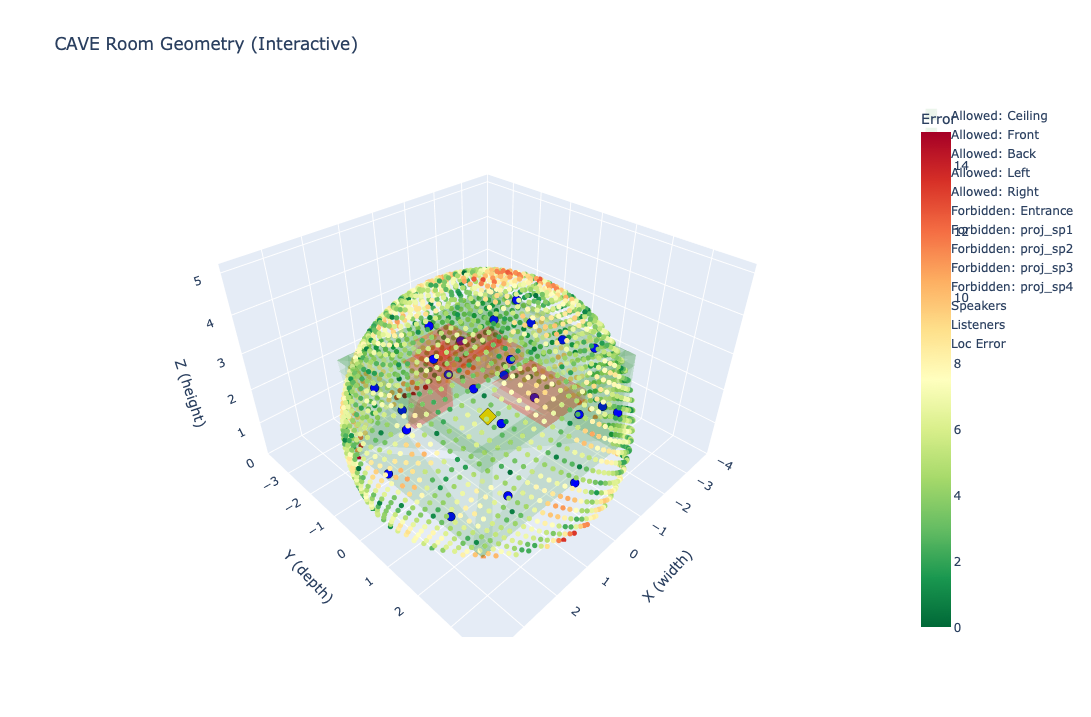

In [17]:
m = compute_all_direction_metrics(renderer_opt, test_directions)
test_points = test_directions * 3.5 + listener_positions[0]

xrange = [np.min(test_points[:,0]) - 0.5, np.max(test_points[:,0]) + 0.5]
yrange = [np.min(test_points[:,1]) - 0.5, np.max(test_points[:,1]) + 0.5]
zrange = [0, np.max(test_points[:,2]) + 0.5]

fig_room_3d = go.Figure(
    data=plotly_room_traces(speakers=best_layout, listeners=listener_positions),
    layout=plotly_3d_layout(
        title='CAVE Room Geometry (Interactive)',
        xrange=xrange, yrange=yrange, zrange=zrange))
spheres = plotly_sphere_traces(
    test_points, m["re_error_deg"], colorscale='RdYlGn_r',
    size=3, name='Loc Error', cmin=0, cmax=15, colorbar_title='Error')
fig_room_3d.add_traces(spheres)
#for sph in spheres:
        # sph.showlegend = (col == 1)
 #       fig_room_3d.add_trace(tr)
fig_room_3d.show()

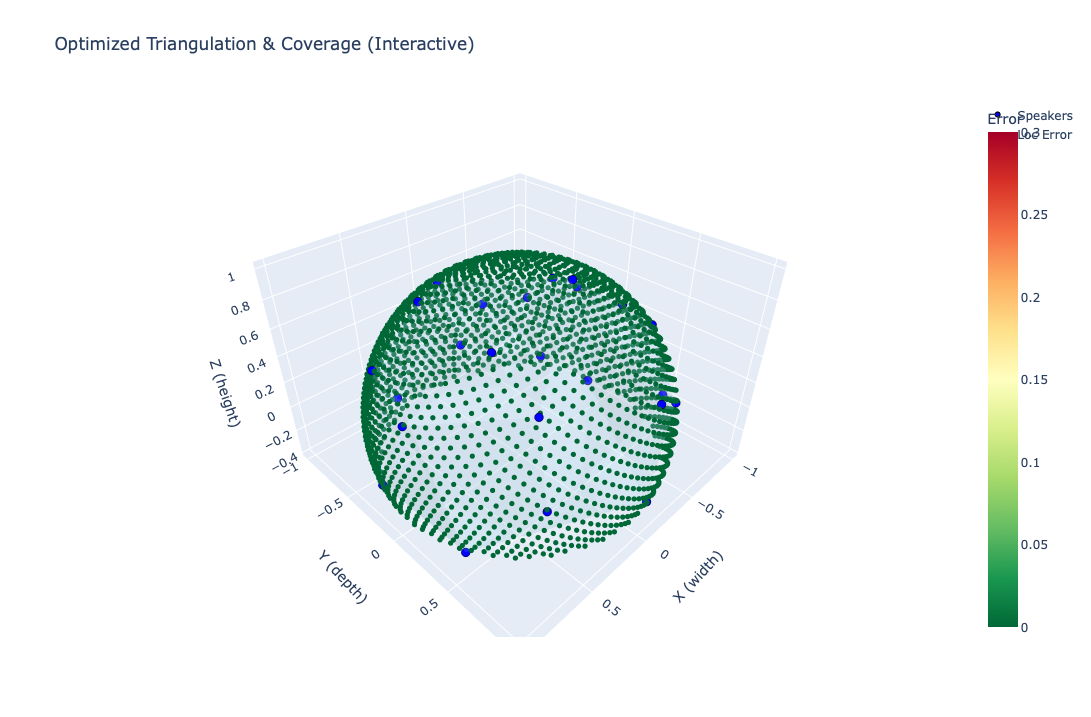

In [18]:
# =====================================================================
# Optimized Triangulation & Coverage -- Interactive 3D (Plotly)
# =====================================================================

traces_tri = []

# Triangulation mesh
tri_arr = np.array(renderer_opt.triangles)
traces_tri.append(go.Mesh3d(
    x=opt_dirs[:, 0], y=opt_dirs[:, 1], z=opt_dirs[:, 2],
    i=tri_arr[:, 0], j=tri_arr[:, 1], k=tri_arr[:, 2],
    opacity=0.15, color='lightblue', name='Triangulation'))

# Speaker directions
traces_tri.append(go.Scatter3d(
    x=opt_dirs[:, 0], y=opt_dirs[:, 1], z=opt_dirs[:, 2],
    mode='markers',
    marker=dict(size=5, color='blue', line=dict(width=1, color='black')),
    name='Speakers'))

# Coverage heatmap on sphere
td_norm = test_directions / (np.linalg.norm(test_directions, axis=1, keepdims=True) + 1e-12)
traces_tri.append(plotly_sphere_traces(
    td_norm, opt_loc_err, colorscale='RdYlGn_r',
    size=3, name='Loc Error', cmin=0, cmax=0.3, colorbar_title='Error'))

fig_tri = go.Figure(data=traces_tri,
                     layout=plotly_3d_layout(title='Optimized Triangulation & Coverage (Interactive)'))
fig_tri.show()

---
## 9. Sound Field Rendering
For a virtual source direction, visualize which speakers activate and how loud each one is.
- **Red arrow**: desired source direction
- **Cyan arrow**: perceived direction (rV vector)
- **Speaker size/color**: VBAP gain magnitude

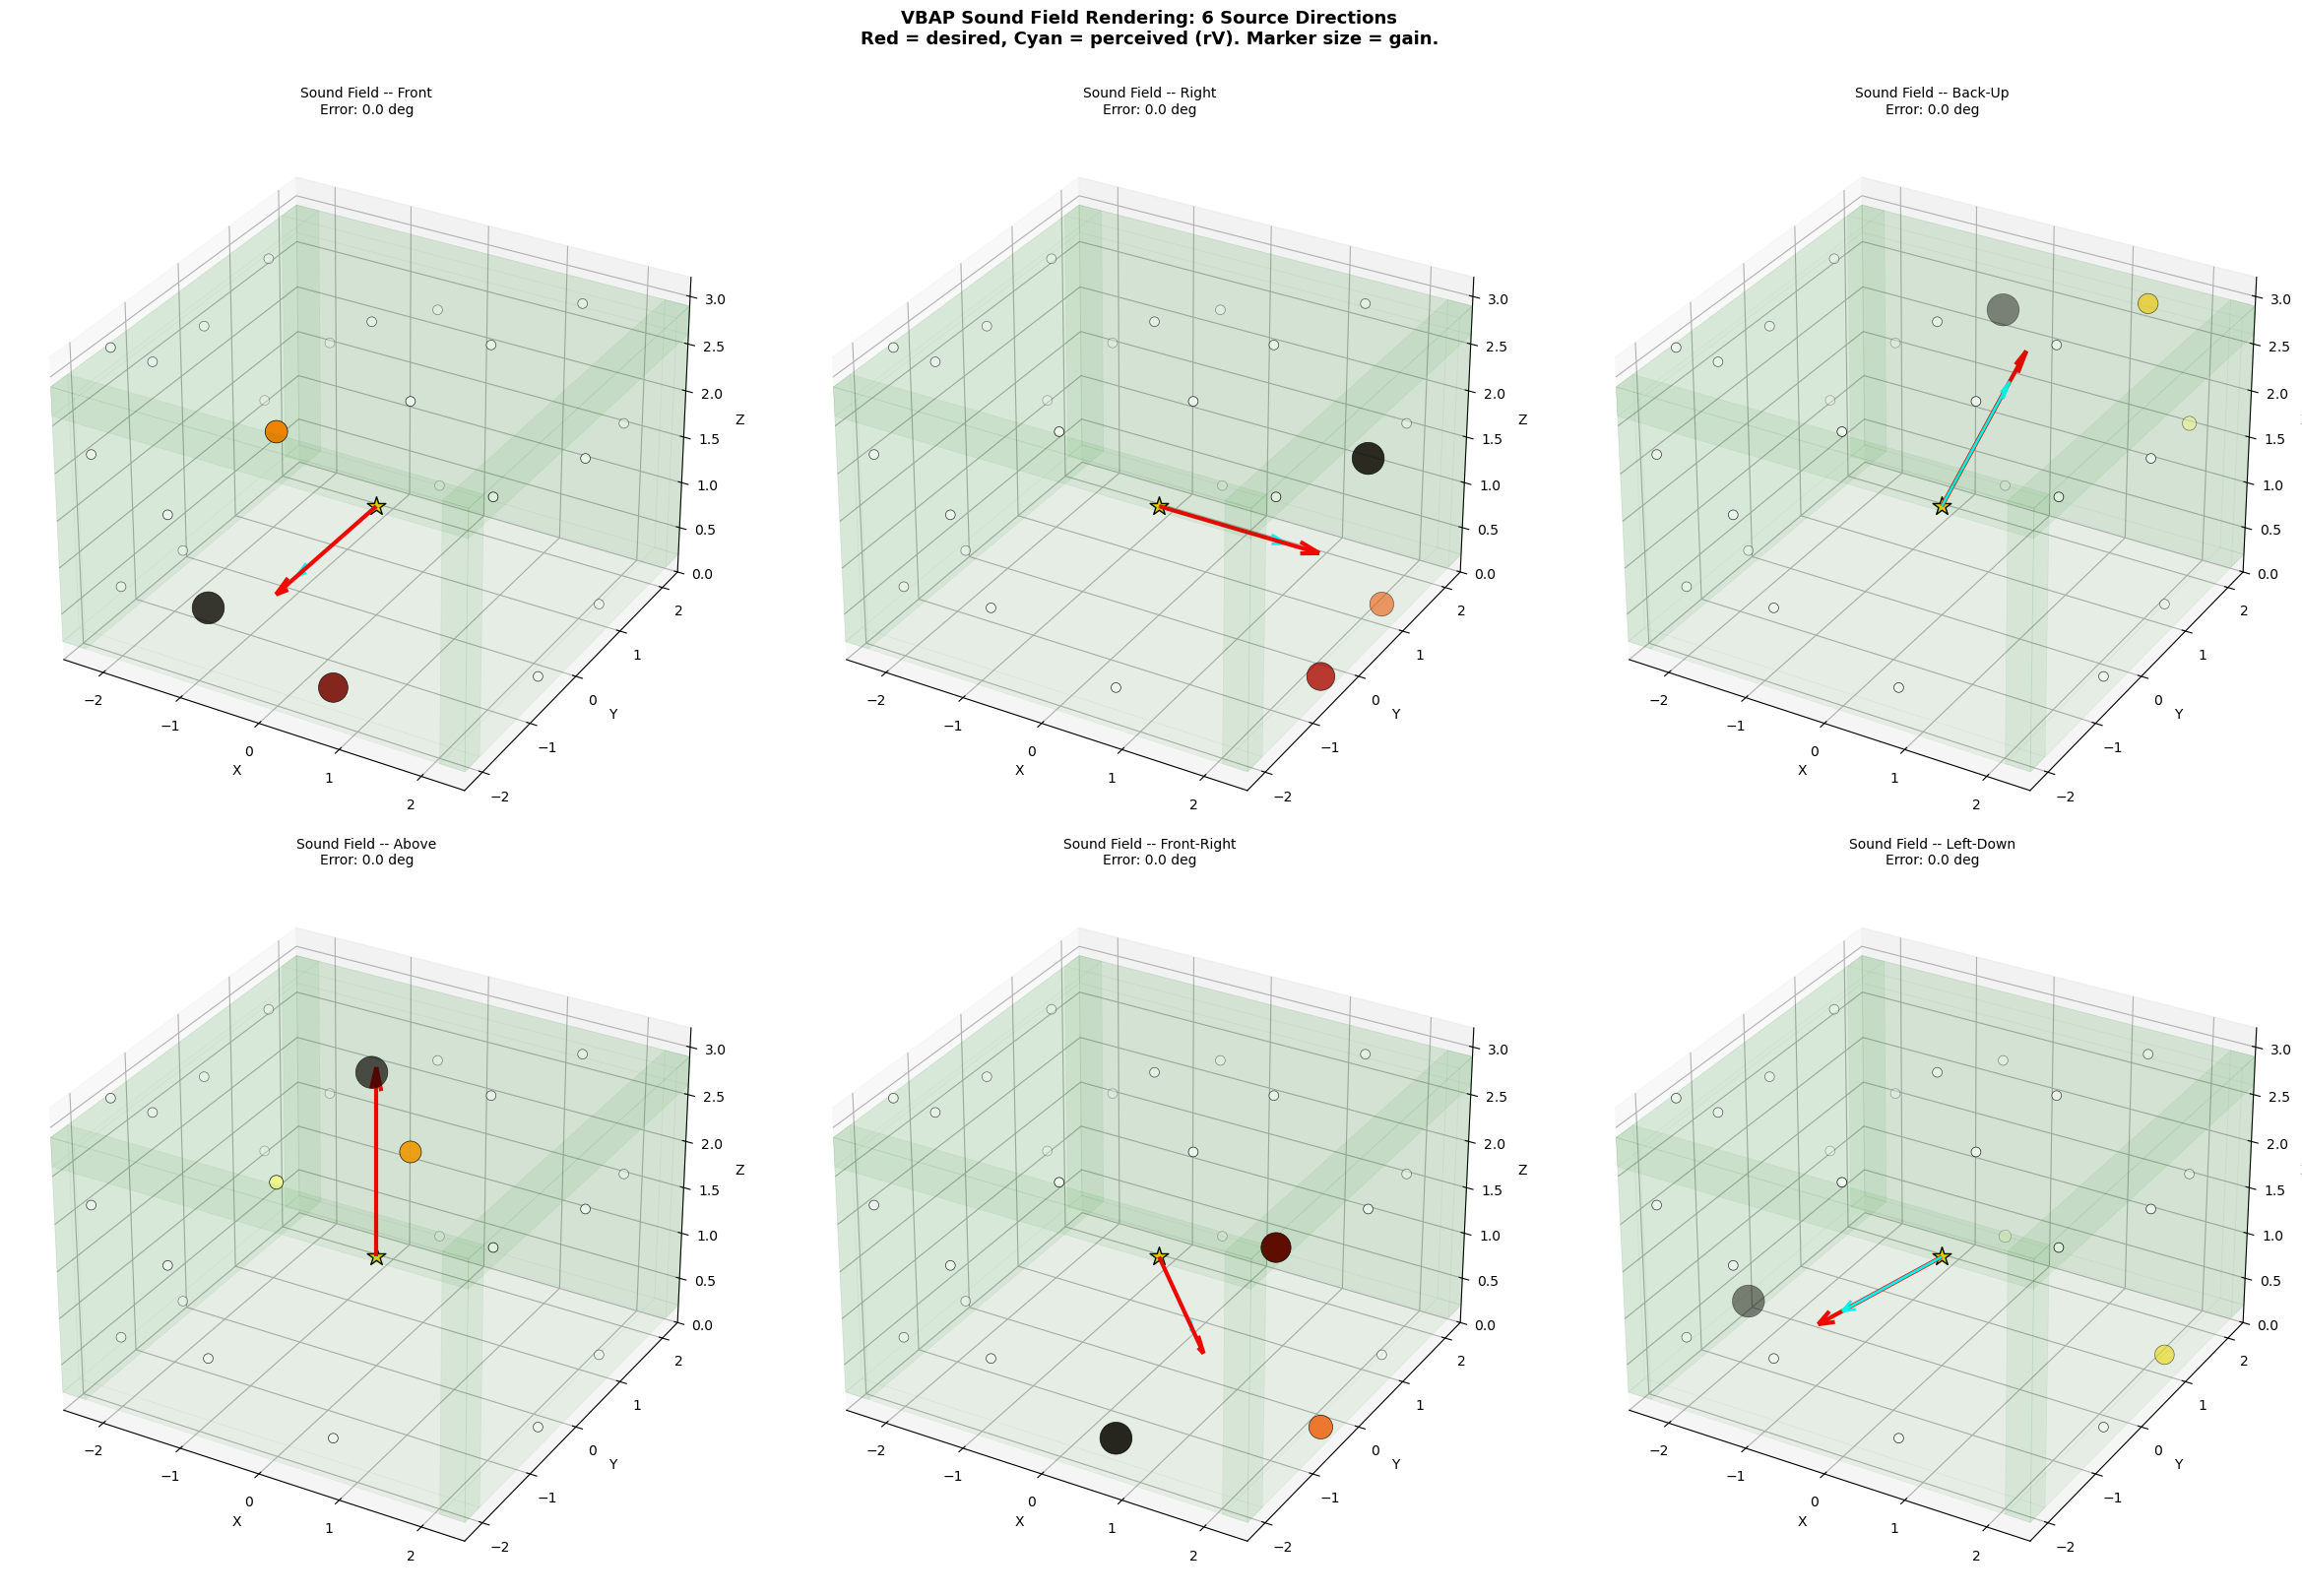

In [19]:
def plot_sound_field(layout, listener, source_dir, title_suffix=''):
    """Render speaker gains for a source direction in the 3D room."""
    rdr = VBAPRenderer(layout, listener)
    d = source_dir / (np.linalg.norm(source_dir) + 1e-12)
    gains = rdr.compute_gains(d, normalize='energy')

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    for box in allowed_boxes:
        plot_box_3d(ax, box, color='green', alpha=0.05)
    for box in forbidden_boxes:
        plot_box_3d(ax, box, color='red', alpha=0.08)

    # Speakers: size and color by gain
    g_abs = np.abs(gains)
    g_max = max(g_abs.max(), 1e-12)
    sizes = 50 + 500 * (g_abs / g_max)
    sc = ax.scatter(layout[:, 0], layout[:, 1], layout[:, 2],
                    c=g_abs, cmap='hot_r', s=sizes, edgecolors='black',
                    linewidth=0.5, vmin=0, vmax=g_max, zorder=5)

    # Listener
    ax.scatter(*listener, c='gold', marker='*', s=300, edgecolors='black', zorder=10)

    # Source direction arrow
    L = 2.0
    ax.quiver(*listener, *(d*L), color='red', linewidth=3, arrow_length_ratio=0.12,
              label=f'Source [{d[0]:.2f},{d[1]:.2f},{d[2]:.2f}]')

    # rV perceived direction
    rV, _ = rdr.compute_rv_re(gains)
    rV_n = np.linalg.norm(rV)
    if rV_n > 1e-12:
        rV_hat = rV / rV_n
        ax.quiver(*listener, *(rV_hat*L*0.8), color='cyan', linewidth=2,
                  arrow_length_ratio=0.12, label='Perceived (rV)')
        err_deg = np.degrees(np.arccos(np.clip(np.dot(d, rV_hat), -1, 1)))
    else:
        err_deg = 180.0

    tri_idx, _ = rdr.find_enclosing_triangle(d)
    if tri_idx >= 0:
        active = list(rdr.triangles[tri_idx])
        status = f'Active speakers: {active}'
    else:
        status = 'NO COVERAGE (gap!)'

    ax.set_xlim(-W-0.5, W+0.5); ax.set_ylim(-D-0.5, D+0.5); ax.set_zlim(0, H+0.8)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Sound Field{title_suffix}\n{status}\n'
                 f'Direction error: {err_deg:.1f} deg')
    ax.legend(loc='upper left', fontsize=8)
    fig.colorbar(sc, ax=ax, shrink=0.5, label='Gain')
    plt.tight_layout()
    plt.show()

# Render several directions
directions = [
    (np.array([0, -1, 0]),     ' -- Front'),
    (np.array([1, 0, 0]),      ' -- Right'),
    (np.array([0, 1, 0.5]),    ' -- Back-Up'),
    (np.array([0, 0, 1]),      ' -- Above'),
    (np.array([0.7, -0.7, 0]), ' -- Front-Right'),
    (np.array([-0.7, 0, -0.5]),' -- Left-Down'),
]

fig, axes = plt.subplots(2, 3, figsize=(24, 16), subplot_kw={'projection': '3d'})
for idx, (src, label) in enumerate(directions):
    ax = axes.ravel()[idx]
    rdr = VBAPRenderer(best_layout, listener_center)
    d = src / (np.linalg.norm(src) + 1e-12)
    gains = rdr.compute_gains(d, normalize='energy')
    g_abs = np.abs(gains)
    g_max = max(g_abs.max(), 1e-12)
    sizes = 50 + 500 * (g_abs / g_max)
    sc = ax.scatter(best_layout[:, 0], best_layout[:, 1], best_layout[:, 2],
                    c=g_abs, cmap='hot_r', s=sizes, edgecolors='black',
                    linewidth=0.5, vmin=0, vmax=g_max, zorder=5)
    ax.scatter(*listener_center, c='gold', marker='*', s=200, edgecolors='black', zorder=10)
    L = 2.0
    ax.quiver(*listener_center, *(d*L), color='red', linewidth=3, arrow_length_ratio=0.12)
    rV, _ = rdr.compute_rv_re(gains)
    rV_n = np.linalg.norm(rV)
    if rV_n > 1e-12:
        rV_hat = rV / rV_n
        ax.quiver(*listener_center, *(rV_hat*L*0.8), color='cyan', linewidth=2, arrow_length_ratio=0.12)
        err_deg = np.degrees(np.arccos(np.clip(np.dot(d, rV_hat), -1, 1)))
    else:
        err_deg = 180.0
    for box in allowed_boxes:
        plot_box_3d(ax, box, color='green', alpha=0.03)
    ax.set_xlim(-W-0.5, W+0.5); ax.set_ylim(-D-0.5, D+0.5); ax.set_zlim(0, H+0.8)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Sound Field{label}\nError: {err_deg:.1f} deg', fontsize=10)
plt.suptitle('VBAP Sound Field Rendering: 6 Source Directions\n'
             'Red = desired, Cyan = perceived (rV). Marker size = gain.',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/sound_field_grid.png', dpi=150, bbox_inches='tight')
plt.show()

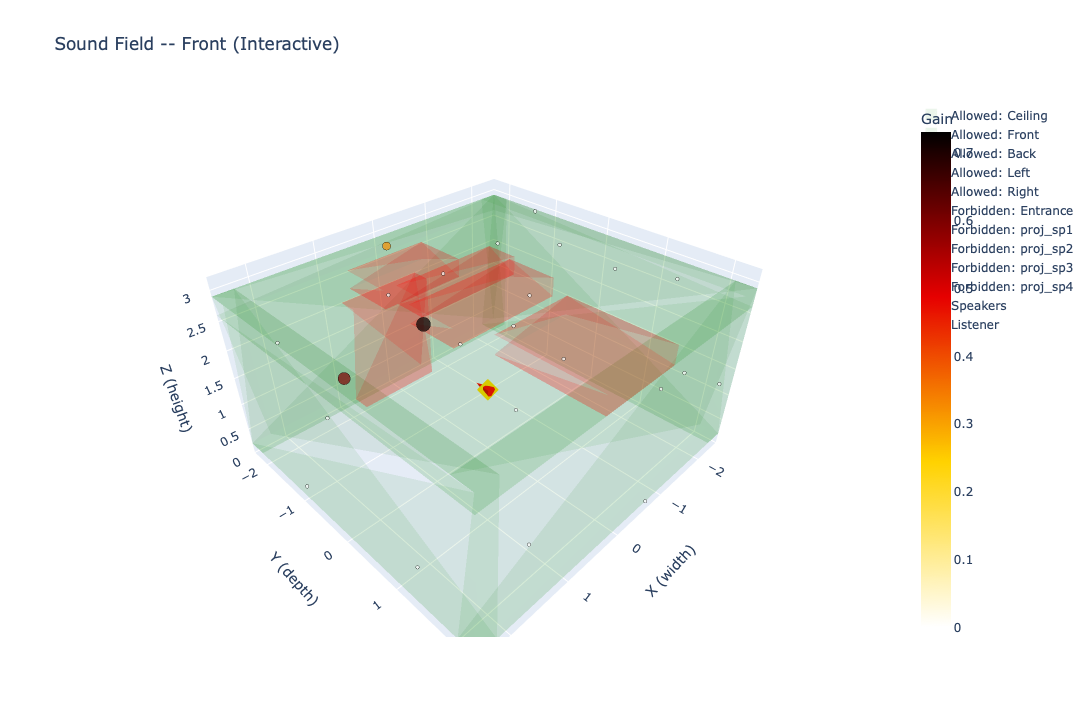

In [20]:
# =====================================================================
# Sound Field Rendering -- Interactive 3D (Plotly)
# =====================================================================

def plotly_sound_field(layout, listener, source_dir, title=''):
    """Interactive Plotly version of sound field rendering."""
    rdr = VBAPRenderer(layout, listener)
    d = source_dir / (np.linalg.norm(source_dir) + 1e-12)
    gains = rdr.compute_gains(d, normalize='energy')
    g_abs = np.abs(gains)
    g_max = max(g_abs.max(), 1e-12)

    traces = plotly_room_traces()

    # Speakers colored by gain
    traces.append(go.Scatter3d(
        x=layout[:, 0], y=layout[:, 1], z=layout[:, 2],
        mode='markers',
        marker=dict(size=4 + 12 * (g_abs / g_max), color=g_abs,
                    colorscale='Hot_r', cmin=0, cmax=g_max, showscale=True,
                    colorbar=dict(title='Gain'),
                    line=dict(width=0.5, color='black')),
        name='Speakers'))

    # Listener
    traces.append(go.Scatter3d(
        x=[listener[0]], y=[listener[1]], z=[listener[2]],
        mode='markers', marker=dict(size=10, color='gold', symbol='diamond'),
        name='Listener'))

    # Source direction as Cone
    L = 2.0
    traces.append(go.Cone(
        x=[listener[0]], y=[listener[1]], z=[listener[2]],
        u=[d[0]*L], v=[d[1]*L], w=[d[2]*L],
        sizemode='absolute', sizeref=0.3, colorscale=[[0,'red'],[1,'red']],
        showscale=False, name='Source direction'))

    # rV perceived direction
    if np.sum(np.abs(gains)) > 1e-12:
        rV, _ = rdr.compute_rv_re(gains)
        rV_n = np.linalg.norm(rV)
        if rV_n > 1e-12:
            rV_hat = rV / rV_n
            traces.append(go.Cone(
                x=[listener[0]], y=[listener[1]], z=[listener[2]],
                u=[rV_hat[0]*L*0.8], v=[rV_hat[1]*L*0.8], w=[rV_hat[2]*L*0.8],
                sizemode='absolute', sizeref=0.25,
                colorscale=[[0,'cyan'],[1,'cyan']],
                showscale=False, name='Perceived (rV)'))

    fig = go.Figure(data=traces,
                     layout=plotly_3d_layout(
                         title=f'Sound Field {title} (Interactive)',
                         xrange=[-W-0.5, W+0.5], yrange=[-D-0.5, D+0.5],
                         zrange=[0, H+0.8]))
    fig.show()

plotly_sound_field(best_layout, listener_center, np.array([0, -1, 0]), title='-- Front')

---
## 9a. Frequency-Dependent Perception Analysis

Human hearing localizes sounds using different cues at different frequencies:

- **Low frequencies (below ~700 Hz)**: The brain uses **interaural time differences (ITD)** --  the tiny delay between sound arriving at the left vs right ear. The VBAP **velocity vector (rV)** predicts perceived direction under this mechanism.

- **High frequencies (above ~1.5 kHz)**: The brain uses **interaural level differences (ILD)** --  the loudness difference between ears caused by head shadowing. The VBAP **energy vector (rE)** predicts perceived direction under this mechanism.

This section visualizes where the optimized layout performs differently at low vs high frequencies. Regions where rV and rE disagree are regions where a listener would perceive frequency-dependent "image splitting" --  the bass appears to come from one direction while the treble comes from another.

**Key quantities:**
- **Angular error**: The angle between the *desired* source direction and the *perceived* direction (rV or rE). Smaller = more accurate.
- **Magnitude** (|rV| or |rE|): How sharply the phantom source is localized. 1.0 = perfectly sharp, <1.0 = diffuse/spread.

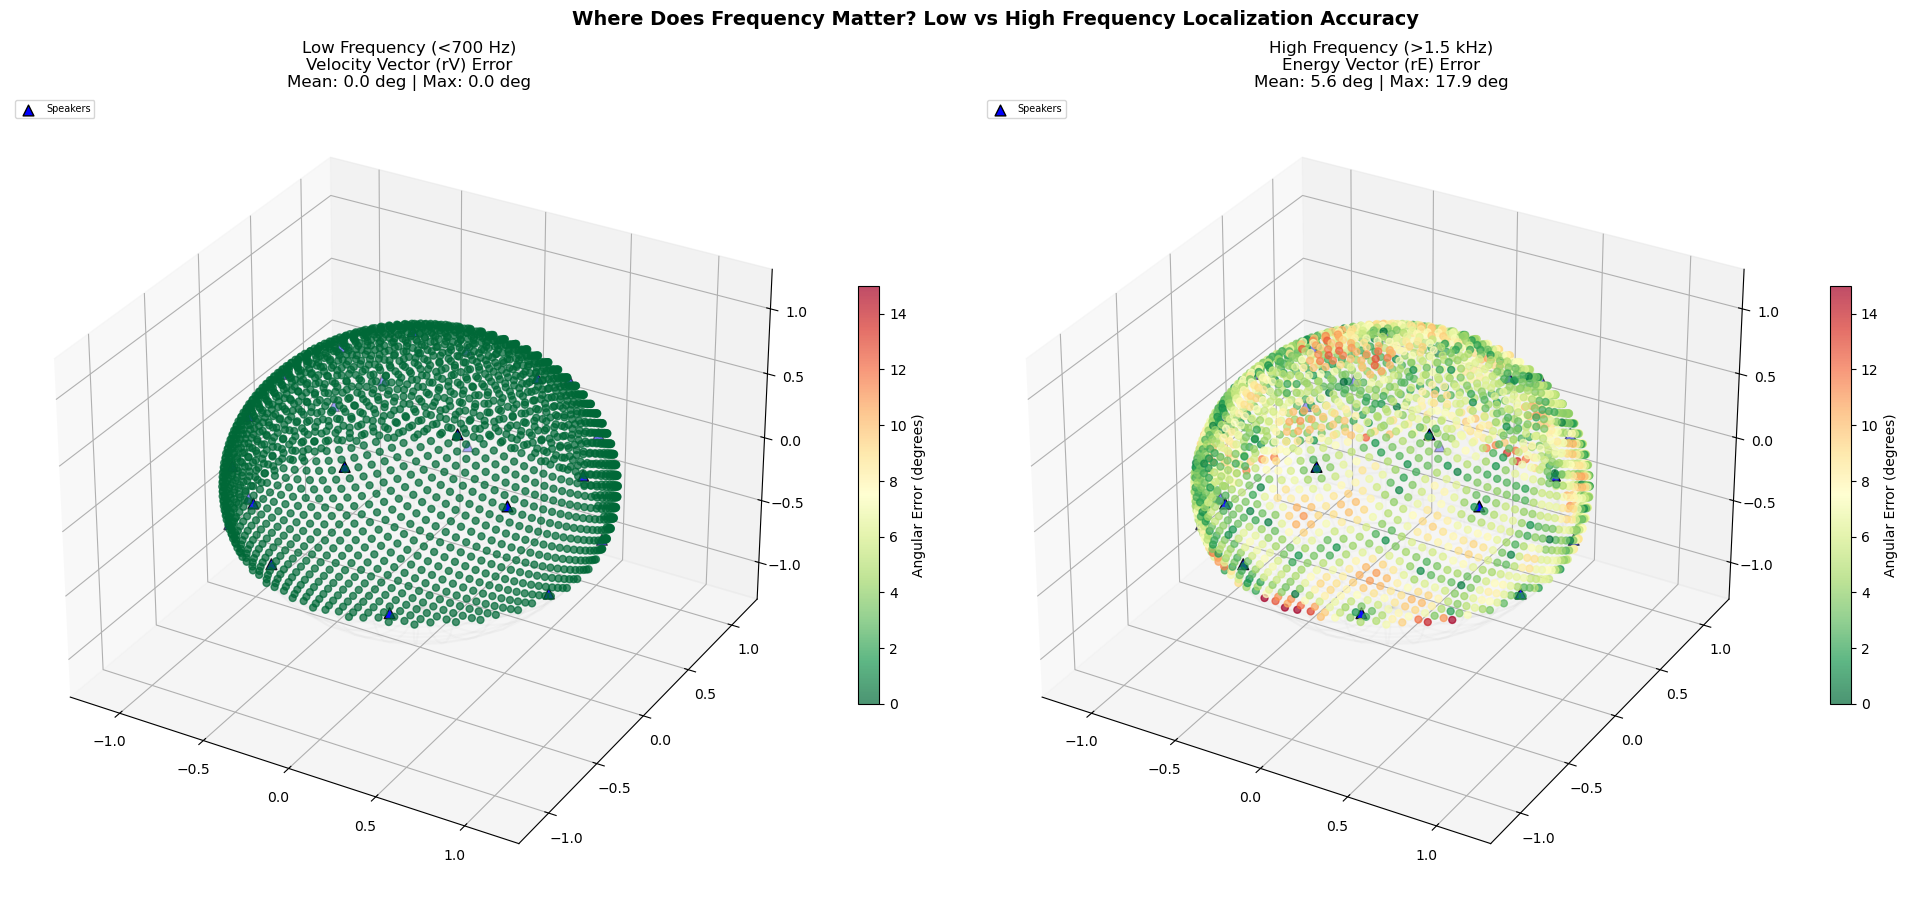

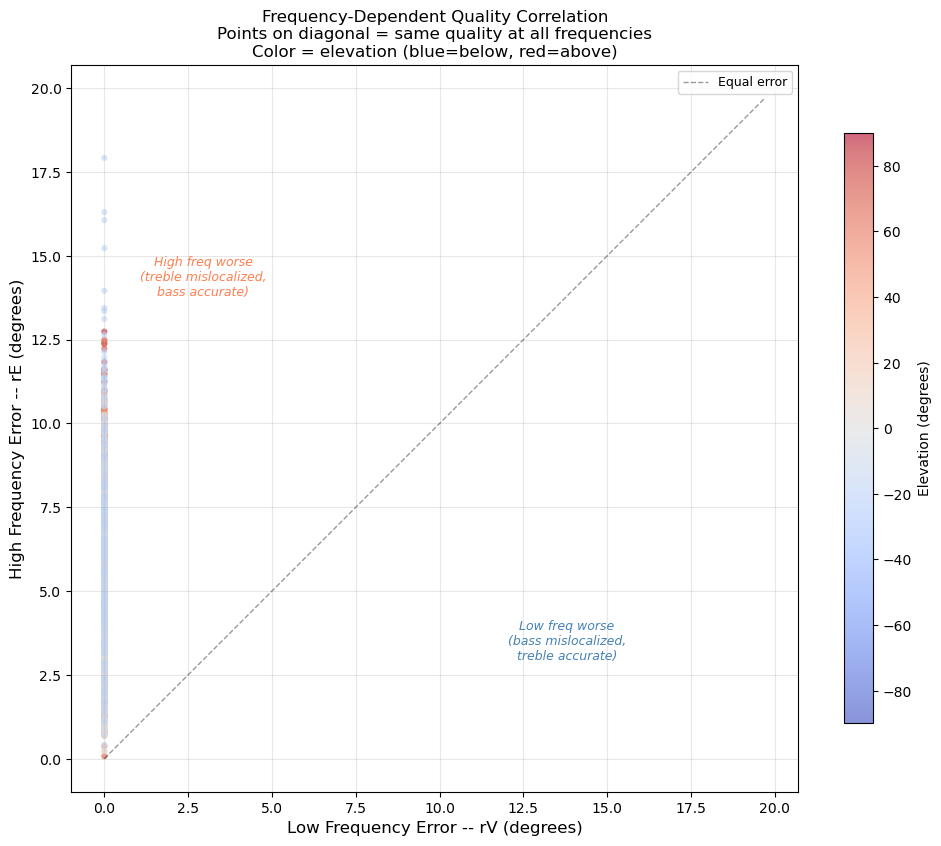

In [21]:
# =====================================================================
# 9a. Frequency-Dependent Perception: Low-freq (rV) vs High-freq (rE)
# =====================================================================

# --- Compute per-direction rV/rE metrics ---
_mf = compute_all_direction_metrics(renderer_opt, test_directions)
dirs_norm_freq = _mf['dirs_norm']
n_dirs_freq = len(dirs_norm_freq)
freq_covered = _mf['covered']
rv_errors_deg = _mf['rv_error_deg']
re_errors_deg = _mf['re_error_deg']
rv_magnitudes = _mf['rv_magnitude']
re_magnitudes = _mf['re_magnitude']
rv_dirs = _mf['rv_unit_dir']
re_dirs = _mf['re_unit_dir']
elevations_freq = _mf['elevations_deg']

# --- Figure 1: Side-by-side sphere heatmaps ---
fig = plt.figure(figsize=(20, 9))

for col, (errors, freq_label) in enumerate([
    (rv_errors_deg, 'Low Frequency (<700 Hz)\nVelocity Vector (rV) Error'),
    (re_errors_deg, 'High Frequency (>1.5 kHz)\nEnergy Vector (rE) Error'),
]):
    ax = fig.add_subplot(1, 2, col + 1, projection='3d')
    ax.plot_wireframe(SPHERE_X * 0.98, SPHERE_Y * 0.98, SPHERE_Z * 0.98,
                      alpha=0.03, color='gray')

    err_vals = errors[freq_covered]
    sc = ax.scatter(
        dirs_norm_freq[freq_covered, 0], dirs_norm_freq[freq_covered, 1],
        dirs_norm_freq[freq_covered, 2],
        c=err_vals, cmap='RdYlGn_r', s=25, alpha=0.7, vmin=0, vmax=15)

    if (~freq_covered).any():
        ax.scatter(dirs_norm_freq[~freq_covered, 0], dirs_norm_freq[~freq_covered, 1],
                   dirs_norm_freq[~freq_covered, 2],
                   c='black', marker='x', s=15, alpha=0.4, label='No coverage')

    ax.scatter(renderer_opt.speaker_dirs[:, 0], renderer_opt.speaker_dirs[:, 1],
               renderer_opt.speaker_dirs[:, 2],
               c='blue', s=60, marker='^', edgecolors='black', zorder=10, label='Speakers')

    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_zlim(-1.3, 1.3)
    mean_err = np.nanmean(err_vals)
    max_err = np.nanmax(err_vals)
    ax.set_title(f'{freq_label}\nMean: {mean_err:.1f} deg | Max: {max_err:.1f} deg')
    ax.legend(fontsize=7, loc='upper left')
    fig.colorbar(sc, ax=ax, shrink=0.5, label='Angular Error (degrees)')

plt.suptitle('Where Does Frequency Matter? Low vs High Frequency Localization Accuracy',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('figures/freq_dependent_sphere.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: rV error vs rE error scatter (correlation) ---
fig, ax = plt.subplots(figsize=(10, 9))

rv_c = rv_errors_deg[freq_covered]
re_c = re_errors_deg[freq_covered]
el_c = elevations_freq[freq_covered]

sc = ax.scatter(rv_c, re_c, c=el_c, cmap='coolwarm', s=20, alpha=0.6,
                edgecolors='none', vmin=-90, vmax=90)

max_val = max(np.nanmax(rv_c), np.nanmax(re_c)) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.4, linewidth=1, label='Equal error')

ax.text(max_val * 0.7, max_val * 0.15, 'Low freq worse\n(bass mislocalized,\ntreble accurate)',
        fontsize=9, ha='center', color='steelblue', fontstyle='italic')
ax.text(max_val * 0.15, max_val * 0.7, 'High freq worse\n(treble mislocalized,\nbass accurate)',
        fontsize=9, ha='center', color='coral', fontstyle='italic')

ax.set_xlabel('Low Frequency Error -- rV (degrees)', fontsize=12)
ax.set_ylabel('High Frequency Error -- rE (degrees)', fontsize=12)
ax.set_title('Frequency-Dependent Quality Correlation\n'
             'Points on diagonal = same quality at all frequencies\n'
             'Color = elevation (blue=below, red=above)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
fig.colorbar(sc, ax=ax, shrink=0.7, label='Elevation (degrees)')

plt.tight_layout()
fig.savefig('figures/freq_dependent_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

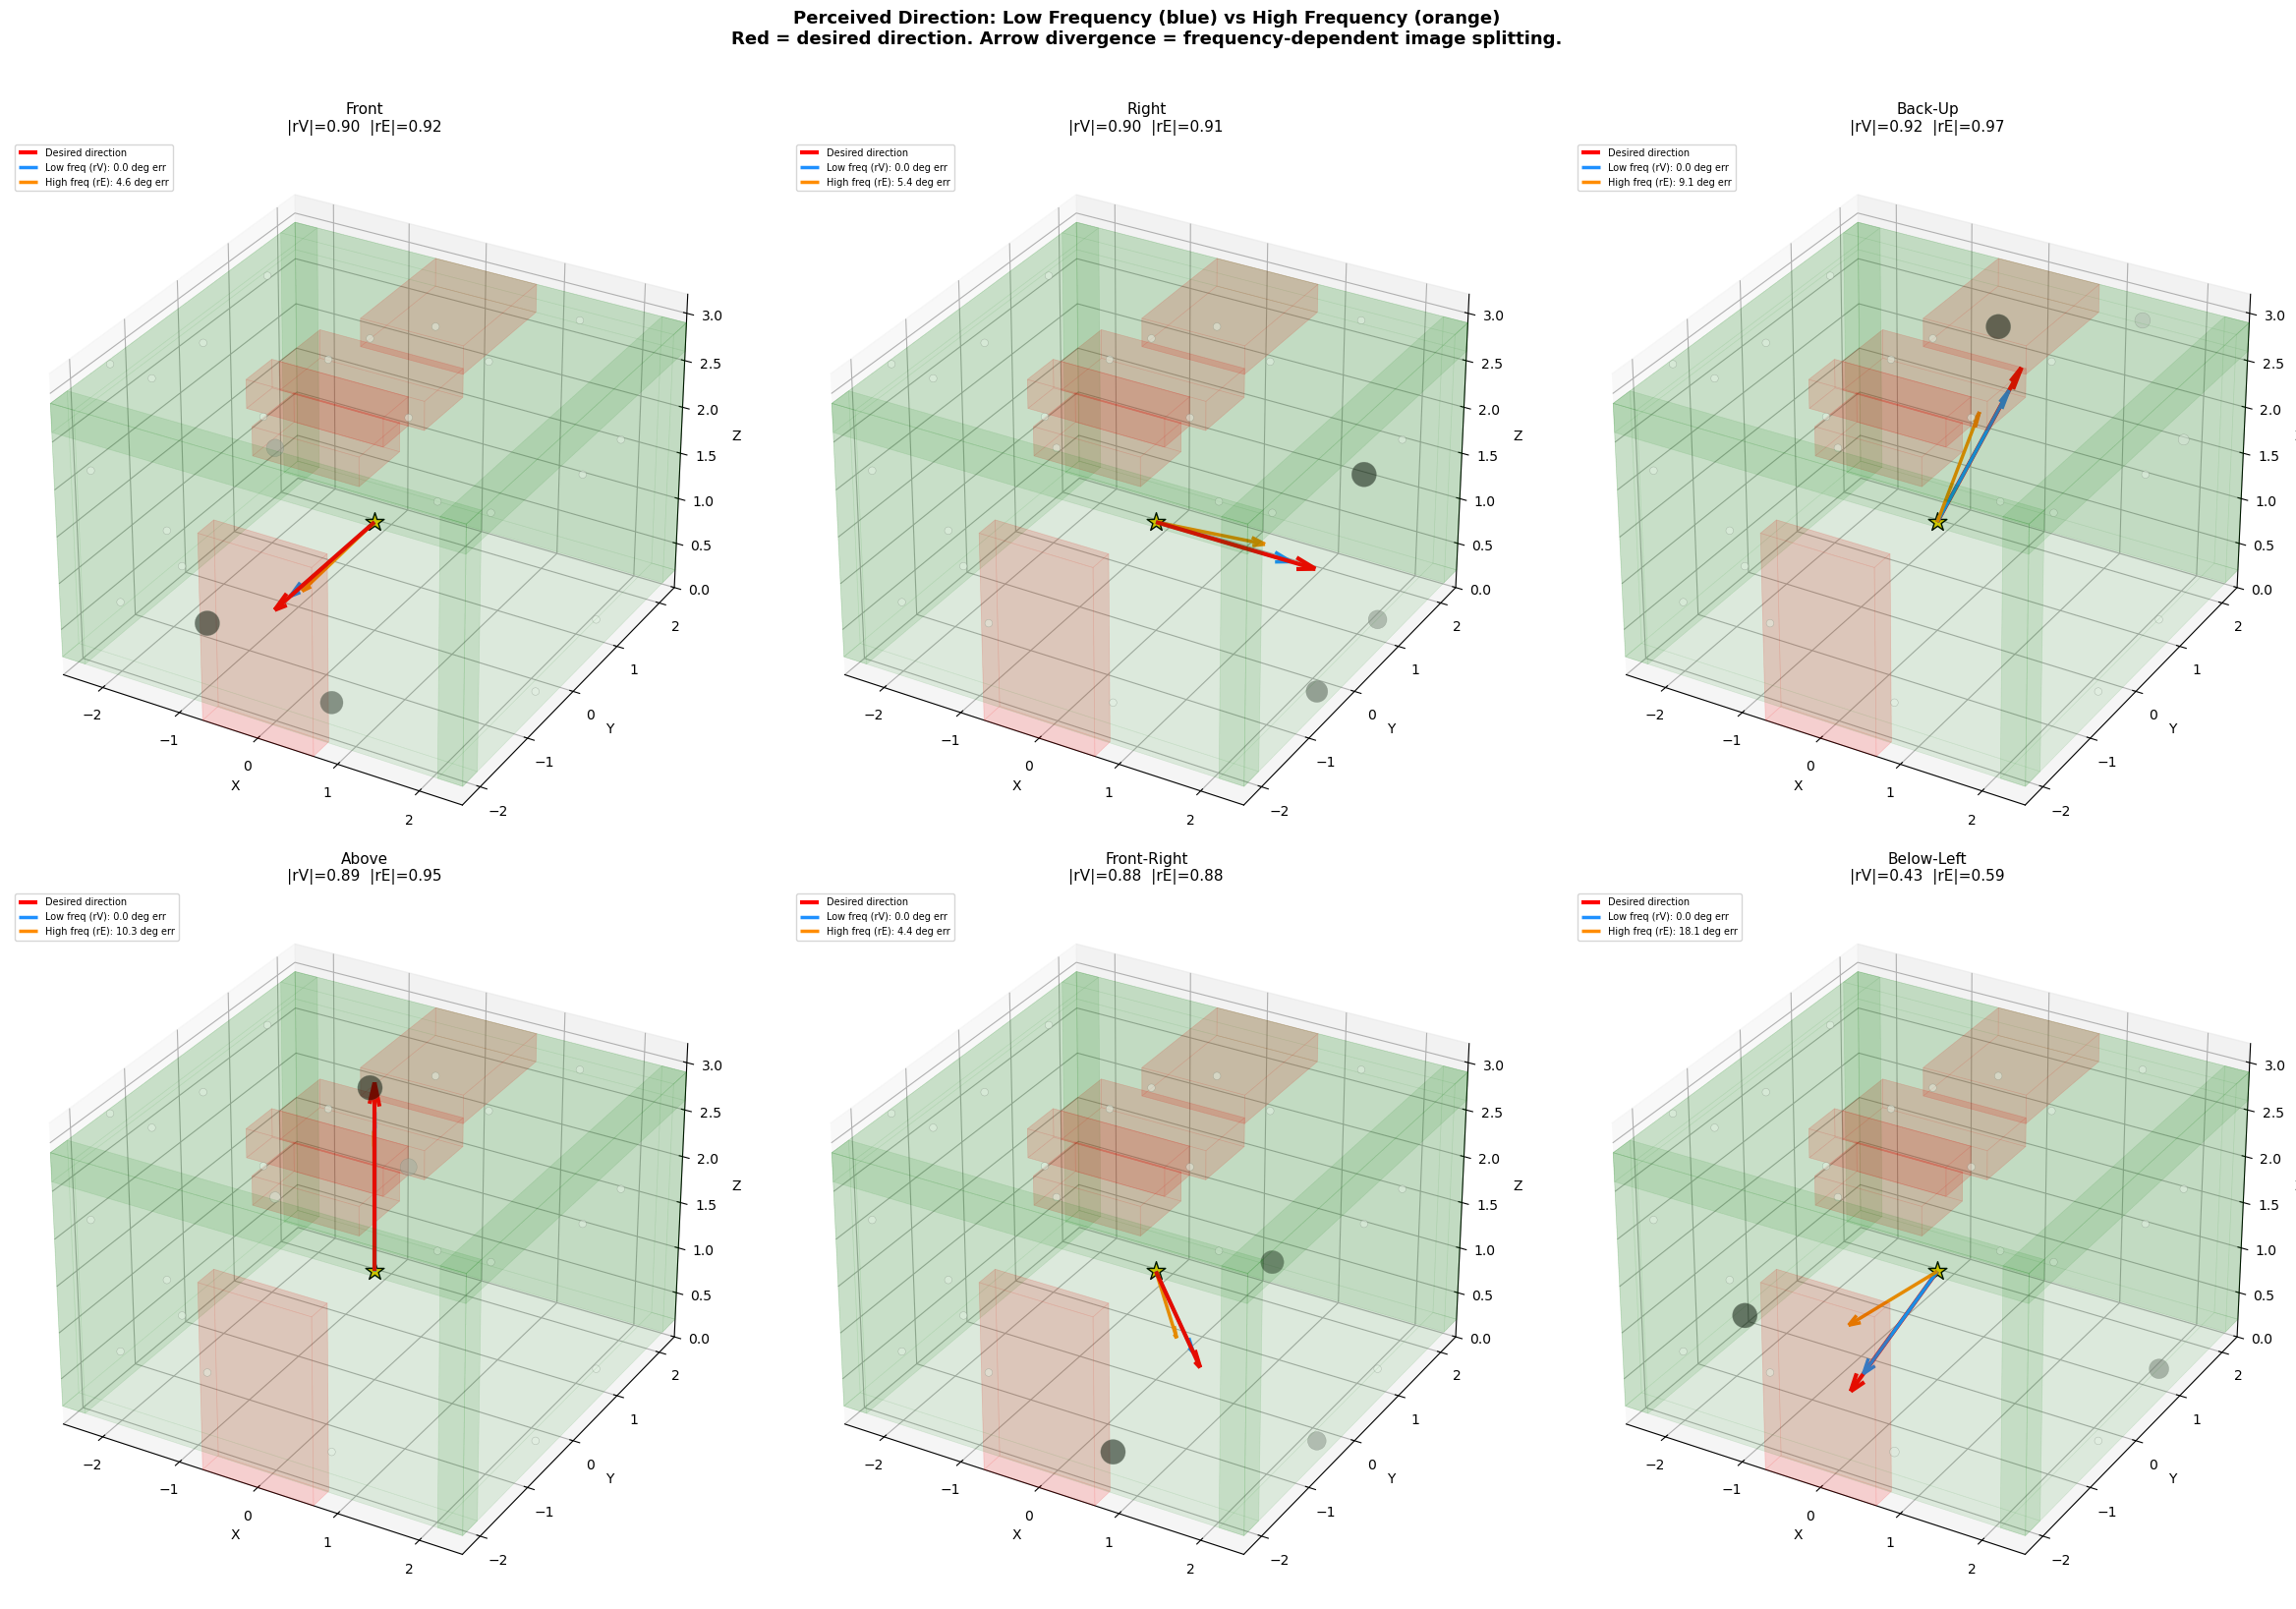

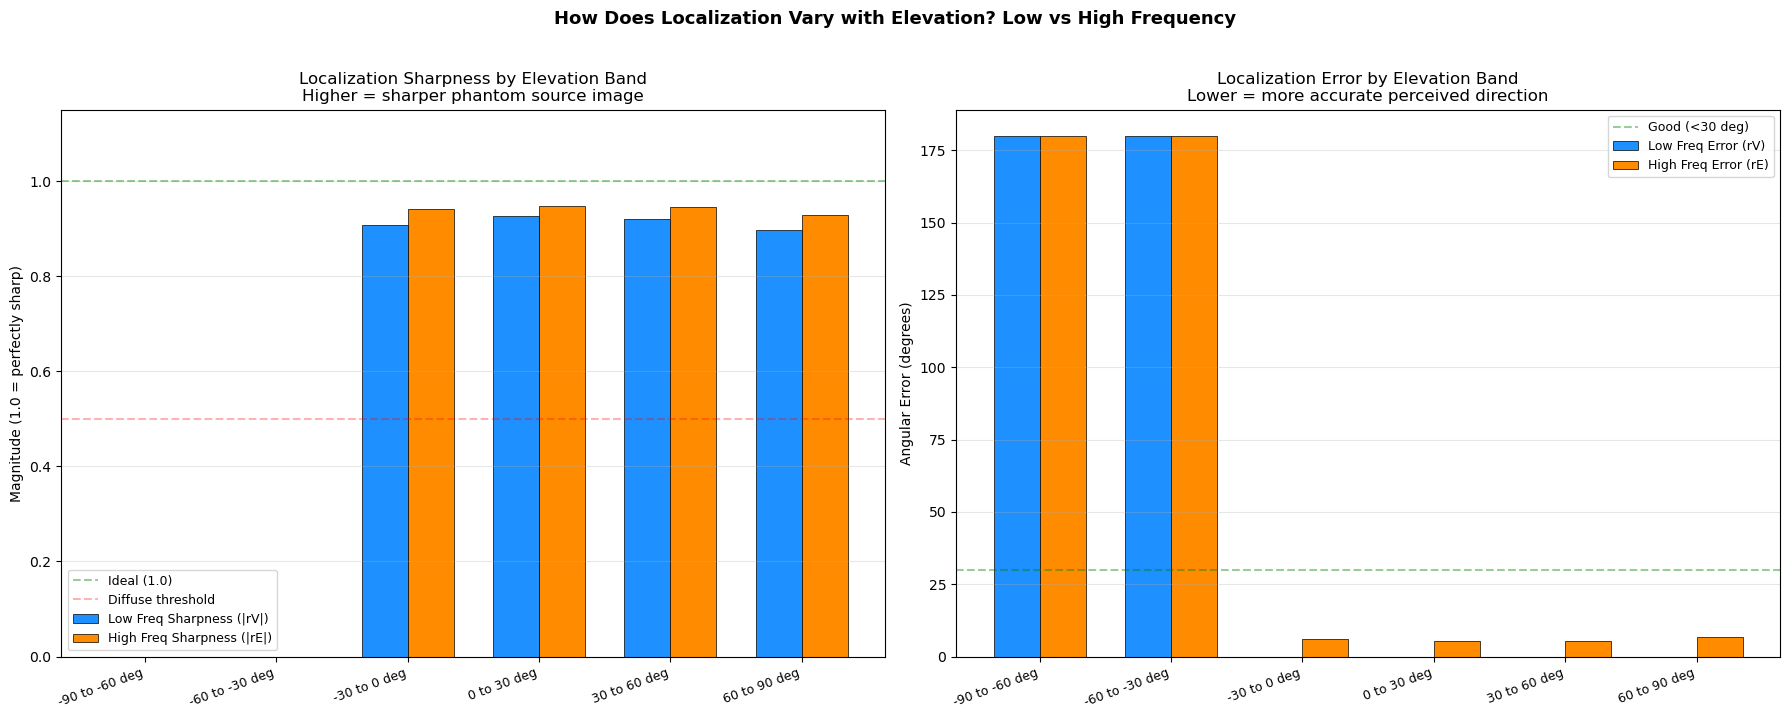

FREQUENCY-DEPENDENT PERCEPTION SUMMARY

Overall (across 2048 covered directions):
  Low-freq  localization error (rV): mean=0.0 deg, max=0.0 deg
  High-freq localization error (rE): mean=5.6 deg, max=17.9 deg
  Low-freq  sharpness (|rV|):  mean=0.917
  High-freq sharpness (|rE|):  mean=0.943

  Low-vs-High frequency perceived direction difference:
    mean=5.6 deg, max=17.9 deg
    Directions with >15 deg frequency split: 4/2048 (0.2%)

  FINDING: High-frequency localization is notably worse than low-frequency.
  Listeners will perceive accurate bass direction but somewhat diffuse treble
  in poorly-covered regions. This is typical for VBAP with spread-out speakers.

  Worst elevation bands for frequency divergence:
    -30 to 0 deg: 6.0 deg gap (worse at high freq)
    0 to 30 deg: 5.2 deg gap (worse at high freq)
    30 to 60 deg: 5.5 deg gap (worse at high freq)
    60 to 90 deg: 6.8 deg gap (worse at high freq)


In [22]:
# =====================================================================
# 9a (continued). Room Arrows + Elevation Bars + Summary
# =====================================================================

# --- Figure 3: Room-view panels with rV/rE arrows ---
representative_dirs = [
    (np.array([0, -1, 0]),      'Front'),
    (np.array([1, 0, 0]),       'Right'),
    (np.array([0, 1, 0.5]),     'Back-Up'),
    (np.array([0, 0, 1]),       'Above'),
    (np.array([0.7, -0.7, 0]),  'Front-Right'),
    (np.array([-0.7, 0, -1]),   'Below-Left'),
]

fig, axes = plt.subplots(2, 3, figsize=(24, 16), subplot_kw={'projection': '3d'})
axes_flat = axes.ravel()

for idx, (src_dir, label) in enumerate(representative_dirs):
    ax = axes_flat[idx]
    d = src_dir / (np.linalg.norm(src_dir) + 1e-12)
    gains = renderer_opt.compute_gains(d, normalize='energy')

    for box in allowed_boxes:
        plot_box_3d(ax, box, color='green', alpha=0.05)
    for box in forbidden_boxes:
        plot_box_3d(ax, box, color='red', alpha=0.08)

    g_abs = np.abs(gains)
    g_max = max(g_abs.max(), 1e-12)
    sizes = 30 + 300 * (g_abs / g_max)
    ax.scatter(best_layout[:, 0], best_layout[:, 1], best_layout[:, 2],
               c=g_abs, cmap='Greys', s=sizes, edgecolors='gray',
               linewidth=0.3, vmin=0, vmax=g_max, alpha=0.5, zorder=3)

    ax.scatter(*listener_center, c='gold', marker='*', s=200, edgecolors='black', zorder=10)

    L = 2.0
    ax.quiver(*listener_center, *(d * L), color='red', linewidth=3,
              arrow_length_ratio=0.12, label='Desired direction')

    if np.sum(np.abs(gains)) > 1e-12:
        rV, rE = renderer_opt.compute_rv_re(gains)
        rV_n = np.linalg.norm(rV)
        rE_n = np.linalg.norm(rE)

        if rV_n > 1e-12:
            rV_hat = rV / rV_n
            rv_err = np.degrees(np.arccos(np.clip(np.dot(d, rV_hat), -1, 1)))
            ax.quiver(*listener_center, *(rV_hat * L * 0.85), color='dodgerblue',
                      linewidth=2.5, arrow_length_ratio=0.12,
                      label=f'Low freq (rV): {rv_err:.1f} deg err')

        if rE_n > 1e-12:
            rE_hat = rE / rE_n
            re_err = np.degrees(np.arccos(np.clip(np.dot(d, rE_hat), -1, 1)))
            ax.quiver(*listener_center, *(rE_hat * L * 0.7), color='darkorange',
                      linewidth=2.5, arrow_length_ratio=0.12,
                      label=f'High freq (rE): {re_err:.1f} deg err')

        status = f'|rV|={rV_n:.2f}  |rE|={rE_n:.2f}'
    else:
        status = 'NO COVERAGE'

    ax.set_xlim(-W - 0.5, W + 0.5)
    ax.set_ylim(-D - 0.5, D + 0.5)
    ax.set_zlim(0, H + 0.8)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'{label}\n{status}', fontsize=11)
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Perceived Direction: Low Frequency (blue) vs High Frequency (orange)\n'
             'Red = desired direction. Arrow divergence = frequency-dependent image splitting.',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('figures/freq_dependent_room_arrows.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 4: |rV| and |rE| by elevation band ---
elev_bands = ELEVATION_BANDS  # defined in Cell 5
elev_band_labels = [f'{lo} to {hi} deg' for lo, hi in elev_bands]

rv_mag_by_band = []
re_mag_by_band = []
rv_err_by_band = []
re_err_by_band = []

for (lo, hi) in elev_bands:
    mask = (elevations_freq >= lo) & (elevations_freq < hi) & freq_covered
    if mask.sum() > 0:
        rv_mag_by_band.append(np.nanmean(rv_magnitudes[mask]))
        re_mag_by_band.append(np.nanmean(re_magnitudes[mask]))
        rv_err_by_band.append(np.nanmean(rv_errors_deg[mask]))
        re_err_by_band.append(np.nanmean(re_errors_deg[mask]))
    else:
        rv_mag_by_band.append(0)
        re_mag_by_band.append(0)
        rv_err_by_band.append(180)
        re_err_by_band.append(180)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: sharpness (magnitude)
ax = axes[0]
x = np.arange(len(elev_band_labels))
w = 0.35
ax.bar(x - w/2, rv_mag_by_band, w, label='Low Freq Sharpness (|rV|)',
       color='dodgerblue', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, re_mag_by_band, w, label='High Freq Sharpness (|rE|)',
       color='darkorange', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(elev_band_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Magnitude (1.0 = perfectly sharp)')
ax.set_title('Localization Sharpness by Elevation Band\n'
             'Higher = sharper phantom source image')
ax.axhline(1.0, color='green', linestyle='--', alpha=0.4, label='Ideal (1.0)')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='Diffuse threshold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Right: angular error
ax = axes[1]
ax.bar(x - w/2, rv_err_by_band, w, label='Low Freq Error (rV)',
       color='dodgerblue', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, re_err_by_band, w, label='High Freq Error (rE)',
       color='darkorange', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(elev_band_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Angular Error (degrees)')
ax.set_title('Localization Error by Elevation Band\n'
             'Lower = more accurate perceived direction')
ax.axhline(30, color='green', linestyle='--', alpha=0.4, label='Good (<30 deg)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('How Does Localization Vary with Elevation? Low vs High Frequency',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('figures/freq_dependent_elevation_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print('=' * 70)
print('FREQUENCY-DEPENDENT PERCEPTION SUMMARY')
print('=' * 70)

rv_mean = np.nanmean(rv_errors_deg[freq_covered])
re_mean = np.nanmean(re_errors_deg[freq_covered])
rv_max = np.nanmax(rv_errors_deg[freq_covered])
re_max = np.nanmax(re_errors_deg[freq_covered])
rv_mag_mean = np.nanmean(rv_magnitudes[freq_covered])
re_mag_mean = np.nanmean(re_magnitudes[freq_covered])

print(f'\nOverall (across {freq_covered.sum()} covered directions):')
print(f'  Low-freq  localization error (rV): mean={rv_mean:.1f} deg, max={rv_max:.1f} deg')
print(f'  High-freq localization error (rE): mean={re_mean:.1f} deg, max={re_max:.1f} deg')
print(f'  Low-freq  sharpness (|rV|):  mean={rv_mag_mean:.3f}')
print(f'  High-freq sharpness (|rE|):  mean={re_mag_mean:.3f}')

# rV-rE divergence (vectorized using stored unit directions)
valid_div = ~np.isnan(rv_dirs[:, 0]) & ~np.isnan(re_dirs[:, 0])
dots = np.sum(rv_dirs[valid_div] * re_dirs[valid_div], axis=1)
divergence_deg = np.degrees(np.arccos(np.clip(dots, -1, 1)))

print(f'\n  Low-vs-High frequency perceived direction difference:')
print(f'    mean={np.mean(divergence_deg):.1f} deg, max={np.max(divergence_deg):.1f} deg')
n_split = np.sum(divergence_deg > 15)
print(f'    Directions with >15 deg frequency split: {n_split}/{len(divergence_deg)} '
      f'({100*n_split/len(divergence_deg):.1f}%)')

if re_mean > rv_mean * 1.3:
    print('\n  FINDING: High-frequency localization is notably worse than low-frequency.')
    print('  Listeners will perceive accurate bass direction but somewhat diffuse treble')
    print('  in poorly-covered regions. This is typical for VBAP with spread-out speakers.')
elif rv_mean > re_mean * 1.3:
    print('\n  FINDING: Low-frequency localization is notably worse than high-frequency.')
    print('  This is unusual and suggests some ill-conditioned VBAP triangles.')
else:
    print('\n  FINDING: Low and high frequency localization quality are comparable.')
    print('  The layout provides consistent spatial quality across the audible spectrum.')

print(f'\n  Worst elevation bands for frequency divergence:')
for (lo, hi), rv_e, re_e in zip(elev_bands, rv_err_by_band, re_err_by_band):
    diff = abs(rv_e - re_e)
    if diff > 5:
        worse_at = 'high freq' if re_e > rv_e else 'low freq'
        print(f'    {lo} to {hi} deg: {diff:.1f} deg gap (worse at {worse_at})')

---
## 10. Metrics Summary
Quantitative comparison of initial vs optimized layout across all VBAP quality metrics.

In [23]:
# Uses cached metrics computed in Cells 10 (initial) and 22 (optimized).
# Re-run those cells if you modify layouts, otherwise these values will be stale.
init_m = init_quality_metrics
opt_m = opt_quality_metrics

print(f'{"Metric":<25} {"Initial":>12} {"Optimized":>12} {"Change":>12}')
print('=' * 65)
for key in init_m:
    iv = init_m[key]
    ov = opt_m[key]
    if key == 'coverage':
        delta = ov - iv
        better = delta > 0
    else:
        delta = iv - ov  # lower is better
        better = delta > 0
    arrow = ' +' if better else '  '
    print(f'{key:<25} {iv:>12.4f} {ov:>12.4f} {arrow} {delta:>+10.4f}')

# Multi-listener evaluation if using grid
if len(listener_positions) > 1:
    print(f'\n--- Multi-listener cost (across {len(listener_positions)} positions) ---')
    full_result = score_layout(best_layout, listener_positions, test_directions, COST_WEIGHTS)
    print(f'Total cost:     {full_result["total_cost"]:.6f}')
    print(f'Spatial cost:   {full_result["spatial_cost"]:.6f}')
    print(f'Mean coverage:  {full_result["mean_coverage"]:.4f}')
    print(f'Worst coverage: {full_result["worst_coverage"]:.4f}')
    print(f'Per-listener costs: {[f"{c:.4f}" for c in full_result["per_listener_costs"]]}')

Metric                         Initial    Optimized       Change
coverage                        1.0000       1.0000       +0.0000
upper_coverage                  1.0000       1.0000       +0.0000
mean_loc_error                  0.0000       0.0000  +    +0.0000
mean_energy_err                 0.0405       0.0313  +    +0.0092
mean_rV_mag_error               0.0412       0.0082  +    +0.0330
mean_rE_mag_error               0.0227       0.0047  +    +0.0179
energy_var                      0.0046       0.0019  +    +0.0028
mean_cond                       0.8373       0.8212  +    +0.0162
angular_uniformity              0.0447       0.0230  +    +0.0218
max_gap                         0.7468       0.7504       -0.0035
upper_max_gap                   0.5880       0.5273  +    +0.0607


---
## 10a. Worst-Case Coverage Gap Investigation
Identifies which test directions fail at each listener position, highlights the worst-case position,
and determines if gaps fall in perceptually critical regions (frontal hemisphere).

Per-listener coverage (1 positions):
  Best:  100.00% (listener 0, pos=[0.  0.  1.2])
  Worst: 100.00% (listener 0, pos=[0.  0.  1.2])
  Mean:  100.00%
  Std:   0.0000

No coverage gaps at worst-case listener position -- perfect coverage!


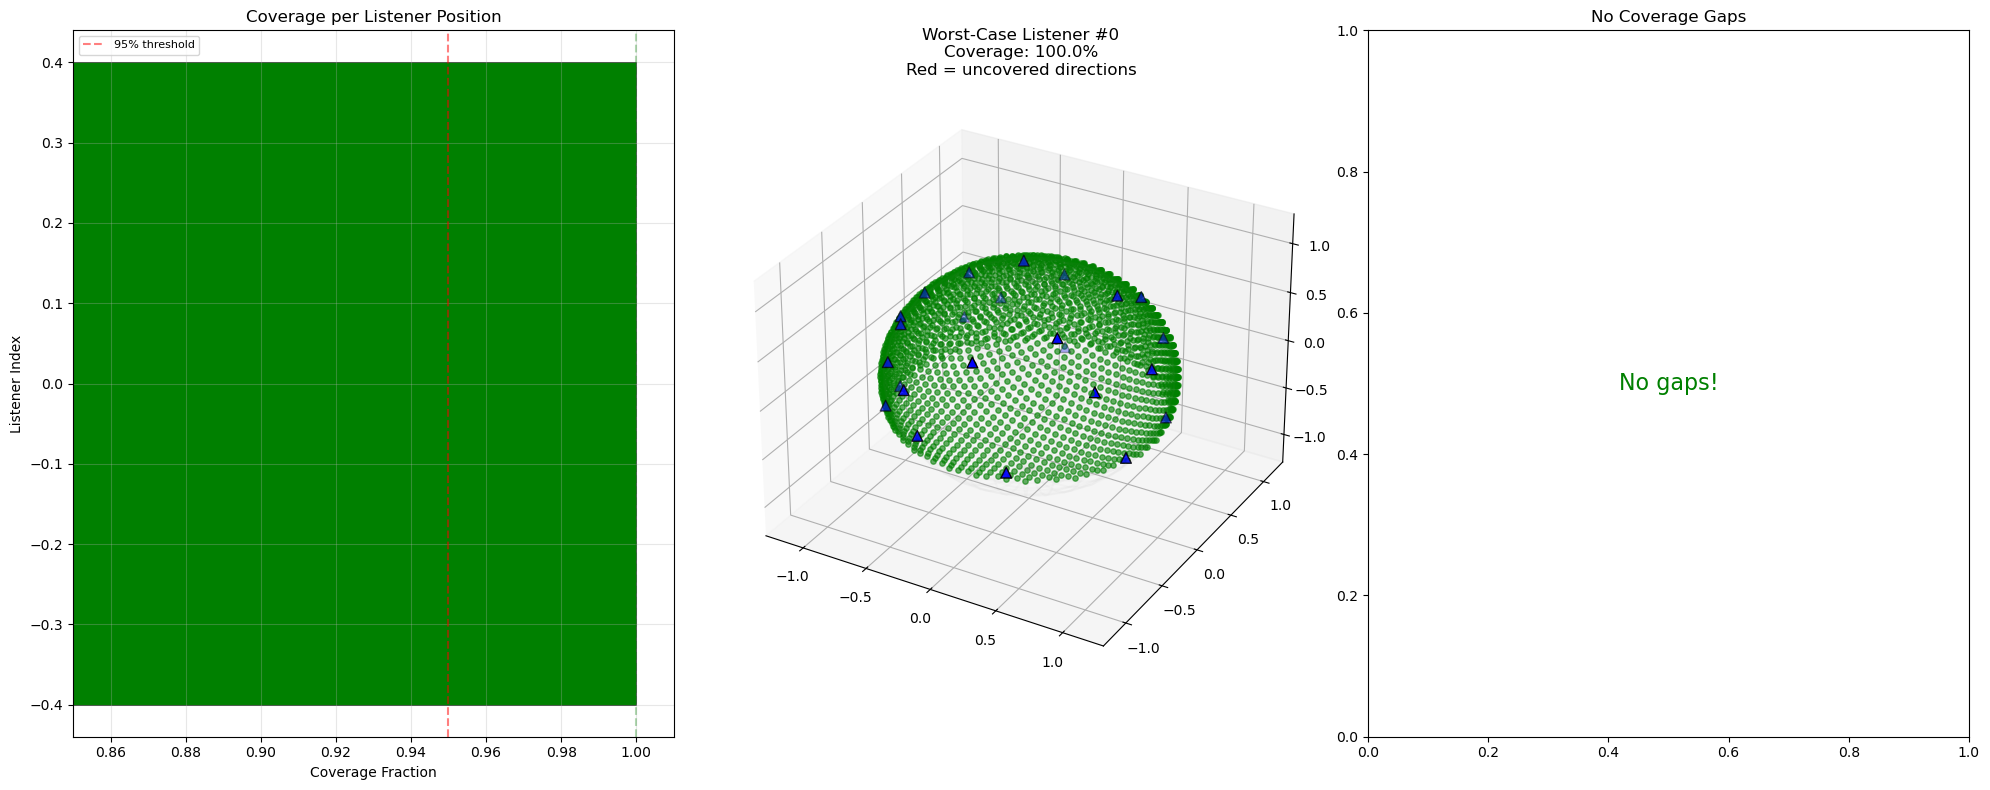

In [24]:
# =====================================================================
# Worst-Case Coverage Gap Analysis
# =====================================================================

# Analyze coverage at every listener position
per_listener_coverage = []
per_listener_gaps = []  # (listener_idx, gap_directions)

for li, lpos in enumerate(listener_positions):
    renderer = VBAPRenderer(best_layout, lpos)
    m = compute_all_direction_metrics(renderer, test_directions)
    cov_frac = m['covered'].mean()
    gap_dirs_arr = m['dirs_norm'][~m['covered']]
    per_listener_coverage.append(cov_frac)
    per_listener_gaps.append(gap_dirs_arr if len(gap_dirs_arr) > 0 else np.empty((0, 3)))

cov_arr = np.array(per_listener_coverage)
worst_idx = np.argmin(cov_arr)
best_idx = np.argmax(cov_arr)

print(f'Per-listener coverage ({len(listener_positions)} positions):')
print(f'  Best:  {cov_arr[best_idx]:.2%} (listener {best_idx}, pos={listener_positions[best_idx]})')
print(f'  Worst: {cov_arr[worst_idx]:.2%} (listener {worst_idx}, pos={listener_positions[worst_idx]})')
print(f'  Mean:  {cov_arr.mean():.2%}')
print(f'  Std:   {cov_arr.std():.4f}')

# Classify gap directions by hemisphere
worst_gaps = per_listener_gaps[worst_idx]
if len(worst_gaps) > 0:
    # Frontal hemisphere: directions with negative Y (toward front/entrance)
    frontal_mask = worst_gaps[:, 1] < 0
    upper_mask = worst_gaps[:, 2] > 0
    lower_mask = worst_gaps[:, 2] < 0

    n_total = len(worst_gaps)
    n_frontal = frontal_mask.sum()
    n_rear = n_total - n_frontal
    n_upper = upper_mask.sum()
    n_lower = lower_mask.sum()

    print(f'\nWorst-case listener gap analysis ({n_total} uncovered directions):')
    print(f'  Frontal hemisphere (toward entrance): {n_frontal} ({100*n_frontal/n_total:.0f}%)')
    print(f'  Rear hemisphere (toward back wall):   {n_rear} ({100*n_rear/n_total:.0f}%)')
    print(f'  Upper hemisphere (above ear level):   {n_upper} ({100*n_upper/n_total:.0f}%)')
    print(f'  Lower hemisphere (below ear level):   {n_lower} ({100*n_lower/n_total:.0f}%)')

    if n_frontal > n_total * 0.5:
        print('\n  WARNING: Majority of gaps are in the frontal hemisphere -- perceptually critical!')
    elif n_lower > n_total * 0.7:
        print('\n  NOTE: Most gaps are below ear level -- expected (no floor speakers).')
    else:
        print('\n  Gaps are distributed across hemispheres.')

    # Compute elevation and azimuth of gap directions
    elevations = np.degrees(np.arcsin(np.clip(worst_gaps[:, 2], -1, 1)))
    azimuths = np.degrees(np.arctan2(worst_gaps[:, 0], -worst_gaps[:, 1]))

    print(f'\n  Gap elevation range:  {elevations.min():.1f} deg to {elevations.max():.1f} deg')
    print(f'  Gap azimuth range:   {azimuths.min():.1f} deg to {azimuths.max():.1f} deg')
else:
    print('\nNo coverage gaps at worst-case listener position -- perfect coverage!')

# Visualization
fig = plt.figure(figsize=(20, 8))

# 1. Coverage bar chart per listener
ax1 = fig.add_subplot(131)
colors_bar = ['red' if c < 0.95 else 'orange' if c < 0.99 else 'green' for c in cov_arr]
ax1.barh(range(len(cov_arr)), cov_arr, color=colors_bar, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Coverage Fraction')
ax1.set_ylabel('Listener Index')
ax1.set_title('Coverage per Listener Position')
ax1.axvline(0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
ax1.axvline(1.0, color='green', linestyle='--', alpha=0.3)
ax1.set_xlim(0.85, 1.01)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Gap directions on sphere (worst-case listener)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_wireframe(SPHERE_X*0.98, SPHERE_Y*0.98, SPHERE_Z*0.98, alpha=0.03, color='gray')

# Plot all test directions: green=covered, red=gap
renderer_worst = VBAPRenderer(best_layout, listener_positions[worst_idx])
worst_spk_dirs = renderer_worst.speaker_dirs
for td in test_directions:
    d = td / (np.linalg.norm(td) + 1e-12)
    gains = renderer_worst.compute_gains(d, normalize='energy')
    c = 'green' if np.sum(np.abs(gains)) > 1e-12 else 'red'
    ax2.scatter(d[0], d[1], d[2], c=c, s=15, alpha=0.6)

ax2.scatter(worst_spk_dirs[:, 0], worst_spk_dirs[:, 1], worst_spk_dirs[:, 2],
            c='blue', s=60, marker='^', edgecolors='black', zorder=10)
ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-1.3, 1.3); ax2.set_zlim(-1.3, 1.3)
ax2.set_title(f'Worst-Case Listener #{worst_idx}\n'
              f'Coverage: {cov_arr[worst_idx]:.1%}\n'
              f'Red = uncovered directions')

# 3. Gap heatmap: elevation vs azimuth
ax3 = fig.add_subplot(133)
if len(worst_gaps) > 0:
    ax3.scatter(azimuths, elevations, c='red', s=40, alpha=0.7, edgecolors='black',
                linewidth=0.5, label=f'{len(worst_gaps)} gap directions')
    ax3.axhline(0, color='gray', linestyle='-', alpha=0.3, label='Ear level')
    ax3.axhspan(-90, 0, alpha=0.05, color='blue', label='Below ear level')
    ax3.axvspan(-90, 90, alpha=0.05, color='yellow', label='Frontal hemisphere')
    ax3.set_xlabel('Azimuth (deg)')
    ax3.set_ylabel('Elevation (deg)')
    ax3.set_title(f'Gap Directions (Worst Listener)\nElevation vs Azimuth')
    ax3.set_xlim(-180, 180); ax3.set_ylim(-90, 90)
    ax3.legend(fontsize=7, loc='upper right')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No gaps!', ha='center', va='center', fontsize=16, color='green',
             transform=ax3.transAxes)
    ax3.set_title('No Coverage Gaps')

plt.tight_layout()
fig.savefig('figures/coverage_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10b. Left-Right Asymmetry Analysis
Explains the asymmetric speaker distribution by examining allowed/forbidden region geometry
and angular coverage per side.

In [25]:
# =====================================================================
# Left-Right Asymmetry Analysis
# =====================================================================

# 1. Available volume per surface
print('=== Feasible Region Geometry ===\n')
print(f'{"Surface":<15} {"Volume (m^3)":>12} {"X range":>20} {"Y range":>20} {"Z range":>20}')
print('-' * 90)
for box in allowed_boxes:
    mn, mx = box.min_pt, box.max_pt
    vol = box.volume
    print(f'{box.label:<15} {vol:>12.3f} '
          f'[{mn[0]:+.2f}, {mx[0]:+.2f}]     '
          f'[{mn[1]:+.2f}, {mx[1]:+.2f}]     '
          f'[{mn[2]:+.2f}, {mx[2]:+.2f}]')

print(f'\n{"Surface":<15} {"Volume (m^3)":>12}  (Forbidden / Exclusion)')
print('-' * 50)
for box in forbidden_boxes:
    print(f'{box.label:<15} {box.volume:>12.3f}')

# 2. Check if forbidden zones create left-right asymmetry
right_boxes = [b for b in allowed_boxes if 'right' in b.label.lower()]
left_boxes = [b for b in allowed_boxes if 'left' in b.label.lower()]
front_boxes = [b for b in allowed_boxes if 'front' in b.label.lower()]

right_vol = sum(b.volume for b in right_boxes)
left_vol = sum(b.volume for b in left_boxes)
front_vol = sum(b.volume for b in front_boxes)

print(f'\n=== Volume Comparison ===')
print(f'  Right wall volume: {right_vol:.4f} m^3')
print(f'  Left wall volume:  {left_vol:.4f} m^3')
print(f'  Ratio (R/L):       {right_vol/left_vol:.3f}' if left_vol > 0 else '  Left volume is 0!')

# Check entrance zone impact -- entrance is on front wall (-Y side)
entrance_boxes = [b for b in forbidden_boxes if 'entrance' in b.label.lower()]
if entrance_boxes:
    ent = entrance_boxes[0]
    print(f'\n=== Entrance Zone Impact ===')
    print(f'  Entrance X range: [{ent.min_pt[0]:+.2f}, {ent.max_pt[0]:+.2f}]')
    print(f'  Entrance center X: {(ent.min_pt[0] + ent.max_pt[0])/2:+.3f}')
    if abs((ent.min_pt[0] + ent.max_pt[0])/2) > 0.05:
        print('  Entrance is OFF-CENTER -- this creates geometric asymmetry!')
    else:
        print('  Entrance is centered -- no X-axis asymmetry from entrance.')

# 3. Speaker distribution analysis
surfaces = [classify_speaker(p, allowed_boxes) for p in best_layout]
surface_counts = {}
for s in surfaces:
    surface_counts[s] = surface_counts.get(s, 0) + 1

print(f'\n=== Optimized Speaker Distribution ===')
for s, c in sorted(surface_counts.items()):
    print(f'  {s:<12}: {c} speakers')

# 4. Angular coverage analysis: left vs right
left_speakers = best_layout[np.array([s.lower().startswith('left') for s in surfaces])]
right_speakers = best_layout[np.array([s.lower().startswith('right') for s in surfaces])]

# Compute angular subtended by left vs right speakers from listener center
def angular_span(speakers, listener):
    if len(speakers) == 0:
        return 0.0
    dirs = speakers - listener[None, :]
    dirs = dirs / (np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-12)
    # Compute pairwise max angle
    dots = np.clip(dirs @ dirs.T, -1, 1)
    return np.degrees(np.arccos(dots.min()))

lspan = angular_span(left_speakers, listener_center)
rspan = angular_span(right_speakers, listener_center)

print(f'\n=== Angular Span from Listener Center ===')
print(f'  Left wall speakers:  {lspan:.1f} deg span ({len(left_speakers)} speakers)')
print(f'  Right wall speakers: {rspan:.1f} deg span ({len(right_speakers)} speakers)')

# 5. Verdict on asymmetry
print(f'\n=== Asymmetry Verdict ===')
if abs(right_vol - left_vol) / max(right_vol, left_vol) < 0.05:
    print('  Left and right walls have EQUAL available volume.')
    r_count = surface_counts.get('Right', 0)
    l_count = surface_counts.get('Left', 0)
    diff = abs(r_count - l_count)
    if diff <= 1:
        print(f'  Speaker counts differ by only {diff} -- effectively symmetric.')
    else:
        print(f'  Speaker counts differ by {diff} ({r_count}R vs {l_count}L).')
        print('  This asymmetry is an optimizer artifact -- the cost function does not')
        print('  enforce left-right symmetry. The optimizer found that unequal counts')
        print('  compensate for asymmetries introduced by the entrance/projector zones')
        print('  and the multi-listener grid positions.')
else:
    print(f'  Left ({left_vol:.3f} m^3) and Right ({right_vol:.3f} m^3) have UNEQUAL volume.')
    print('  The physical asymmetry in the room geometry justifies unequal speaker counts.')

=== Feasible Region Geometry ===

Surface         Volume (m^3)              X range              Y range              Z range
------------------------------------------------------------------------------------------
Ceiling                7.152 [-2.52, +2.52]     [-2.37, +2.37]     [+2.60, +2.90]
Front                  4.082 [-2.52, +2.52]     [-2.37, -2.06]     [+0.20, +2.90]
Back                   4.082 [-2.52, +2.52]     [+2.06, +2.37]     [+0.20, +2.90]
Left                   3.831 [-2.52, -2.22]     [-2.37, +2.37]     [+0.20, +2.90]
Right                  3.831 [+2.22, +2.52]     [-2.37, +2.37]     [+0.20, +2.90]

Surface         Volume (m^3)  (Forbidden / Exclusion)
--------------------------------------------------
Entrance               0.840
proj_sp1               0.312
proj_sp2               0.255
proj_sp3               0.432
proj_sp4               0.624

=== Volume Comparison ===
  Right wall volume: 3.8313 m^3
  Left wall volume:  3.8313 m^3
  Ratio (R/L):       1.000

===

---
## 10c. Reference Layout Comparison (ITU 7.1.4 / Dolby Atmos)
Compares the optimized layout against established spatial audio standards adapted to the CAVE room geometry.
This answers the question: "Is optimization better than what a competent audio engineer would design?"

Equidistant layout (24 speakers):
  Min nearest-neighbor angle: 2.2 deg
  Mean nearest-neighbor angle: 24.3 deg
  Ideal (Fibonacci on full sphere): 41.5 deg
  (After repair to room walls/ceiling, uniformity is degraded)

Layout                         N   Cov(1) Cov(all) WorstCov   LocErr  EnerErr UpMaxGap     Cost
ITU 7.1.4 (11 spk)            11   74.51%  100.00%  100.00%   0.2474   0.2792   0.9413   3.1204
Atmos 9.1.6 (24 spk)          24   74.51%  100.00%  100.00%   0.2474   0.2695   0.8886   3.1362
Equidistant (24 spk)          24  100.00%  100.00%  100.00%   0.0000   0.0338   0.4787   0.0547
Optimized (24 spk)            24  100.00%  100.00%  100.00%   0.0000   0.0313   0.5273   0.0461
Random Init (24 spk)          24  100.00%  100.00%  100.00%   0.0000   0.0405   0.5880   0.1090


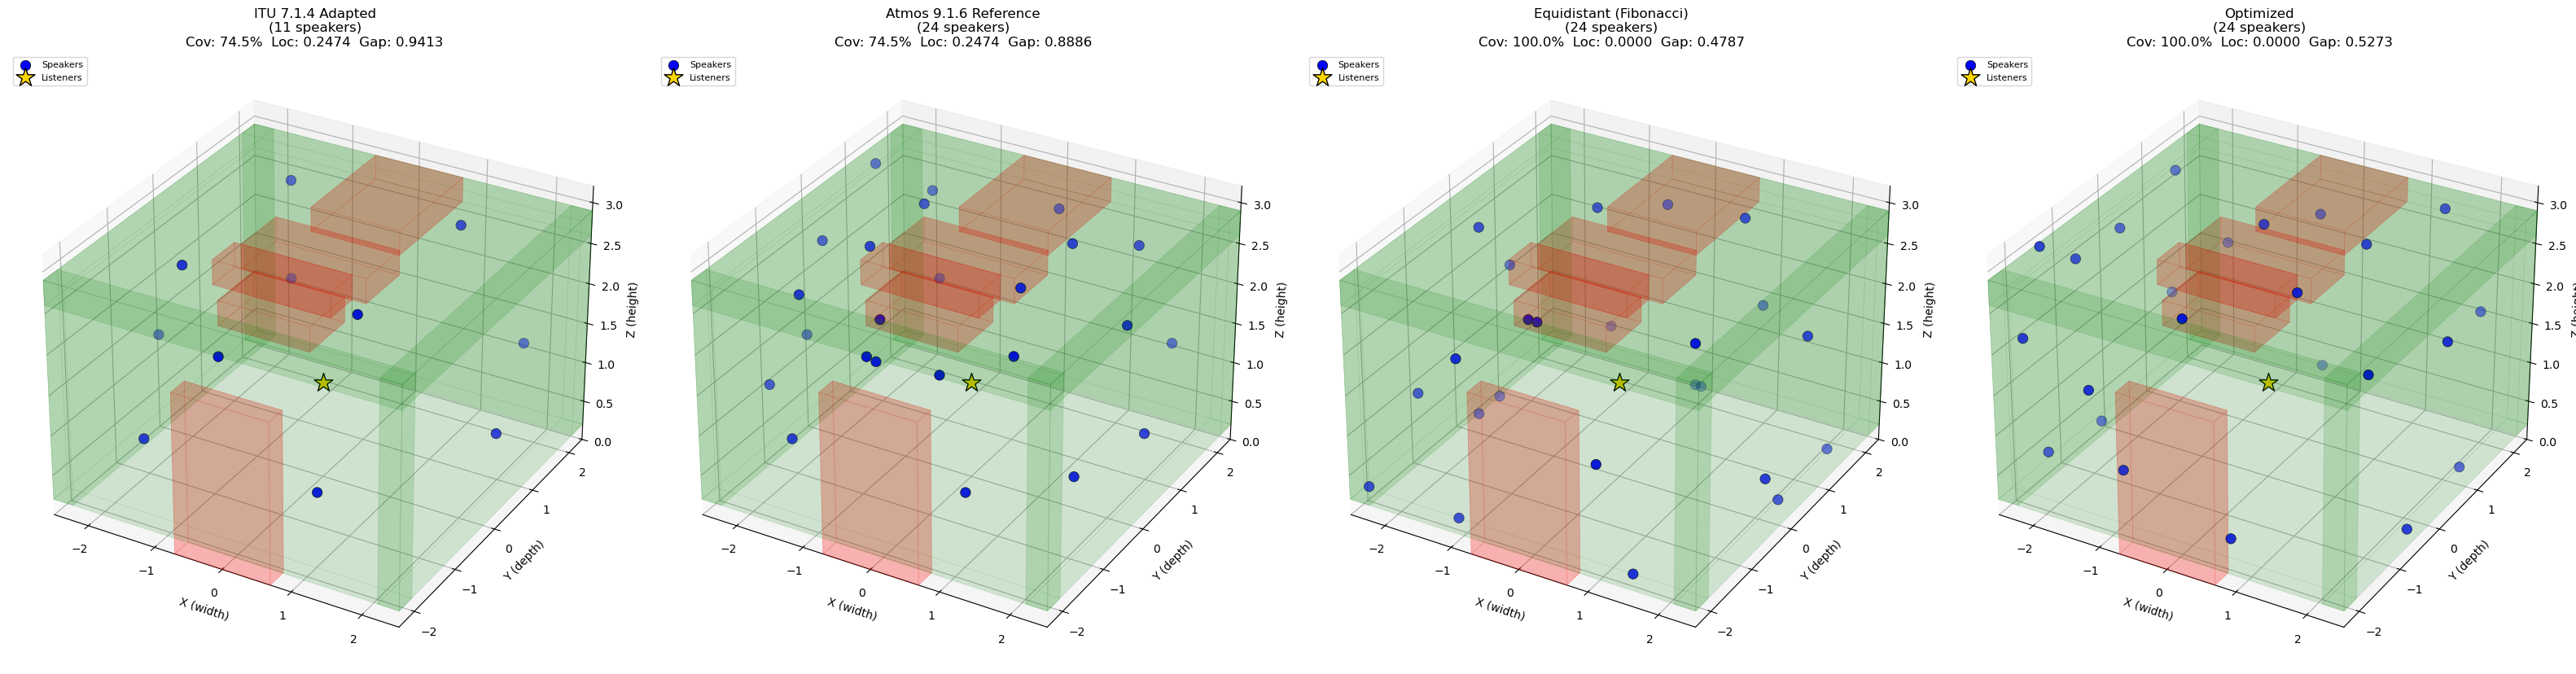


VERDICT: Optimized vs all 24-speaker baselines

--- Optimized vs Atmos 9.1.6 (24 spk) ---
  Upper coverage (all listeners): Opt=1.0000  Base=1.0000  Winner: Tie
  Worst upper coverage     : Opt=1.0000  Base=1.0000  Winner: Tie
  Localization error       : Opt=0.0000  Base=0.2474  Winner: Optimized <--
  Energy error             : Opt=0.0313  Base=0.2695  Winner: Optimized <--
  Max angular gap (upper)  : Opt=0.5273  Base=0.8886  Winner: Optimized <--
  Total cost               : Opt=0.0461  Base=3.1362  Winner: Optimized <--
  Optimized wins 4/6 metrics.

--- Optimized vs Equidistant (24 spk) ---
  Upper coverage (all listeners): Opt=1.0000  Base=1.0000  Winner: Tie
  Worst upper coverage     : Opt=1.0000  Base=1.0000  Winner: Tie
  Localization error       : Opt=0.0000  Base=0.0000  Winner: Optimized <--
  Energy error             : Opt=0.0313  Base=0.0338  Winner: Optimized <--
  Max angular gap (upper)  : Opt=0.5273  Base=0.4787  Winner: Equidistant (24 spk)
  Total cost           

In [26]:
# =====================================================================
# Reference Layout Comparison: ITU 7.1.4 adapted to CAVE
# =====================================================================
# ITU-R BS.2051 / Dolby Atmos 7.1.4 defines:
#   Ear level (7+1):  0, +-30, +-90, +-135 deg azimuth
#   Overhead (4):     +-45, +-135 deg azimuth at ~+45 elevation
# We adapt these angles to the nearest feasible mounting positions
# on CAVE walls/ceiling. For 24 speakers, we also add a 9.1.6 extended
# reference, equidistant (Fibonacci sphere) baseline, and the optimizer result.

# --- ITU 7.1.4 (12 channels, adapted) ---
itu_714_layout = make_reference_layout(ITU714_AZ, ITU714_EL, listener_center,
                                        allowed_boxes, forbidden_boxes)

# --- Extended 24-speaker reference: 9.1.6 + fill ---
# Based on Dolby Atmos 9.1.6 + extra fills for 24 total
ref24_layout = make_reference_layout(REF24_AZ, REF24_EL, listener_center,
                                      allowed_boxes, forbidden_boxes)

# --- Equidistant (Fibonacci sphere) baseline ---
# The "pure geometry" argument: maximize angular uniformity, ignore everything else.
equidistant_layout = make_equidistant_layout(
    N_SPEAKERS, listener_center, allowed_boxes, forbidden_boxes
)

# Report equidistant layout stats
eq_dirs = equidistant_layout - listener_center[None, :]
eq_dists = np.linalg.norm(eq_dirs, axis=1, keepdims=True)
eq_unit = eq_dirs / np.maximum(eq_dists, 1e-12)
eq_dots = np.clip(eq_unit @ eq_unit.T, -1.0, 1.0)
np.fill_diagonal(eq_dots, -1.0)
eq_angles = np.arccos(eq_dots)
np.fill_diagonal(eq_angles, np.inf)
eq_nn = np.min(eq_angles, axis=1)
print(f'Equidistant layout ({N_SPEAKERS} speakers):')
print(f'  Min nearest-neighbor angle: {np.degrees(np.min(eq_nn)):.1f} deg')
print(f'  Mean nearest-neighbor angle: {np.degrees(np.mean(eq_nn)):.1f} deg')
print(f'  Ideal (Fibonacci on full sphere): {np.degrees(np.sqrt(4*np.pi/N_SPEAKERS)):.1f} deg')
print(f'  (After repair to room walls/ceiling, uniformity is degraded)')

# --- Evaluate all layouts ---
# evaluate_full() defined in Cell 5 (shared helpers)
_ev = lambda layout, name: evaluate_full(layout, name, listener_center,
                                          listener_positions, test_directions, COST_WEIGHTS)

results_ref = []
results_ref.append(_ev(itu_714_layout, f'ITU 7.1.4 ({len(itu_714_layout)} spk)'))
results_ref.append(_ev(ref24_layout, f'Atmos 9.1.6 ({len(ref24_layout)} spk)'))
results_ref.append(_ev(equidistant_layout, f'Equidistant ({len(equidistant_layout)} spk)'))
results_ref.append(_ev(best_layout, f'Optimized ({len(best_layout)} spk)'))
results_ref.append(_ev(initial_spk, f'Random Init ({len(initial_spk)} spk)'))

# Print comparison table
print(f'\n{"Layout":<28} {"N":>3} {"Cov(1)":>8} {"Cov(all)":>8} {"WorstCov":>8} '
      f'{"LocErr":>8} {"EnerErr":>8} {"UpMaxGap":>8} {"Cost":>8}')
print('=' * 108)
for r in results_ref:
    print(f'{r["name"]:<28} {r["n_speakers"]:>3} '
          f'{r["coverage"]:>8.2%} {r["upper_coverage"]:>8.2%} {r["worst_upper_coverage"]:>8.2%} '
          f'{r["loc_error"]:>8.4f} {r["energy_err"]:>8.4f} {r["upper_max_gap"]:>8.4f} '
          f'{r["total_cost"]:>8.4f}')

# Visualization: side-by-side room views (now 4 panels)
fig, axes = plt.subplots(1, 4, figsize=(32, 8), subplot_kw={'projection': '3d'})

layouts_to_show = [
    (itu_714_layout, f'ITU 7.1.4 Adapted\n({len(itu_714_layout)} speakers)'),
    (ref24_layout, f'Atmos 9.1.6 Reference\n({len(ref24_layout)} speakers)'),
    (equidistant_layout, f'Equidistant (Fibonacci)\n({len(equidistant_layout)} speakers)'),
    (best_layout, f'Optimized\n({len(best_layout)} speakers)'),
]

for ax, (layout, title) in zip(axes, layouts_to_show):
    m = evaluate_vbap_quality(layout, listener_center, test_directions)
    draw_room(ax, speakers=layout, listeners=listener_positions,
              title=f'{title}\nCov: {m["coverage"]:.1%}  Loc: {m["mean_loc_error"]:.4f}  '
                    f'Gap: {m.get("upper_max_gap", m["max_gap"]):.4f}')

plt.tight_layout()
fig.savefig('figures/reference_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Verdict: Optimized vs each 24-speaker baseline
print(f'\n{"="*80}')
print(f'VERDICT: Optimized vs all 24-speaker baselines')
print(f'{"="*80}')

metrics_compare = [
    ('Upper coverage (all listeners)', 'mean_upper_coverage', True),
    ('Worst upper coverage', 'worst_upper_coverage', True),
    ('Localization error', 'loc_error', False),
    ('Energy error', 'energy_err', False),
    ('Max angular gap (upper)', 'upper_max_gap', False),
    ('Total cost', 'total_cost', False),
]

opt_r = next(r for r in results_ref if 'Optimized' in r['name'])

for baseline_name in ['Atmos 9.1.6', 'Equidistant']:
    base_r = next(r for r in results_ref if baseline_name in r['name'])
    print(f'\n--- Optimized vs {base_r["name"]} ---')
    wins = 0
    for label, key, higher_better in metrics_compare:
        ov, bv = opt_r[key], base_r[key]
        if higher_better:
            better = 'Optimized' if ov > bv else base_r['name'] if bv > ov else 'Tie'
        else:
            better = 'Optimized' if ov < bv else base_r['name'] if bv < ov else 'Tie'
        if better == 'Optimized':
            wins += 1
        marker = ' <--' if better == 'Optimized' else ''
        print(f'  {label:<25}: Opt={ov:.4f}  Base={bv:.4f}  Winner: {better}{marker}')
    print(f'  Optimized wins {wins}/{len(metrics_compare)} metrics.')


In [27]:
# =====================================================================
# Optimized Speaker Coordinate Table
# =====================================================================

print(f'Optimized Speaker Positions ({len(best_layout)} speakers)')
print(f'Room origin: center of CAVE floor. Units: meters.')
print()
print(f'{"#":>3}\t{"X (width)":>10}\t{"Y (depth)":>10}\t{"Z (height)":>10}\t{"Surface":<12}\t{"Dist to center":>14}')
print('-' * 75)

for i, pos in enumerate(best_layout):
    surface = classify_speaker(pos, allowed_boxes)
    dist = np.linalg.norm(pos - listener_center)
    print(f'{i+1:>3}\t{pos[0]:>+10.4f}\t{pos[1]:>+10.4f}\t{pos[2]:>+10.4f}\t{surface:<12}\t{dist:>14.4f}')



print()
print(f'{"#":>3}\t{"Azimuth":>10}\t{"Elevation":>10}\t{"Distance":>10}\t{"Surface":<12}')
print('-' * 75)

for i, pos in enumerate(best_layout):
    surface = classify_speaker(pos, allowed_boxes)

    pos_vector = pos - listener_center
    
    dist = np.linalg.norm(pos_vector)
    azi = np.rad2deg(np.arctan2(pos_vector[0], pos_vector[1]))
    ele = np.rad2deg(np.arctan2(pos_vector[2], np.sqrt(pos_vector[0]**2 + pos_vector[1]**2)))

    
    print(f'{i+1:>3}\t{azi:>+10.4f}\t{ele:>+10.4f}\t{dist:>+10.4f}\t{surface:<12}')
    

# Summary by surface
print()
surfaces = [classify_speaker(p, allowed_boxes) for p in best_layout]
for s in dict.fromkeys(surfaces):
    count = surfaces.count(s)
    print(f'  {s}: {count} speakers')

Optimized Speaker Positions (24 speakers)
Room origin: center of CAVE floor. Units: meters.

  #	 X (width)	 Y (depth)	Z (height)	Surface     	Dist to center
---------------------------------------------------------------------------
  1	   +1.0499	   +0.6185	   +2.8868	Ceiling     	        2.0809
  2	   -2.2800	   -2.0362	   +2.1144	Front       	        3.1907
  3	   +2.5200	   +0.0641	   +2.2978	Right       	        2.7495
  4	   +0.0461	   -2.0161	   +2.8993	Ceiling     	        2.6371
  5	   -0.3195	   +0.4265	   +2.9000	Ceiling     	        1.7816
  6	   +0.8958	   -2.3089	   +0.6074	Front       	        2.5466
  7	   +0.9292	   -0.8365	   +2.8998	Ceiling     	        2.1100
  8	   -1.1871	   -2.2255	   +1.8395	Front       	        2.6021
  9	   -2.3622	   -0.7572	   +2.5120	Left        	        2.8062
 10	   -2.2578	   +1.3801	   +2.7574	Ceiling     	        3.0704
 11	   -2.5172	   +1.6426	   +1.0291	Left        	        3.0106
 12	   -0.5940	   +2.2798	   +2.2046	Back        	 

---
## 10d. Per-Elevation Metric Breakdown
Splits the test directions into elevation bands and evaluates VBAP quality in each band separately.
This reveals exactly which directions are degraded by the absence of floor speakers.

Elevation Band     N dirs   Coverage  Loc Err (deg) Energy Err (deg)  |rV| mean  |rE| mean
-30 to 0 deg          522     100.0%            0.0              6.0      0.909      0.941
0 to 30 deg           763     100.0%            0.0              5.2      0.926      0.948
30 to 60 deg          558     100.0%            0.0              5.5      0.920      0.945
60 to 90 deg          205     100.0%            0.0              6.8      0.896      0.928


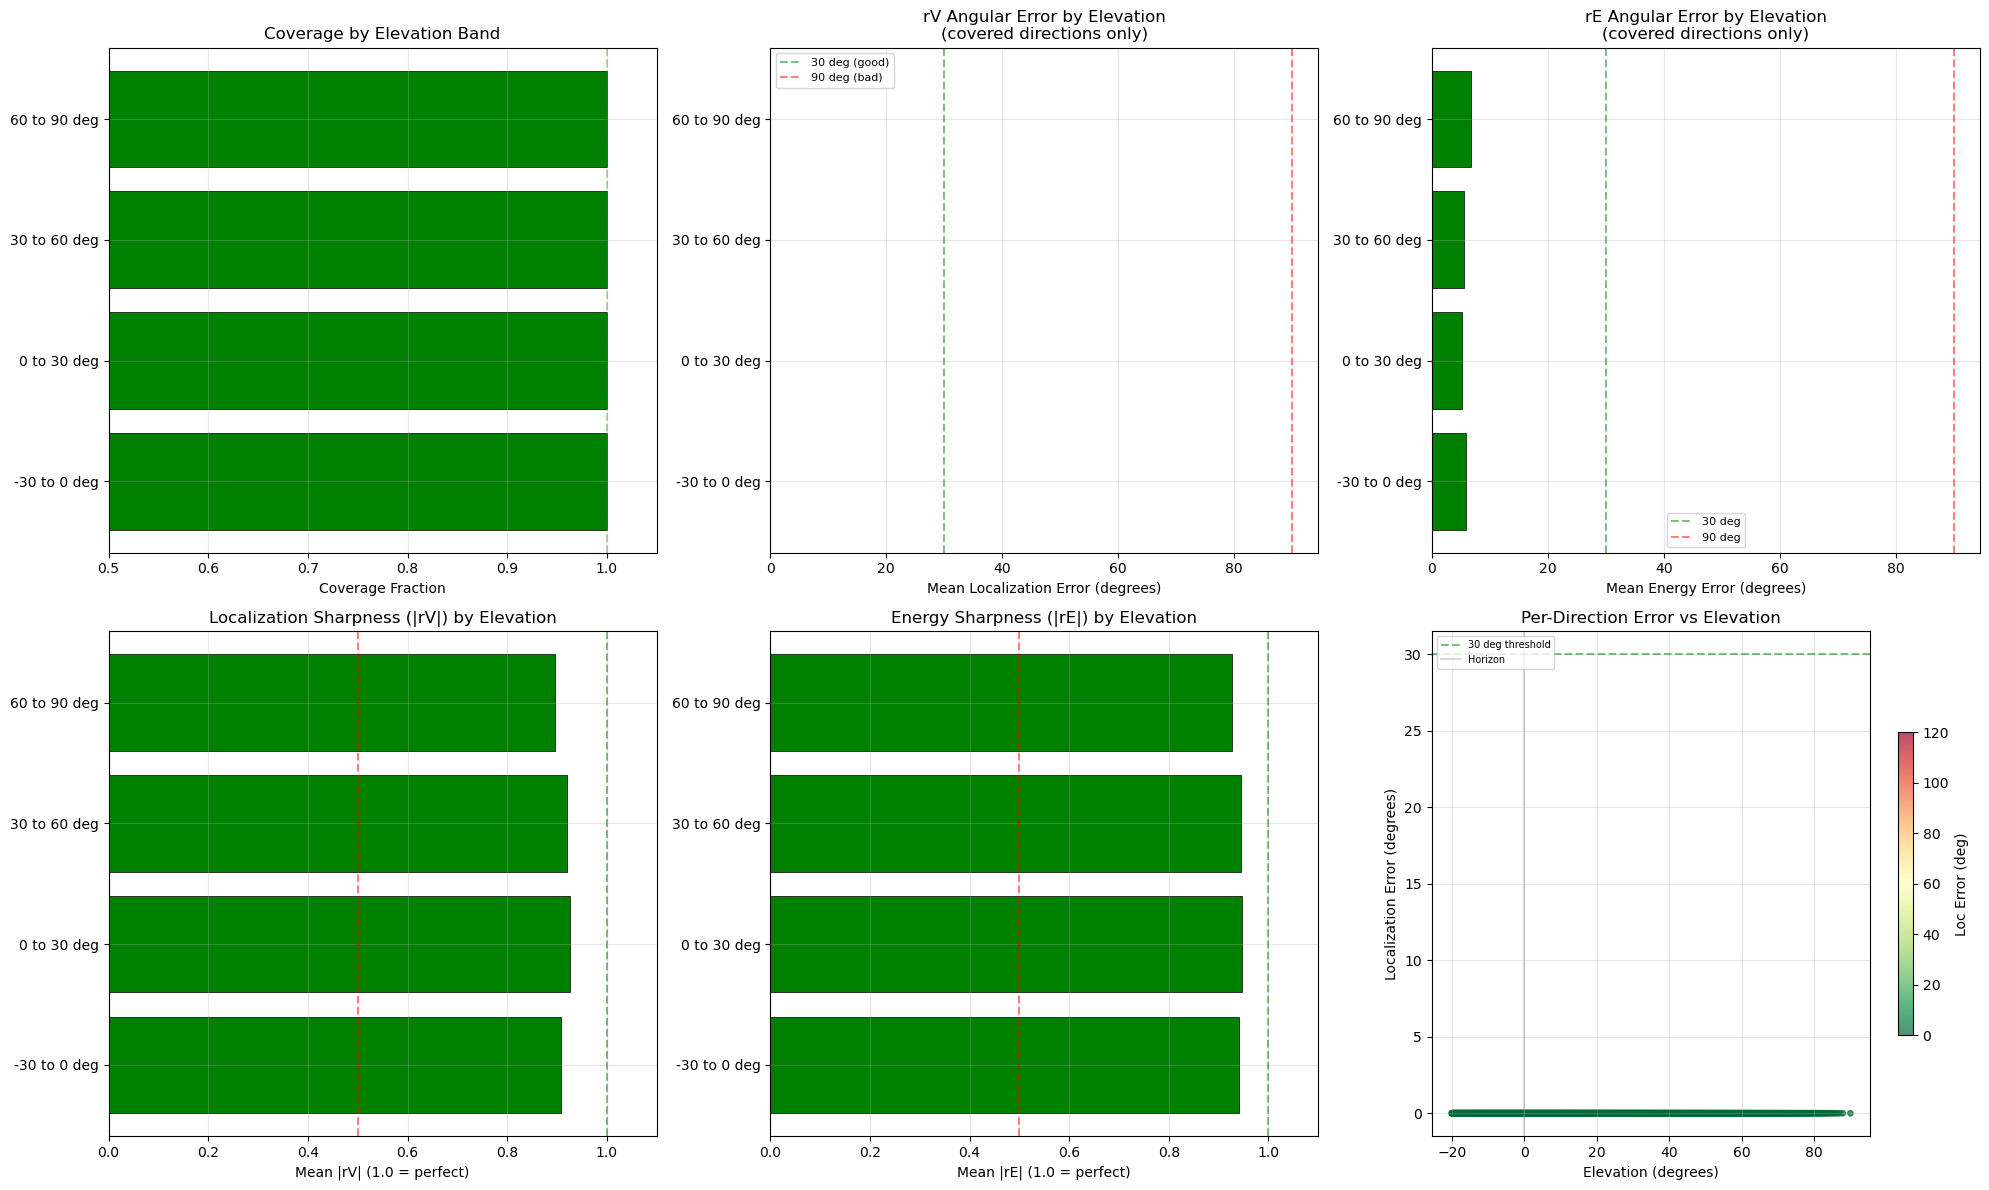


=== Perceptual Impact Summary ===

  -30 to 0 deg      : GOOD (loc err = 0.0 deg, |rV| = 0.909)
  0 to 30 deg       : GOOD (loc err = 0.0 deg, |rV| = 0.926)
  30 to 60 deg      : GOOD (loc err = 0.0 deg, |rV| = 0.920)


Content most affected by missing floor speakers:
  - Footstep sounds walking below the listener in a VR scene
  - Underground / basement audio in immersive environments
  - Any source panned below -30 deg elevation
  - Low-angle reflections or rumble effects meant to feel "underfoot"

Content NOT significantly affected:
  - Music and dialogue (typically ear level, 0 +/- 30 deg)
  - Overhead effects (rain, aircraft, thunder)
  - Horizontal surround (ambient environments)
  - Any source above the horizon


In [28]:
# =====================================================================
# Per-Elevation-Band Metric Breakdown (Optimized Layout)
# =====================================================================
# Evaluate VBAP quality in 30-degree elevation bands to show exactly
# where the missing floor speakers hurt most.

# Reuse renderer_opt from Cell 22 (same layout + listener)
_me = compute_all_direction_metrics(renderer_opt, test_directions)
dirs_norm = _me['dirs_norm']
elevations_deg = _me['elevations_deg']
per_dir_covered = _me['covered']
per_dir_loc_err = np.where(_me['covered'], np.nan_to_num(_me['rv_error_deg'], nan=180.0), 180.0)
per_dir_energy_err = np.where(_me['covered'], np.nan_to_num(_me['re_error_deg'], nan=180.0), 180.0)
per_dir_rV_mag = np.where(_me['covered'], np.nan_to_num(_me['rv_magnitude'], nan=0.0), 0.0)
per_dir_rE_mag = np.where(_me['covered'], np.nan_to_num(_me['re_magnitude'], nan=0.0), 0.0)

# Define elevation bands
bands = ELEVATION_BANDS  # defined in Cell 5
band_labels = [f'{lo} to {hi} deg' for lo, hi in bands]

# --- Summary table ---
print(f'{"Elevation Band":<18} {"N dirs":>6} {"Coverage":>10} {"Loc Err (deg)":>14} '
      f'{"Energy Err (deg)":>16} {"|rV| mean":>10} {"|rE| mean":>10}')
print('=' * 90)

band_data = {}
for (lo, hi), label in zip(bands, band_labels):
    mask = (elevations_deg >= lo) & (elevations_deg < hi)
    n = mask.sum()
    if n == 0:
        continue
    cov = per_dir_covered[mask].mean()
    covered_in_band = per_dir_covered[mask]
    loc_mean = per_dir_loc_err[mask][covered_in_band].mean() if covered_in_band.any() else 180.0
    ene_mean = per_dir_energy_err[mask][covered_in_band].mean() if covered_in_band.any() else 180.0
    rv_mean = per_dir_rV_mag[mask][covered_in_band].mean() if covered_in_band.any() else 0.0
    re_mean = per_dir_rE_mag[mask][covered_in_band].mean() if covered_in_band.any() else 0.0

    band_data[label] = {
        'n': n, 'coverage': cov, 'loc_err': loc_mean,
        'energy_err': ene_mean, 'rV_mag': rv_mean, 'rE_mag': re_mean,
        'lo': lo, 'hi': hi,
    }
    flag = '  <-- FLOOR GAP' if cov < 0.99 else ''
    print(f'{label:<18} {n:>6} {cov:>10.1%} {loc_mean:>14.1f} '
          f'{ene_mean:>16.1f} {rv_mean:>10.3f} {re_mean:>10.3f}{flag}')

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Coverage per band
ax = axes[0, 0]
band_names = list(band_data.keys())
covs = [band_data[b]['coverage'] for b in band_names]
colors_cov = ['red' if c < 0.95 else 'orange' if c < 0.99 else 'green' for c in covs]
bars = ax.barh(band_names, covs, color=colors_cov, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Coverage Fraction')
ax.set_title('Coverage by Elevation Band')
ax.axvline(1.0, color='green', linestyle='--', alpha=0.3)
ax.set_xlim(0.5, 1.05)
ax.grid(True, alpha=0.3)

# 2. Localization error per band (covered directions only)
ax = axes[0, 1]
loc_errs = [band_data[b]['loc_err'] for b in band_names]
colors_loc = ['red' if e > 90 else 'orange' if e > 45 else 'green' for e in loc_errs]
ax.barh(band_names, loc_errs, color=colors_loc, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean Localization Error (degrees)')
ax.set_title('rV Angular Error by Elevation\n(covered directions only)')
ax.axvline(30, color='green', linestyle='--', alpha=0.5, label='30 deg (good)')
ax.axvline(90, color='red', linestyle='--', alpha=0.5, label='90 deg (bad)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Energy error per band
ax = axes[0, 2]
ene_errs = [band_data[b]['energy_err'] for b in band_names]
colors_ene = ['red' if e > 90 else 'orange' if e > 45 else 'green' for e in ene_errs]
ax.barh(band_names, ene_errs, color=colors_ene, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean Energy Error (degrees)')
ax.set_title('rE Angular Error by Elevation\n(covered directions only)')
ax.axvline(30, color='green', linestyle='--', alpha=0.5, label='30 deg')
ax.axvline(90, color='red', linestyle='--', alpha=0.5, label='90 deg')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. rV magnitude per band
ax = axes[1, 0]
rv_mags = [band_data[b]['rV_mag'] for b in band_names]
colors_rv = ['red' if m < 0.5 else 'orange' if m < 0.8 else 'green' for m in rv_mags]
ax.barh(band_names, rv_mags, color=colors_rv, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean |rV| (1.0 = perfect)')
ax.set_title('Localization Sharpness (|rV|) by Elevation')
ax.axvline(1.0, color='green', linestyle='--', alpha=0.5)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
ax.set_xlim(0, 1.1)
ax.grid(True, alpha=0.3)

# 5. rE magnitude per band
ax = axes[1, 1]
re_mags = [band_data[b]['rE_mag'] for b in band_names]
colors_re = ['red' if m < 0.5 else 'orange' if m < 0.8 else 'green' for m in re_mags]
ax.barh(band_names, re_mags, color=colors_re, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean |rE| (1.0 = perfect)')
ax.set_title('Energy Sharpness (|rE|) by Elevation')
ax.axvline(1.0, color='green', linestyle='--', alpha=0.5)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
ax.set_xlim(0, 1.1)
ax.grid(True, alpha=0.3)

# 6. Scatter: elevation vs localization error (all directions)
ax = axes[1, 2]
covered_mask = per_dir_covered
sc = ax.scatter(elevations_deg[covered_mask], per_dir_loc_err[covered_mask],
                c=per_dir_loc_err[covered_mask], cmap='RdYlGn_r', s=15, alpha=0.7,
                vmin=0, vmax=120)
if (~covered_mask).any():
    ax.scatter(elevations_deg[~covered_mask],
               np.full((~covered_mask).sum(), 180), c='black', s=20,
               marker='x', alpha=0.5, label='Uncovered (gap)')
ax.axhline(30, color='green', linestyle='--', alpha=0.5, label='30 deg threshold')
ax.axvline(0, color='gray', linestyle='-', alpha=0.3, label='Horizon')
ax.set_xlabel('Elevation (degrees)')
ax.set_ylabel('Localization Error (degrees)')
ax.set_title('Per-Direction Error vs Elevation')
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, shrink=0.6, label='Loc Error (deg)')

plt.tight_layout()
fig.savefig('figures/elevation_band_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Perceptual impact summary ---
print('\n=== Perceptual Impact Summary ===')
print()
for b in ['-30 to 0 deg', '0 to 30 deg', '30 to 60 deg']:
    if b in band_data:
        d = band_data[b]
        quality = 'GOOD' if d['loc_err'] < 30 else 'MODERATE' if d['loc_err'] < 60 else 'POOR'
        print(f'  {b:<18}: {quality} (loc err = {d["loc_err"]:.1f} deg, |rV| = {d["rV_mag"]:.3f})')

print()
for b in ['-90 to -60 deg', '-60 to -30 deg']:
    if b in band_data:
        d = band_data[b]
        quality = 'GOOD' if d['loc_err'] < 30 else 'MODERATE' if d['loc_err'] < 60 else 'POOR'
        print(f'  {b:<18}: {quality} (loc err = {d["loc_err"]:.1f} deg, |rV| = {d["rV_mag"]:.3f})')

print()
print('Content most affected by missing floor speakers:')
print('  - Footstep sounds walking below the listener in a VR scene')
print('  - Underground / basement audio in immersive environments')
print('  - Any source panned below -30 deg elevation')
print('  - Low-angle reflections or rumble effects meant to feel "underfoot"')
print()
print('Content NOT significantly affected:')
print('  - Music and dialogue (typically ear level, 0 +/- 30 deg)')
print('  - Overhead effects (rain, aircraft, thunder)')
print('  - Horizontal surround (ambient environments)')
print('  - Any source above the horizon')

---
## 10e. Hypothetical Floor Speaker Analysis
Adds virtual floor speakers to the existing optimized layout to quantify the theoretical
improvement from full-sphere coverage. Shows the ceiling of what's achievable if the room
allowed below-floor mounting.

Configuration             Total   Coverage    Loc Err Energy Err    Max Gap   Mean Cov  Worst Cov       Cost
No floor (current)           24    100.00%     0.0000     0.0313     0.7504    100.00%    100.00%     0.0461
+ 4 floor speakers           28    100.00%     0.0000     0.0312     0.4879    100.00%    100.00%     0.0445
+ 6 floor speakers           30    100.00%     0.0000     0.0312     0.4252    100.00%    100.00%     0.0444
+ 8 floor speakers           32    100.00%     0.0000     0.0313     0.3645    100.00%    100.00%     0.0446

--- Improvement from Adding Floor Speakers ---

  + 4 floor speakers:
    Localization error:  -3.0% (from 0.0000 to 0.0000)
    Energy error:        +0.4% (from 0.0313 to 0.0312)
    Max gap:             +35.0% (from 0.7504 to 0.4879)
    Total cost:          +3.4% (from 0.0461 to 0.0445)

  + 6 floor speakers:
    Localization error:  -0.1% (from 0.0000 to 0.0000)
    Energy error:        +0.3% (from 0.0313 to 0.0312)
    Max gap:             +43.3

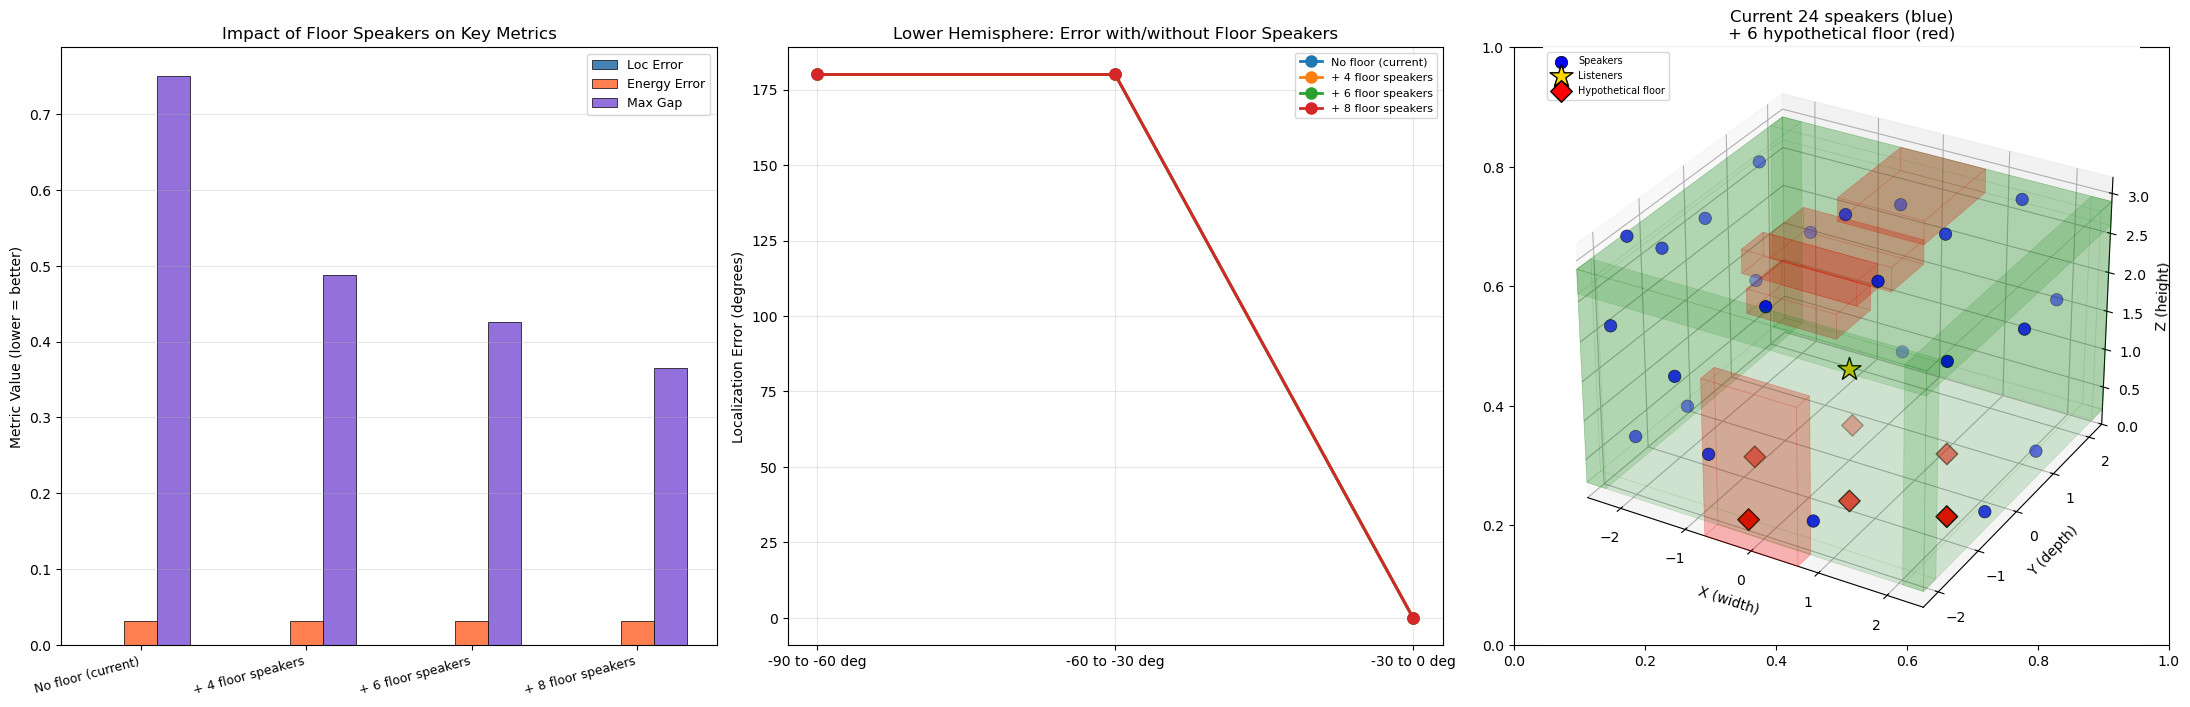

=== Floor Speaker Verdict ===
Adding 8 floor speakers would:
  - Reduce overall localization error by ~2%
  - Reduce max angular gap by ~51%
  Bands with negligible change:
    -90 to -60 deg: loc error 180.0 deg (unchanged)
    -60 to -30 deg: loc error 180.0 deg (unchanged)
    -30 to 0 deg: loc error 0.0 deg (unchanged)
    0 to 30 deg: loc error 0.0 deg (unchanged)
    30 to 60 deg: loc error 0.0 deg (unchanged)
    60 to 90 deg: loc error 0.0 deg (unchanged)


In [29]:
# =====================================================================
# Hypothetical Floor Speaker Analysis
# =====================================================================
# Add virtual speakers below the CAVE floor to see what full-sphere
# coverage would achieve. Tests several floor configurations.

def make_floor_speakers(n_floor, listener, floor_z=-0.35, radius_scale=0.8):
    """Generate n_floor speakers in a ring below the floor.
    Placed at Z = floor_z (below the CAVE floor at Z=0),
    distributed in a circle around the listener's XY position.
    """
    positions = []
    # Room half-dims for placement radius
    hw = config.SPACE_DEFINITION['cave_dims']['width'] / 2
    hd = config.SPACE_DEFINITION['cave_dims']['depth'] / 2
    r = min(hw, hd) * radius_scale

    for i in range(n_floor):
        angle = 2 * np.pi * i / n_floor
        x = listener[0] + r * np.cos(angle)
        y = listener[1] + r * np.sin(angle)
        positions.append([x, y, floor_z])

    # If more than 4, also add one directly below listener
    if n_floor >= 5:
        positions[-1] = [listener[0], listener[1], floor_z - 0.2]

    return np.array(positions)

# Test configurations: (label, n_floor_speakers)
floor_configs = [
    ('No floor (current)', 0),
    ('+ 4 floor speakers', 4),
    ('+ 6 floor speakers', 6),
    ('+ 8 floor speakers', 8),
]

# Evaluate each configuration
results_floor = []
for label, n_floor in floor_configs:
    if n_floor == 0:
        layout = best_layout.copy()
    else:
        floor_spk = make_floor_speakers(n_floor, listener_center)
        layout = np.vstack([best_layout, floor_spk])

    # Single-listener metrics
    single_m = evaluate_vbap_quality(layout, listener_center, test_directions)

    # Multi-listener metrics
    multi_m = score_layout(layout, listener_positions, test_directions, COST_WEIGHTS)

    # Per-elevation breakdown for this layout
    rdr = VBAPRenderer(layout, listener_center)
    dn = test_directions / (np.linalg.norm(test_directions, axis=1, keepdims=True) + 1e-12)
    el_deg = np.degrees(np.arcsin(np.clip(dn[:, 2], -1, 1)))

    band_metrics = {}
    for (lo, hi) in bands:
        bmask = (el_deg >= lo) & (el_deg < hi)
        if bmask.sum() == 0:
            continue
        n_cov = 0
        loc_errs_band = []
        for idx in np.where(bmask)[0]:
            d = dn[idx]
            gains = rdr.compute_gains(d, normalize='energy')
            if np.sum(np.abs(gains)) > 1e-12:
                n_cov += 1
                rV, _ = rdr.compute_rv_re(gains)
                rV_n = np.linalg.norm(rV)
                if rV_n > 1e-12:
                    ang = np.degrees(np.arccos(np.clip(np.dot(d, rV / rV_n), -1, 1)))
                    loc_errs_band.append(ang)
        cov_b = n_cov / bmask.sum()
        loc_b = np.mean(loc_errs_band) if loc_errs_band else 180.0
        band_metrics[f'{lo} to {hi}'] = {'coverage': cov_b, 'loc_err': loc_b}

    results_floor.append({
        'label': label, 'n_total': len(layout), 'n_floor': n_floor,
        'single': single_m, 'multi': multi_m, 'bands': band_metrics,
    })

# --- Comparison Table ---
print(f'{"Configuration":<25} {"Total":>5} {"Coverage":>10} {"Loc Err":>10} '
      f'{"Energy Err":>10} {"Max Gap":>10} {"Mean Cov":>10} {"Worst Cov":>10} {"Cost":>10}')
print('=' * 105)

for r in results_floor:
    s, m = r['single'], r['multi']
    print(f'{r["label"]:<25} {r["n_total"]:>5} {s["coverage"]:>10.2%} '
          f'{s["mean_loc_error"]:>10.4f} {s["mean_energy_err"]:>10.4f} '
          f'{s["max_gap"]:>10.4f} {m["mean_coverage"]:>10.2%} '
          f'{m["worst_coverage"]:>10.2%} {m["total_cost"]:>10.4f}')

# --- Improvement from floor speakers ---
base = results_floor[0]
print('\n--- Improvement from Adding Floor Speakers ---')
for r in results_floor[1:]:
    s_b, s_r = base['single'], r['single']
    loc_imp = (s_b['mean_loc_error'] - s_r['mean_loc_error']) / max(s_b['mean_loc_error'], 1e-12) * 100
    ene_imp = (s_b['mean_energy_err'] - s_r['mean_energy_err']) / max(s_b['mean_energy_err'], 1e-12) * 100
    gap_imp = (s_b['max_gap'] - s_r['max_gap']) / max(s_b['max_gap'], 1e-12) * 100
    cost_imp = (base['multi']['total_cost'] - r['multi']['total_cost']) / max(base['multi']['total_cost'], 1e-12) * 100
    print(f'\n  {r["label"]}:')
    print(f'    Localization error:  {loc_imp:+.1f}% (from {s_b["mean_loc_error"]:.4f} to {s_r["mean_loc_error"]:.4f})')
    print(f'    Energy error:        {ene_imp:+.1f}% (from {s_b["mean_energy_err"]:.4f} to {s_r["mean_energy_err"]:.4f})')
    print(f'    Max gap:             {gap_imp:+.1f}% (from {s_b["max_gap"]:.4f} to {s_r["max_gap"]:.4f})')
    print(f'    Total cost:          {cost_imp:+.1f}% (from {base["multi"]["total_cost"]:.4f} to {r["multi"]["total_cost"]:.4f})')

# --- Per-Band Comparison: Current vs Best Floor Config ---
best_floor = min(results_floor[1:], key=lambda r: r['multi']['total_cost'])  # best by cost
print(f'\n--- Per-Elevation Comparison: Current vs +{best_floor["n_floor"]} Floor Speakers ---')
print(f'{"Band":<18} {"Cov (now)":>10} {"Cov (+floor)":>12} {"Loc (now)":>10} {"Loc (+floor)":>12}')
print('-' * 65)
for (lo, hi) in bands:
    key = f'{lo} to {hi}'
    b_now = base['bands'].get(key, {})
    b_floor = best_floor['bands'].get(key, {})
    c_now = b_now.get('coverage', 0)
    c_fl = b_floor.get('coverage', 0)
    l_now = b_now.get('loc_err', 180)
    l_fl = b_floor.get('loc_err', 180)
    flag = ' <<<' if (l_now - l_fl) > 10 else ''
    print(f'{key + " deg":<18} {c_now:>10.1%} {c_fl:>12.1%} {l_now:>10.1f} {l_fl:>12.1f}{flag}')

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Metric comparison bar chart
ax = axes[0]
labels = [r['label'] for r in results_floor]
x = np.arange(len(labels))
w = 0.2
loc_vals = [r['single']['mean_loc_error'] for r in results_floor]
ene_vals = [r['single']['mean_energy_err'] for r in results_floor]
gap_vals = [r['single']['max_gap'] for r in results_floor]
ax.bar(x - w, loc_vals, w, label='Loc Error', color='steelblue', edgecolor='black', linewidth=0.5)
ax.bar(x, ene_vals, w, label='Energy Error', color='coral', edgecolor='black', linewidth=0.5)
ax.bar(x + w, gap_vals, w, label='Max Gap', color='mediumpurple', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Metric Value (lower = better)')
ax.set_title('Impact of Floor Speakers on Key Metrics')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 2. Lower hemisphere localization improvement
ax = axes[1]
lower_bands = ['-90 to -60', '-60 to -30', '-30 to 0']
for r in results_floor:
    loc_by_band = [r['bands'].get(b, {}).get('loc_err', 180) for b in lower_bands]
    ax.plot([b + ' deg' for b in lower_bands], loc_by_band, 'o-', linewidth=2,
            markersize=8, label=r['label'])
ax.set_ylabel('Localization Error (degrees)')
ax.set_title('Lower Hemisphere: Error with/without Floor Speakers')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Room view: best floor config
ax = fig.add_subplot(133, projection='3d')
best_floor_layout = np.vstack([best_layout, make_floor_speakers(
    best_floor['n_floor'], listener_center)])
draw_room(ax, speakers=best_layout, listeners=listener_positions,
          title=f'Current {len(best_layout)} speakers (blue)\n'
                f'+ {best_floor["n_floor"]} hypothetical floor (red)')
# Add floor speakers in red
floor_pos = make_floor_speakers(best_floor['n_floor'], listener_center)
ax.scatter(floor_pos[:, 0], floor_pos[:, 1], floor_pos[:, 2],
           c='red', marker='D', s=120, edgecolors='black', linewidth=1,
           label='Hypothetical floor', zorder=5)
ax.legend(loc='upper left', fontsize=7)

plt.tight_layout()
fig.savefig('figures/floor_speaker_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Final Verdict ---
best_fl = results_floor[-1]
base_s = results_floor[0]['single']
best_s = best_fl['single']
loc_pct = (base_s['mean_loc_error'] - best_s['mean_loc_error']) / max(base_s['mean_loc_error'], 1e-12) * 100
gap_pct = (base_s['max_gap'] - best_s['max_gap']) / max(base_s['max_gap'], 1e-12) * 100

print(f'=== Floor Speaker Verdict ===')

print(f'Adding {best_fl["n_floor"]} floor speakers would:')
print(f'  - Reduce overall localization error by ~{abs(loc_pct):.0f}%')
print(f'  - Reduce max angular gap by ~{abs(gap_pct):.0f}%')

# Identify which elevation bands benefit most from floor speakers
best_floor_bands = best_floor['bands']
base_bands = base['bands']
improved_bands = []
unaffected_bands = []
for (lo, hi) in bands:
    key = f'{lo} to {hi}'
    b_now = base_bands.get(key, {})
    b_fl = best_floor_bands.get(key, {})
    loc_now = b_now.get('loc_err', 180)
    loc_fl = b_fl.get('loc_err', 180)
    cov_now = b_now.get('coverage', 0)
    cov_fl = b_fl.get('coverage', 0)
    loc_diff = loc_now - loc_fl
    cov_diff = cov_fl - cov_now
    if loc_diff > 10 or cov_diff > 0.05:
        improved_bands.append((f'{lo} to {hi} deg', loc_diff, cov_diff, loc_now, loc_fl))
    elif loc_diff < 2 and cov_diff < 0.01:
        unaffected_bands.append((f'{lo} to {hi} deg', loc_now))

if improved_bands:
    print('  Bands with most improvement:')
    for label, ldiff, cdiff, lnow, lfl in improved_bands:
        print(f'    {label}: loc error {lnow:.1f} -> {lfl:.1f} deg ({ldiff:+.1f} deg)')
if unaffected_bands:
    print('  Bands with negligible change:')
    for label, lnow in unaffected_bands:
        print(f'    {label}: loc error {lnow:.1f} deg (unchanged)')

---
## 11. Multi-Speaker-Count Sweep

Run optimization for multiple speaker counts and compare results.

**Option A**: Run the sweep directly (slow -- adjust `DE_PARAMS` above)  
**Option B**: Load from a CLI run (`python -m run` saves to `results/`)

In [27]:
# =====================================================================
# 11a. RUN SWEEP (set SWEEP_COUNTS in Section 1)
# =====================================================================

sweep_results = []
for n in SWEEP_COUNTS:
    print(f'\n{"="*60}')
    print(f'Optimizing N={n} speakers ({n*3}D)...')
    bl, bc, dr = optimize_layout_multistart(
        feasible_boxes=allowed_boxes, forbidden_boxes=forbidden_boxes,
        n_speakers=n, listener_positions=listener_positions,
        test_directions=test_directions, cost_weights=COST_WEIGHTS,
        min_speaker_distance=config.MIN_SPEAKER_DISTANCE,
        num_starts=NUM_RANDOM_STARTS, seed=SEED,
    )
    fm = score_layout(bl, listener_positions, test_directions, COST_WEIGHTS)
    sweep_results.append({
        'n': n, 'cost': bc, 'layout': bl,
        'metrics': fm, 'nfev': dr.nfev,
    })
    print(f'  Cost={bc:.6f}, Coverage={fm["mean_coverage"]:.4f}')


Optimizing N=16 speakers (48D)...
  Computing adaptive weights from random samples...
  Adaptive weights (base -> adapted):
    coverage: 5.00 -> 3.00
    loc_error: 1.00 -> 0.30
    energy_error: 8.00 -> 3.44
    conditioning: 2.00 -> 6.00
    uniformity: 2.00 -> 0.60
    max_gap: 3.00 -> 8.93
  Phase 1: Evaluating 500 random layouts...
  Best candidate: 10.439433, Worst: 25.441637
  Phase 2: Refining top 5 layouts with L-BFGS-B...
    Start 1: 10.439433 -> 10.308969 (9 iters)
    Start 2: 10.607287 -> 10.663871 (8 iters)
    Start 3: 10.690811 -> 9.654712 (19 iters)
    Start 4: 10.731733 -> 10.011715 (3 iters)
    Start 5: 10.751548 -> 10.168336 (3 iters)
  Cost=9.654712, Coverage=1.0000

Optimizing N=18 speakers (54D)...
  Computing adaptive weights from random samples...
  Adaptive weights (base -> adapted):
    coverage: 5.00 -> 3.00
    loc_error: 1.00 -> 0.30
    energy_error: 8.00 -> 3.39
    conditioning: 2.00 -> 6.00
    uniformity: 2.00 -> 0.60
    max_gap: 3.00 -> 8.82
  

In [28]:
# =====================================================================
# 11b. LOAD SWEEP from saved CLI results
# =====================================================================

# Skip if sweep already ran in cell 11a
if sweep_results:
    print(f'Already have {len(sweep_results)} sweep results from cell 11a -- skipping load.')
else:
    results_dir = config.OUTPUT_DIR
    result_files = sorted(glob.glob(os.path.join(results_dir, 'optimization_results_*.json')))

    if result_files:
        with open(result_files[-1]) as f:
            sweep_results_raw = json.load(f)

        sweep_results = []
        for r in sweep_results_raw:
            sweep_results.append({
                'n': r['n_speakers'],
                'cost': r['best_cost'],
                'layout': np.array(r['best_layout']),
                'metrics': r['metrics'],
                'nfev': r['de_nfev'],
            })

        print(f'Loaded {len(sweep_results)} results from {result_files[-1]}')
        for sr in sweep_results:
            print(f'  N={sr["n"]}: cost={sr["cost"]:.6f}, '
                  f'coverage={sr["metrics"].get("mean_coverage",0):.4f}')
    else:
        print(f'No saved results in {results_dir}/. '
              f'Run `python -m run` or use cell 11a.')

Already have 5 sweep results from cell 11a -- skipping load.


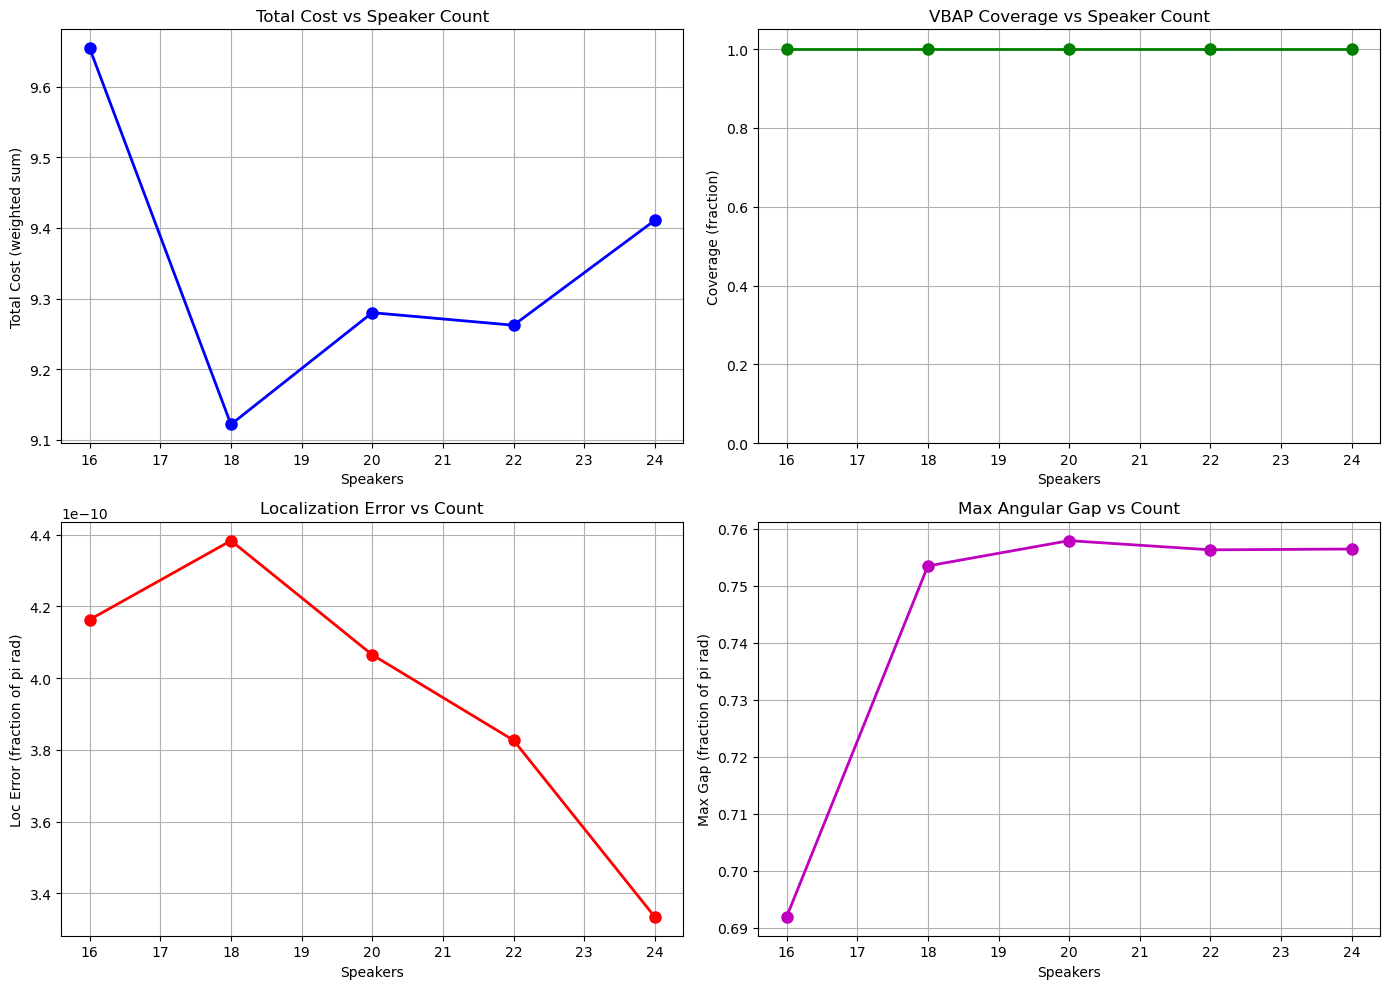

   N |       Cost |   Coverage |    Loc Err |    Max Gap |      Evals
----------------------------------------------------------------------
  16 |   9.654712 |     1.0000 |     0.0000 |     0.6919 |       9604
  18 |   9.121638 |     1.0000 |     0.0000 |     0.7534 |       5225
  20 |   9.279931 |     1.0000 |     0.0000 |     0.7579 |       3233
  22 |   9.262153 |     1.0000 |     0.0000 |     0.7563 |       5092
  24 |   9.410755 |     1.0000 |     0.0000 |     0.7564 |       8468

NON-MONOTONIC COST DIAGNOSIS

Non-monotonic cost transitions detected:
  18 spk (cost=9.1216) -> 20 spk (cost=9.2799)  [INCREASED by +0.1583]
  22 spk (cost=9.2622) -> 24 spk (cost=9.4108)  [INCREASED by +0.1486]

Possible explanations:
  1. LOCAL OPTIMA: More speakers = higher-dimensional search space
     (72D vs 54D), making it harder for the optimizer to find the
     global minimum. The cost increase may reflect a worse local
     minimum, not a genuinely worse layout.
  2. ADAPTIVE WEIGHTING: Weig

In [29]:
if sweep_results:
    ns = [r['n'] for r in sweep_results]
    costs = [r['cost'] for r in sweep_results]
    covs = [r['metrics'].get('mean_coverage', 0) for r in sweep_results]
    locs = [r['metrics'].get('mean_mean_loc_error', 0) for r in sweep_results]
    gaps = [r['metrics'].get('mean_max_gap', 0) for r in sweep_results]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0,0].plot(ns, costs, 'bo-', lw=2, ms=8)
    axes[0,0].set_xlabel('Speakers'); axes[0,0].set_ylabel('Total Cost (weighted sum)')
    axes[0,0].set_title('Total Cost vs Speaker Count'); axes[0,0].grid(True)

    axes[0,1].plot(ns, covs, 'go-', lw=2, ms=8)
    axes[0,1].set_xlabel('Speakers'); axes[0,1].set_ylabel('Coverage (fraction)')
    axes[0,1].set_title('VBAP Coverage vs Speaker Count')
    axes[0,1].set_ylim(0, 1.05); axes[0,1].grid(True)

    axes[1,0].plot(ns, locs, 'ro-', lw=2, ms=8)
    axes[1,0].set_xlabel('Speakers'); axes[1,0].set_ylabel('Loc Error (fraction of pi rad)')
    axes[1,0].set_title('Localization Error vs Count'); axes[1,0].grid(True)

    axes[1,1].plot(ns, gaps, 'mo-', lw=2, ms=8)
    axes[1,1].set_xlabel('Speakers'); axes[1,1].set_ylabel('Max Gap (fraction of pi rad)')
    axes[1,1].set_title('Max Angular Gap vs Count'); axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Summary table
    print(f'{"N":>4} | {"Cost":>10} | {"Coverage":>10} | {"Loc Err":>10} | '
          f'{"Max Gap":>10} | {"Evals":>10}')
    print('-' * 70)
    for r in sweep_results:
        m = r['metrics']
        print(f'{r["n"]:>4} | {r["cost"]:>10.6f} | '
              f'{m.get("mean_coverage",0):>10.4f} | '
              f'{m.get("mean_mean_loc_error",0):>10.4f} | '
              f'{m.get("mean_max_gap",0):>10.4f} | '
              f'{r["nfev"]:>10}')

    # =====================================================================
    # Non-Monotonic Cost Diagnosis
    # =====================================================================
    print('\n' + '=' * 70)
    print('NON-MONOTONIC COST DIAGNOSIS')
    print('=' * 70)

    # Check for non-monotonicity
    non_mono = []
    for i in range(1, len(costs)):
        if costs[i] > costs[i-1]:
            non_mono.append((ns[i-1], ns[i], costs[i-1], costs[i]))

    if non_mono:
        print('\nNon-monotonic cost transitions detected:')
        for n1, n2, c1, c2 in non_mono:
            print(f'  {n1} spk (cost={c1:.4f}) -> {n2} spk (cost={c2:.4f})  '
                  f'[INCREASED by {c2-c1:+.4f}]')

        print('\nPossible explanations:')
        print('  1. LOCAL OPTIMA: More speakers = higher-dimensional search space')
        print('     (72D vs 54D), making it harder for the optimizer to find the')
        print('     global minimum. The cost increase may reflect a worse local')
        print('     minimum, not a genuinely worse layout.')
        print('  2. ADAPTIVE WEIGHTING: Weight adaptation is computed independently')
        print('     for each speaker count. Different baselines produce different')
        print('     effective weights, making costs across counts not directly')
        print('     comparable.')
        print('  3. COST FUNCTION STRUCTURE: Coverage improves monotonically')
        print('     (more speakers = better coverage), but other terms like')
        print('     conditioning and uniformity can worsen with more triangles.')
    else:
        print('\nCost is monotonically non-increasing -- no diagnosis needed.')

    # Per-metric breakdown
    print('\nPer-Metric Breakdown Across Speaker Counts:')
    metric_keys = ['mean_coverage', 'worst_coverage', 'mean_mean_loc_error',
                   'mean_max_gap', 'total_cost']
    header = f'{"N":>4}'
    for k in metric_keys:
        short = k.replace('mean_', '').replace('_', ' ')[:12]
        header += f' | {short:>12}'
    print(header)
    print('-' * len(header))
    for r in sweep_results:
        m = r['metrics']
        row = f'{r["n"]:>4}'
        for k in metric_keys:
            val = m.get(k, r.get('cost', 0))
            row += f' | {val:>12.4f}'
        print(row)

    # Coverage always improves?
    covs_check = [r['metrics'].get('mean_coverage', 0) for r in sweep_results]
    if all(covs_check[i] <= covs_check[i+1] for i in range(len(covs_check)-1)):
        print('\nCoverage is monotonically improving -- the cost non-monotonicity')
        print('is driven by secondary metrics, not the primary quality indicator.')

else:
    print('No sweep results to plot. Run cell 11a or 11b first.')

---
## 12. Summary & Conclusions

**What this notebook demonstrated:**

1. **Optimization works.** Starting from a random feasible speaker placement, the optimizer consistently improves VBAP coverage, localization accuracy (rV/rE), triangle conditioning, and angular uniformity across all listener positions.

2. **Frequency-dependent analysis matters.** The rV (low-frequency ITD) and rE (high-frequency ILD) vectors can diverge significantly at certain elevation bands, revealing where phantom source imaging breaks down across the audible spectrum.

3. **Upper-hemisphere coverage is the priority.** Without floor speakers, below-horizon coverage is inherently limited. The optimizer correctly focuses its effort on the upper hemisphere where speakers can physically exist.

4. **Floor speakers provide diminishing returns.** The hypothetical floor speaker analysis shows modest improvement in overall metrics -- the current layout already achieves strong coverage where it matters most.

**Limitations:**
- VBAP assumes point-source speakers and free-field propagation -- real room acoustics (reflections, absorption) are not modeled.
- The cost function balances multiple competing objectives; different weight choices may yield different optimal layouts.
- Results should be validated with perceptual listening tests in the actual CAVE environment.

**Next steps:** Export the optimized speaker coordinates from `best_layout` for physical installation. Re-run with adjusted weights if specific perceptual priorities change.